# Robust Multi-Class Network Intrusion Detection

## Component 1: Multi-Class Baseline

This section builds the clean baseline pipeline on `NF-UNSW-NB15-v2`.

The baseline will be used as the starting point for later robustness tests:
- Stress Test A: Held-out attack classes
- Stress Test B: Cross-dataset distribution shift
- Stress Test C: Feature degradation


### C1-0 Initial Dataset Audit

This block loads `NF-UNSW-NB15-v2` and performs the initial checks before preprocessing:
- dataset shape and column structure
- label meaning
- binary and multi-class label distributions
- initial evidence of class imbalance


In [102]:
# Cell C1-0A: Project setup and load the UNSW dataset

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Keep notebook output cleaner
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset path
UNSW_PATH = Path(r"C:\Users\Administrator\Desktop\NF-UNSW-NB15-v2.csv")

# Load the original dataset
# raw_df will stay unchanged so later experiments can reuse the raw data safely
raw_df = pd.read_csv(UNSW_PATH)

print("UNSW dataset loaded.")
print("Dataset shape:", raw_df.shape)

display(raw_df.head())


UNSW dataset loaded.
Dataset shape: (2390275, 45)


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,59.166.0.5,1305,149.171.126.8,21,6,1.0,9,1,193,3,...,0,7240,0,0,0,0,0,331.0,0,Benign
1,59.166.0.5,1305,149.171.126.8,21,6,1.0,261,5,469,7,...,8688,8688,18944,74,0,0,0,230.0,0,Benign
2,59.166.0.5,1305,149.171.126.8,21,6,1.0,481,9,750,11,...,10136,10136,33792,132,0,0,0,229.0,0,Benign
3,59.166.0.5,1305,149.171.126.8,21,6,1.0,701,13,1054,15,...,11584,11584,48640,190,0,0,0,125.0,0,Benign
4,59.166.0.5,1305,149.171.126.8,21,6,1.0,1031,19,1474,21,...,14480,13032,64256,251,0,0,0,230.0,0,Benign


In [103]:
# Cell C1-0B: Check dataset structure and label meaning

print("Number of rows:", raw_df.shape[0])
print("Number of columns:", raw_df.shape[1])

# Show every column name and its data type
structure_df = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": raw_df.dtypes.astype(str).values
})

print("\nColumn structure:")
display(structure_df)

# Check the values in the two label columns
print("\nUnique values in Label:")
print(sorted(raw_df["Label"].dropna().unique()))

print("\nAttack classes:")
print(raw_df["Attack"].dropna().unique())

# Confirm how binary Label corresponds to multi-class Attack
label_attack_map = (
    raw_df
    .groupby(["Label", "Attack"])
    .size()
    .reset_index(name="samples")
    .sort_values(["Label", "samples"], ascending=[True, False])
)

print("\nMapping between Label and Attack:")
display(label_attack_map)


Number of rows: 2390275
Number of columns: 45

Column structure:


,column,dtype
0,IPV4_SRC_ADDR,object
1,L4_SRC_PORT,int64
2,IPV4_DST_ADDR,object
3,L4_DST_PORT,int64
4,PROTOCOL,int64
5,L7_PROTO,float64
6,IN_BYTES,int64
7,IN_PKTS,int64
8,OUT_BYTES,int64
9,OUT_PKTS,int64



Unique values in Label:
[np.int64(0), np.int64(1)]

Attack classes:
['Benign' 'Exploits' 'Generic' 'Fuzzers' 'Backdoor' 'DoS' 'Reconnaissance'
 'Shellcode' 'Worms' 'Analysis']

Mapping between Label and Attack:


,Label,Attack,samples
0,0,Benign,2295222
4,1,Exploits,31551
5,1,Fuzzers,22310
6,1,Generic,16560
7,1,Reconnaissance,12779
3,1,DoS,5794
1,1,Analysis,2299
2,1,Backdoor,2169
8,1,Shellcode,1427
9,1,Worms,164


Binary label distribution:


,binary_label,samples,percent
0,Benign,2295222,96.0233
1,Attack,95053,3.9767


Multi-class Attack distribution:


,attack_class,samples,percent
0,Benign,2295222,96.0233
1,Exploits,31551,1.3200
2,Fuzzers,22310,0.9334
3,Generic,16560,0.6928
4,Reconnaissance,12779,0.5346
5,DoS,5794,0.2424
6,Analysis,2299,0.0962
7,Backdoor,2169,0.0907
8,Shellcode,1427,0.0597
9,Worms,164,0.0069


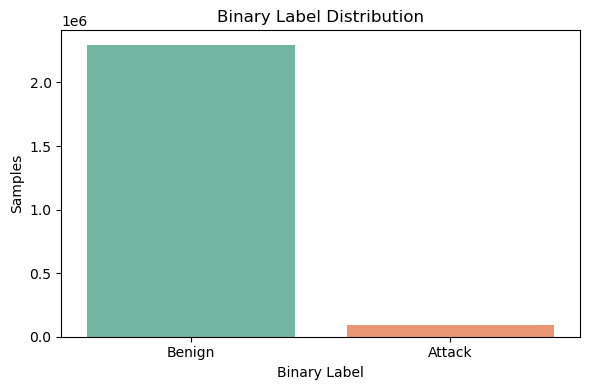

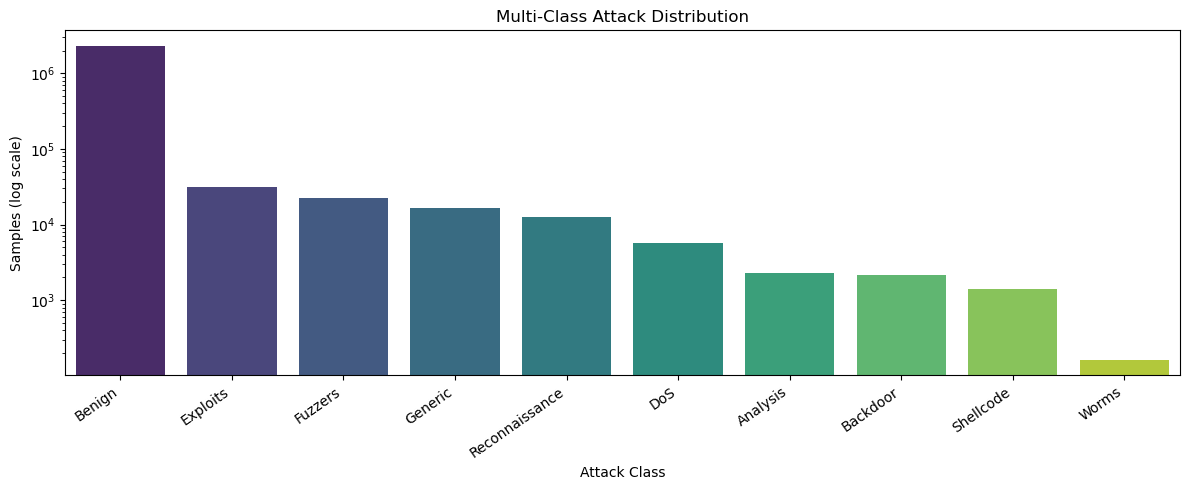

In [104]:
# Cell C1-0C: Check binary and multi-class label distributions
# 目的：报告类别分布，并观察 class imbalance

# Binary label distribution: 0 = Benign, 1 = Attack
binary_distribution = (
    raw_df["Label"]
    .map({0: "Benign", 1: "Attack"})
    .value_counts()
    .rename_axis("binary_label")
    .reset_index(name="samples")
)

binary_distribution["percent"] = (
    binary_distribution["samples"] / len(raw_df) * 100
).round(4)

print("Binary label distribution:")
display(binary_distribution)

# Multi-class attack distribution
attack_distribution = (
    raw_df["Attack"]
    .value_counts()
    .rename_axis("attack_class")
    .reset_index(name="samples")
)

attack_distribution["percent"] = (
    attack_distribution["samples"] / len(raw_df) * 100
).round(4)

print("Multi-class Attack distribution:")
display(attack_distribution)

# Plot binary distribution
plt.figure(figsize=(6, 4))
sns.barplot(
    data=binary_distribution,
    x="binary_label",
    y="samples",
    hue="binary_label",
    palette="Set2",
    legend=False
)
plt.title("Binary Label Distribution")
plt.xlabel("Binary Label")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

# Plot multi-class distribution
plt.figure(figsize=(12, 5))
sns.barplot(
    data=attack_distribution,
    x="attack_class",
    y="samples",
    hue="attack_class",
    palette="viridis",
    legend=False
)
plt.yscale("log")
plt.title("Multi-Class Attack Distribution")
plt.xlabel("Attack Class")
plt.ylabel("Samples (log scale)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


#### C1-0 Checkpoint: Initial Dataset Audit

**Mini report.** The initial audit confirmed that `NF-UNSW-NB15-v2` contains a binary label column (`Label`) and a multi-class attack label column (`Attack`). Component 1 will use `Attack` as the multi-class prediction target, while the binary `Label` column will be reserved for later experiments such as cross-dataset distribution shift testing. The class distribution also shows a strong class imbalance: benign traffic dominates the dataset, while several attack classes contain far fewer samples.

**Why it matters.** Later baseline evaluation should not rely on accuracy alone. Macro-F1 and per-class recall are needed to show whether minority attack classes are actually detected.


### C1-1 Data Quality Audit

This block checks data quality before building the baseline preprocessing pipeline:
- missing values
- infinite numeric values
- duplicate rows


In [105]:
# Cell C1-1A: Check missing values, infinite values, and duplicate rows

# 1. Missing-value audit
missing_count = raw_df.isna().sum()
missing_percent = (missing_count / len(raw_df) * 100).round(4)

missing_audit = pd.DataFrame({
    "column": raw_df.columns,
    "missing_count": missing_count.values,
    "missing_percent": missing_percent.values
})

missing_audit = missing_audit[missing_audit["missing_count"] > 0]

print("Missing-value audit:")
if missing_audit.empty:
    print("No missing values found.")
else:
    display(missing_audit.sort_values("missing_percent", ascending=False))


# 2. Infinite-value audit for numeric columns only
numeric_cols_raw = raw_df.select_dtypes(include=[np.number]).columns

inf_count = np.isinf(raw_df[numeric_cols_raw]).sum()

inf_audit = pd.DataFrame({
    "column": numeric_cols_raw,
    "infinite_count": inf_count.values
})

inf_audit = inf_audit[inf_audit["infinite_count"] > 0]

print("\nInfinite-value audit:")
if inf_audit.empty:
    print("No infinite values found in numeric columns.")
else:
    display(inf_audit.sort_values("infinite_count", ascending=False))


# 3. Duplicate-row audit
duplicate_rows = raw_df.duplicated().sum()

print("\nDuplicate-row audit:")
print("Duplicate rows:", duplicate_rows)
print("Duplicate row percent:", round(duplicate_rows / len(raw_df) * 100, 4), "%")


Missing-value audit:
No missing values found.

Infinite-value audit:
No infinite values found in numeric columns.

Duplicate-row audit:
Duplicate rows: 0
Duplicate row percent: 0.0 %


In [106]:
# Cell C1-1B: Check placeholder values in text columns

# Text columns in the raw dataset
text_cols_raw = raw_df.select_dtypes(include="object").columns.tolist()

# Common text placeholders that may represent hidden missing values
placeholder_tokens = {
    "", "?", "na", "n/a", "none", "null", "nan", "unknown", "-"
}

placeholder_rows = []

for col in text_cols_raw:
    cleaned_text = (
        raw_df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )
    
    placeholder_count = cleaned_text.isin(placeholder_tokens).sum()
    
    placeholder_rows.append({
        "column": col,
        "placeholder_count": int(placeholder_count)
    })

placeholder_audit = pd.DataFrame(placeholder_rows)

print("Text columns checked:")
print(text_cols_raw)

print("\nPlaceholder-value audit:")
if (placeholder_audit["placeholder_count"] == 0).all():
    print("No placeholder values found in text columns.")
else:
    display(
        placeholder_audit[placeholder_audit["placeholder_count"] > 0]
        .sort_values("placeholder_count", ascending=False)
    )


Text columns checked:
['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack']

Placeholder-value audit:
No placeholder values found in text columns.


#### C1-1 Checkpoint: Data Quality Audit

**Mini report.** The initial data-quality audit found no missing values, no infinite numeric values, no duplicated rows, and no common placeholder tokens in the text columns of `NF-UNSW-NB15-v2`.

**Why it matters.** The baseline preprocessing pipeline can focus on feature encoding, train-only scaling, and class-imbalance handling rather than correcting major data-quality defects.


### C1-2 Exploratory Feature Analysis

This block inspects representative NetFlow features before preprocessing:
- summary statistics for core traffic features
- distributions and outlier behavior
- selected feature relationships and attack-class differences


In [107]:
# Cell C1-2A: Summarize representative NetFlow features

# Core features selected for early inspection
core_feature_cols = [
    "L4_SRC_PORT",
    "L4_DST_PORT",
    "IN_BYTES",
    "IN_PKTS",
    "OUT_BYTES",
    "OUT_PKTS",
    "TCP_FLAGS",
    "FLOW_DURATION_MILLISECONDS",
    "MIN_TTL",
    "MAX_TTL",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

core_feature_cols = [
    col for col in core_feature_cols
    if col in raw_df.columns
]

core_feature_summary = (
    raw_df[core_feature_cols]
    .describe()
    .T
    .round(3)
)

print("Representative NetFlow feature summary:")
display(core_feature_summary)


Representative NetFlow feature summary:


,count,mean,std,min,25%,50%,75%,max
L4_SRC_PORT,2390275.0,32549.614,19162.123,0.0,15831.0,32650.0,49076.0,65535.0
L4_DST_PORT,2390275.0,11423.091,18539.146,0.0,25.0,80.0,15887.0,65535.0
IN_BYTES,2390275.0,4621.664,70214.094,1.0,481.0,1684.0,3286.0,30241410.0
IN_PKTS,2390275.0,36.037,79.957,1.0,4.0,18.0,44.0,22894.0
OUT_BYTES,2390275.0,35265.651,156515.488,0.0,312.0,2456.0,14968.0,14658518.0
OUT_PKTS,2390275.0,45.704,117.449,0.0,4.0,18.0,44.0,11078.0
TCP_FLAGS,2390275.0,19.900,11.134,0.0,19.0,27.0,27.0,31.0
FLOW_DURATION_MILLISECONDS,2390275.0,259111.719,1022610.467,0.0,0.0,0.0,0.0,4294965.0
MIN_TTL,2390275.0,38.989,41.028,0.0,31.0,31.0,31.0,255.0
MAX_TTL,2390275.0,39.822,40.980,0.0,32.0,32.0,32.0,255.0


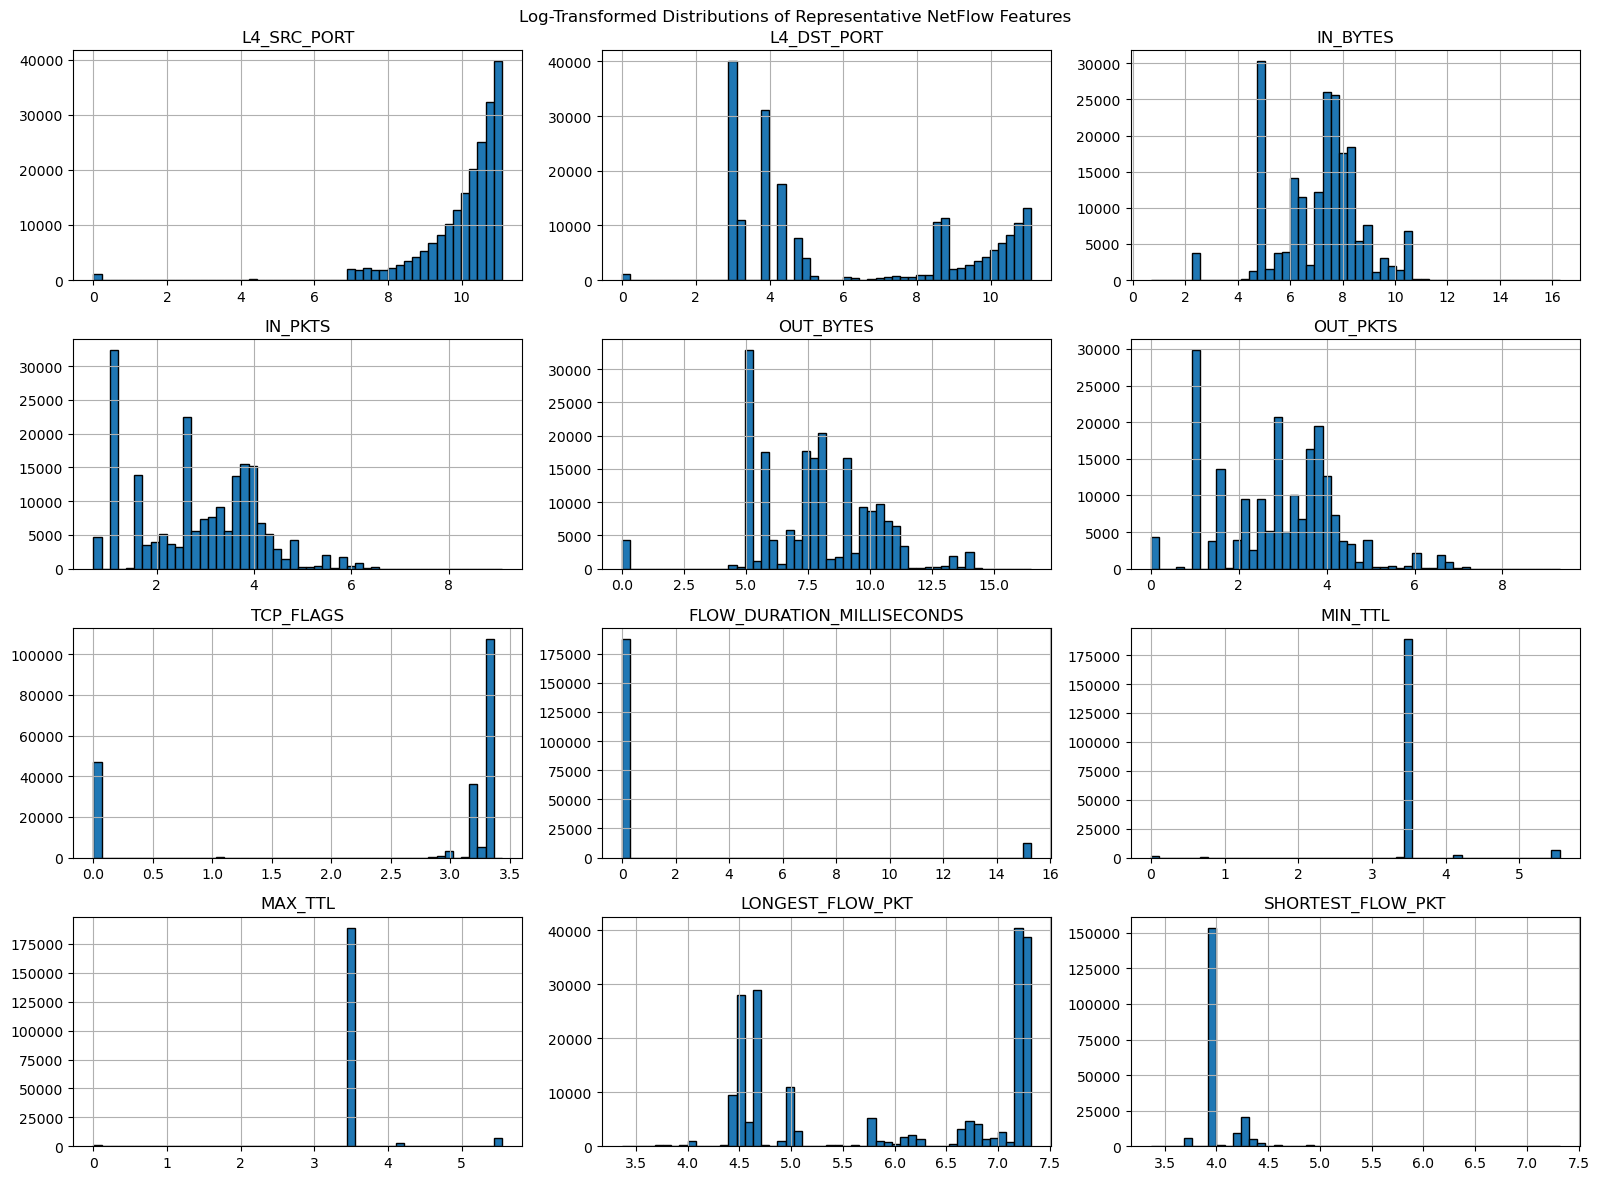

In [108]:
# Cell C1-2B: Visualize distributions of representative NetFlow features

# Use a sample for faster visualization only
plot_sample = raw_df.sample(
    n=min(200_000, len(raw_df)),
    random_state=RANDOM_STATE
)

# Log1p is used only for visualization here
# It makes highly skewed non-negative features easier to inspect
core_plot_df = np.log1p(plot_sample[core_feature_cols].clip(lower=0))

core_plot_df.hist(
    bins=50,
    figsize=(16, 12),
    edgecolor="black"
)

plt.suptitle("Log-Transformed Distributions of Representative NetFlow Features")
plt.tight_layout()
plt.show()


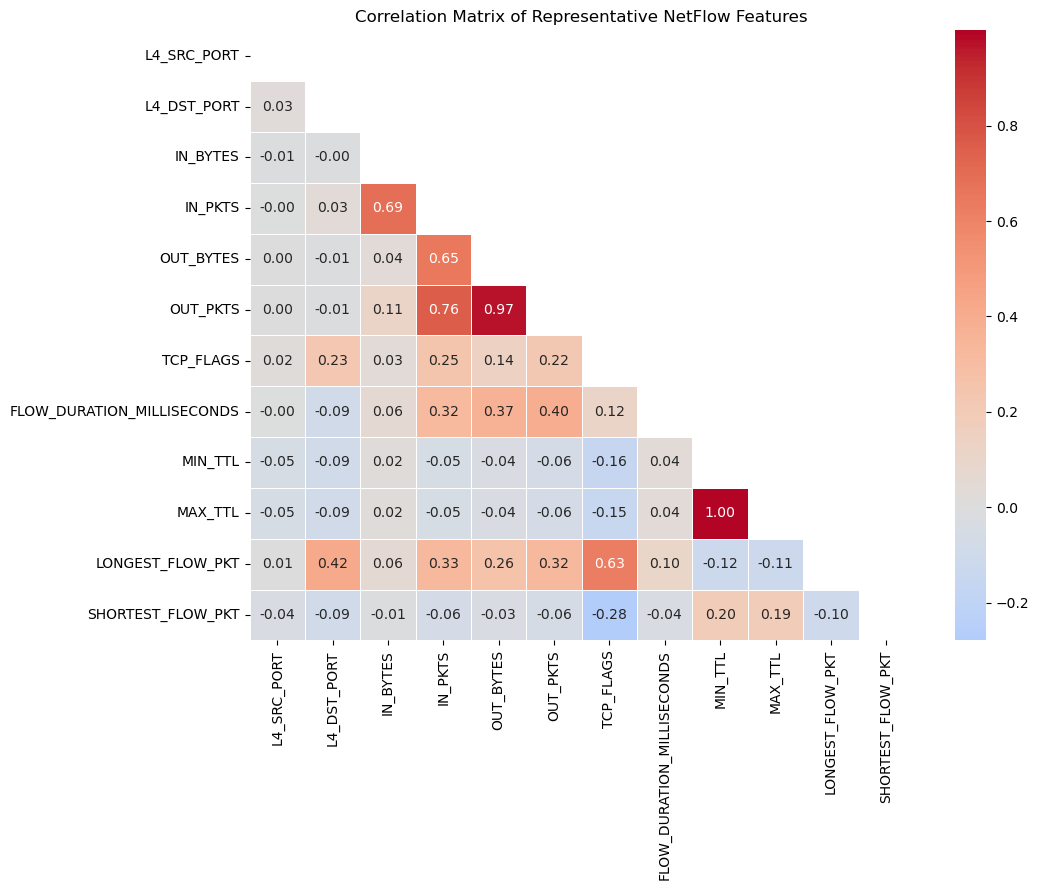

In [109]:
# Cell C1-2C: Inspect correlations among representative NetFlow features

core_corr = raw_df[core_feature_cols].corr()

plt.figure(figsize=(11, 9))

corr_mask = np.triu(
    np.ones_like(core_corr, dtype=bool)
)

sns.heatmap(
    core_corr,
    mask=corr_mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Representative NetFlow Features")
plt.tight_layout()
plt.show()


In [110]:
# Cell C1-2D: Compare representative feature medians by attack class

attack_compare_cols = [
    "IN_BYTES",
    "IN_PKTS",
    "OUT_BYTES",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS",
    "MIN_TTL",
    "MAX_TTL",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT"
]

attack_compare_cols = [
    col for col in attack_compare_cols
    if col in raw_df.columns
]

attack_feature_medians = (
    raw_df
    .groupby("Attack")[attack_compare_cols]
    .median()
    .round(2)
)

attack_support = (
    raw_df["Attack"]
    .value_counts()
    .rename("samples")
)

attack_feature_medians = (
    attack_feature_medians
    .join(attack_support)
    .sort_values("samples", ascending=False)
)

# Put sample count first
attack_feature_medians = attack_feature_medians[
    ["samples"] + attack_compare_cols
]

print("Median values of representative features by Attack class:")
display(attack_feature_medians)


Median values of representative features by Attack class:


,samples,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,FLOW_DURATION_MILLISECONDS,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT
Attack,,,,,,,,,,
Benign,2295222,1684.0,19.0,2512.0,18.0,0.0,31.0,32.0,732.0,52.0
Exploits,31551,889.0,10.0,893.0,9.0,0.0,62.0,63.0,545.0,40.0
Fuzzers,22310,744.0,10.0,256.0,6.0,0.0,254.0,255.0,196.0,40.0
Generic,16560,114.0,2.0,0.0,0.0,0.0,254.0,254.0,57.0,57.0
Reconnaissance,12779,552.0,10.0,256.0,6.0,0.0,254.0,255.0,100.0,40.0
DoS,5794,776.0,10.0,256.0,6.0,0.0,254.0,254.0,304.0,40.0
Analysis,2299,200.0,2.0,0.0,0.0,0.0,254.0,254.0,100.0,100.0
Backdoor,2169,200.0,2.0,0.0,0.0,0.0,254.0,254.0,100.0,100.0
Shellcode,1427,524.0,2.0,0.0,0.0,0.0,254.0,254.0,132.0,51.0


#### C1-2 Checkpoint: Exploratory Feature Analysis

**Mini report.** The exploratory feature analysis showed that representative NetFlow features have very different numeric ranges and several traffic-volume features are strongly right-skewed. Some features also show strong redundancy, such as `MIN_TTL` and `MAX_TTL`, and `OUT_BYTES` and `OUT_PKTS`. Median comparisons across attack classes reveal distinct traffic patterns for some categories, while several minority classes show highly similar feature profiles.

**Why it matters.** The baseline preprocessing pipeline should apply train-only feature scaling and should treat categorical protocol features separately from numeric traffic features. The observed skewness also motivates a selected `log1p` transform for non-negative traffic-volume features before standard scaling, while feature selection and robustness modifications are deferred to later experiments.


### C1-3 Baseline Preprocessing Preparation

This block defines the baseline modeling target and the feature-processing policy before the train/validation/test split:
- use `Attack` as the multi-class target for Component 1
- reserve `Label` for later binary experiments
- remove IP address columns and label columns from model features
- separate categorical protocol features from numeric NetFlow features


In [111]:
# Cell C1-3A: Define baseline targets and feature groups

# Component 1 target:
# Attack is the multi-class label for the baseline classifier
y_multiclass_raw = raw_df["Attack"].copy()

# Label is kept for later binary experiments such as Stress Test B
y_binary_raw = raw_df["Label"].astype(int).copy()

# Columns that must not enter the model feature matrix
drop_from_features = [
    "IPV4_SRC_ADDR",   # IP address: host identifier, not a robust traffic pattern
    "IPV4_DST_ADDR",   # IP address: host identifier, not a robust traffic pattern
    "Attack",          # multi-class target label
    "Label"            # binary target label; including it would cause label leakage
]

# Raw feature table for Component 1
X_raw = raw_df.drop(columns=drop_from_features).copy()

# Protocol columns are categorical even though they are stored as numbers
categorical_feature_cols = [
    "PROTOCOL",
    "L7_PROTO"
]

categorical_feature_cols = [
    col for col in categorical_feature_cols
    if col in X_raw.columns
]

numeric_feature_cols = [
    col for col in X_raw.columns
    if col not in categorical_feature_cols
]

print("Component 1 target:", "Attack multi-class label")
print("Raw feature shape:", X_raw.shape)
print("Number of categorical feature columns:", len(categorical_feature_cols))
print("Categorical feature columns:", categorical_feature_cols)
print("Number of numeric feature columns:", len(numeric_feature_cols))

print("\nColumns excluded from model features:")
print(drop_from_features)


Component 1 target: Attack multi-class label
Raw feature shape: (2390275, 41)
Number of categorical feature columns: 2
Categorical feature columns: ['PROTOCOL', 'L7_PROTO']
Number of numeric feature columns: 39

Columns excluded from model features:
['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack', 'Label']


In [112]:
# Cell C1-3B: Define numeric feature groups for baseline preprocessing

# Non-negative traffic-volume features selected for log1p transformation
log_numeric_feature_cols = [
    "IN_BYTES",
    "IN_PKTS",
    "OUT_BYTES",
    "OUT_PKTS",
    "FLOW_DURATION_MILLISECONDS",
    "DURATION_IN",
    "DURATION_OUT",
    "LONGEST_FLOW_PKT",
    "SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN",
    "MAX_IP_PKT_LEN",
    "SRC_TO_DST_SECOND_BYTES",
    "DST_TO_SRC_SECOND_BYTES",
    "RETRANSMITTED_IN_BYTES",
    "RETRANSMITTED_IN_PKTS",
    "RETRANSMITTED_OUT_BYTES",
    "RETRANSMITTED_OUT_PKTS",
    "SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT",
    "NUM_PKTS_UP_TO_128_BYTES",
    "NUM_PKTS_128_TO_256_BYTES",
    "NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES",
    "NUM_PKTS_1024_TO_1514_BYTES",
    "TCP_WIN_MAX_IN",
    "TCP_WIN_MAX_OUT",
    "DNS_TTL_ANSWER"
]

# Keep only columns present in the numeric feature set
log_numeric_feature_cols = [
    col for col in log_numeric_feature_cols
    if col in numeric_feature_cols
]

# Numeric columns not selected for log1p
regular_numeric_feature_cols = [
    col for col in numeric_feature_cols
    if col not in log_numeric_feature_cols
]

print("Log1p numeric feature count:", len(log_numeric_feature_cols))
print("Log1p numeric features:")
print(log_numeric_feature_cols)

print("\nRegular numeric feature count:", len(regular_numeric_feature_cols))
print("Regular numeric features:")
print(regular_numeric_feature_cols)

# Sanity checks: no overlap and no missing numeric features
numeric_overlap = set(log_numeric_feature_cols) & set(regular_numeric_feature_cols)
numeric_covered = set(log_numeric_feature_cols) | set(regular_numeric_feature_cols)

print("\nNumeric feature overlap:", numeric_overlap)
print("All numeric features covered:", numeric_covered == set(numeric_feature_cols))


Log1p numeric feature count: 27
Log1p numeric features:
['IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'DNS_TTL_ANSWER']

Regular numeric feature count: 12
Regular numeric features:
['L4_SRC_PORT', 'L4_DST_PORT', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'MIN_TTL', 'MAX_TTL', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'FTP_COMMAND_RET_CODE']

Numeric feature overlap: set()
All numeric features covered: True


### C1-4 Train, Validation, and Test Split

This block creates stratified data splits for the Component 1 multi-class baseline:
- training set for fitting preprocessing and models
- validation set for model comparison and tuning decisions
- test set reserved for final clean baseline evaluation


In [113]:
# Cell C1-4A: Create stratified train, validation, and test splits

from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary holdout
X_train_raw, X_temp_raw, y_train_text, y_temp_text = train_test_split(
    X_raw,
    y_multiclass_raw,
    test_size=0.30,
    stratify=y_multiclass_raw,
    random_state=RANDOM_STATE
)

# Second split: 10% validation, 20% test from the full dataset
X_val_raw, X_test_raw, y_val_text, y_test_text = train_test_split(
    X_temp_raw,
    y_temp_text,
    test_size=2/3,
    stratify=y_temp_text,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train_raw.shape, y_train_text.shape)
print("Validation shape:", X_val_raw.shape, y_val_text.shape)
print("Test shape:", X_test_raw.shape, y_test_text.shape)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "samples": [len(X_train_raw), len(X_val_raw), len(X_test_raw)],
    "percent_of_full_dataset": [
        len(X_train_raw) / len(X_raw) * 100,
        len(X_val_raw) / len(X_raw) * 100,
        len(X_test_raw) / len(X_raw) * 100
    ]
})

display(split_summary.round(2))


Train shape: (1673192, 41) (1673192,)
Validation shape: (239027, 41) (239027,)
Test shape: (478056, 41) (478056,)


,split,samples,percent_of_full_dataset
0,Train,1673192,70.0
1,Validation,239027,10.0
2,Test,478056,20.0


In [114]:
# Cell C1-4B: Verify class balance across data splits

attack_class_order = attack_distribution["attack_class"].tolist()

split_class_counts = pd.DataFrame({
    "Train": y_train_text.value_counts(),
    "Validation": y_val_text.value_counts(),
    "Test": y_test_text.value_counts()
}).reindex(attack_class_order)

split_class_percent = (
    split_class_counts
    .div(split_class_counts.sum(axis=0), axis=1)
    .mul(100)
)

print("Class counts in each split:")
display(split_class_counts.astype(int))

print("Class percentages in each split:")
display(split_class_percent.round(4))


Class counts in each split:


,Train,Validation,Test
Attack,,,
Benign,1606655,229522,459045
Exploits,22086,3155,6310
Fuzzers,15617,2231,4462
Generic,11592,1656,3312
Reconnaissance,8945,1278,2556
DoS,4056,579,1159
Analysis,1609,230,460
Backdoor,1518,217,434
Shellcode,999,143,285


Class percentages in each split:


,Train,Validation,Test
Attack,,,
Benign,96.0233,96.0235,96.0233
Exploits,1.3200,1.3199,1.3199
Fuzzers,0.9334,0.9334,0.9334
Generic,0.6928,0.6928,0.6928
Reconnaissance,0.5346,0.5347,0.5347
DoS,0.2424,0.2422,0.2424
Analysis,0.0962,0.0962,0.0962
Backdoor,0.0907,0.0908,0.0908
Shellcode,0.0597,0.0598,0.0596


#### C1-4 Checkpoint: Train, Validation, and Test Split

**Mini report.** The UNSW dataset was divided into a stratified 70% training set, 10% validation set, and 20% test set using the multi-class `Attack` label. The split preserved the original class proportions across all three subsets, including very small classes such as `Worms`.

**Why it matters.** The training set can be used to fit preprocessing and models, the validation set can support baseline comparison and tuning decisions, and the test set remains reserved for final clean-distribution evaluation. Stratification reduces the risk that minority attack classes are accidentally underrepresented in a split.


In [115]:
# Cell C1-4C: Encode multi-class Attack labels after splitting

from sklearn.preprocessing import LabelEncoder

attack_label_encoder = LabelEncoder()

# Fit only on the training labels
y_train = attack_label_encoder.fit_transform(y_train_text)

# Apply the learned mapping to validation and test labels
y_val = attack_label_encoder.transform(y_val_text)
y_test = attack_label_encoder.transform(y_test_text)

attack_class_names = attack_label_encoder.classes_.tolist()

attack_label_mapping = pd.DataFrame({
    "encoded_label": range(len(attack_class_names)),
    "attack_class": attack_class_names
})

print("Encoded Attack classes:")
display(attack_label_mapping)

print("Encoded label shapes:")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Encoded Attack classes:


,encoded_label,attack_class
0,0,Analysis
1,1,Backdoor
2,2,Benign
3,3,DoS
4,4,Exploits
5,5,Fuzzers
6,6,Generic
7,7,Reconnaissance
8,8,Shellcode
9,9,Worms


Encoded label shapes:
y_train: (1673192,)
y_val: (239027,)
y_test: (478056,)


### C1-5 Baseline Feature Preprocessing

This block builds the train-fitted preprocessing pipeline for Component 1:
- inspect categorical protocol features before encoding
- apply selected `log1p` transforms to skewed non-negative numeric features
- standardize numeric features using training statistics only
- one-hot encode protocol features using training categories only

In [116]:
# Cell C1-5A: Inspect categorical protocol features before encoding

categorical_audit_rows = []

for col in categorical_feature_cols:
    train_values = X_train_raw[col]
    
    categorical_audit_rows.append({
        "feature": col,
        "dtype": str(train_values.dtype),
        "train_unique_values": train_values.nunique(),
        "missing_values": train_values.isna().sum()
    })

categorical_audit = pd.DataFrame(categorical_audit_rows)

print("Categorical feature audit on the training split:")
display(categorical_audit)

print("PROTOCOL values in training data:")
print(sorted(X_train_raw["PROTOCOL"].dropna().unique()))

l7_train_values = X_train_raw["L7_PROTO"].dropna()

non_integer_l7_count = (
    (l7_train_values % 1 != 0)
    .sum()
)

print("\nL7_PROTO unique values in training data:", l7_train_values.nunique())
print("L7_PROTO values with a fractional part:", int(non_integer_l7_count))

print("\nFirst 30 L7_PROTO values by frequency:")
display(
    X_train_raw["L7_PROTO"]
    .value_counts()
    .head(30)
    .to_frame("samples")
)

Categorical feature audit on the training split:


,feature,dtype,train_unique_values,missing_values
0,PROTOCOL,int64,255,0
1,L7_PROTO,float64,81,0


PROTOCOL values in training data:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(

,samples
L7_PROTO,
0.000,1063780
1.000,333882
7.000,146773
3.000,55038
92.000,33908
4.000,33881
17.000,1469
13.000,1049
41.000,920


In [117]:
# Cell C1-5B: Verify selected log1p features are non-negative

log_feature_minimums = (
    X_train_raw[log_numeric_feature_cols]
    .min()
    .rename("train_min")
    .reset_index()
    .rename(columns={"index": "feature"})
)

negative_log_features = log_feature_minimums[
    log_feature_minimums["train_min"] < 0
]

print("Minimum values of selected log1p features on the training split:")
display(log_feature_minimums)

print("\nSelected log1p features with negative training values:")
if negative_log_features.empty:
    print("None. All selected log1p features are non-negative in the training split.")
else:
    display(negative_log_features)

Minimum values of selected log1p features on the training split:


,feature,train_min
0,IN_BYTES,1.0
1,IN_PKTS,1.0
2,OUT_BYTES,0.0
3,OUT_PKTS,0.0
4,FLOW_DURATION_MILLISECONDS,0.0
5,DURATION_IN,0.0
6,DURATION_OUT,0.0
7,LONGEST_FLOW_PKT,28.0
8,SHORTEST_FLOW_PKT,28.0
9,MIN_IP_PKT_LEN,0.0



Selected log1p features with negative training values:
None. All selected log1p features are non-negative in the training split.


In [118]:
# Cell C1-5C: Build the baseline preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
import numpy as np

# 1. Numeric features that need log1p first
log_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# 2. Numeric features that do not need log1p
regular_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 3. Categorical features: PROTOCOL and L7_PROTO
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32
    ))
])

# 4. Combine all preprocessing rules
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("log_numeric", log_numeric_pipeline, log_numeric_feature_cols),
        ("regular_numeric", regular_numeric_pipeline, regular_numeric_feature_cols),
        ("categorical", categorical_pipeline, categorical_feature_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

print("Baseline preprocessor is ready.")
print("Log1p numeric features:", len(log_numeric_feature_cols))
print("Regular numeric features:", len(regular_numeric_feature_cols))
print("Categorical features:", categorical_feature_cols)

Baseline preprocessor is ready.
Log1p numeric features: 27
Regular numeric features: 12
Categorical features: ['PROTOCOL', 'L7_PROTO']


In [119]:
# Cell C1-5D: Fit preprocessing on training data and transform all splits

from scipy import sparse

# Learn preprocessing rules from the training split only
X_train_processed = baseline_preprocessor.fit_transform(X_train_raw)

# Apply the same learned rules to validation and test splits
X_val_processed = baseline_preprocessor.transform(X_val_raw)
X_test_processed = baseline_preprocessor.transform(X_test_raw)

# Save processed feature names for later interpretation
baseline_feature_names = baseline_preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

print("\nSparse matrix output:")
print("Train:", sparse.issparse(X_train_processed))
print("Validation:", sparse.issparse(X_val_processed))
print("Test:", sparse.issparse(X_test_processed))

print("\nNumber of processed features:", len(baseline_feature_names))
print("First 20 processed feature names:")
print(baseline_feature_names[:20])

Processed train shape: (1673192, 375)
Processed validation shape: (239027, 375)
Processed test shape: (478056, 375)

Sparse matrix output:
Train: True
Validation: True
Test: True

Number of processed features: 375
First 20 processed feature names:
['log_numeric__IN_BYTES' 'log_numeric__IN_PKTS' 'log_numeric__OUT_BYTES'
 'log_numeric__OUT_PKTS' 'log_numeric__FLOW_DURATION_MILLISECONDS'
 'log_numeric__DURATION_IN' 'log_numeric__DURATION_OUT'
 'log_numeric__LONGEST_FLOW_PKT' 'log_numeric__SHORTEST_FLOW_PKT'
 'log_numeric__MIN_IP_PKT_LEN' 'log_numeric__MAX_IP_PKT_LEN'
 'log_numeric__SRC_TO_DST_SECOND_BYTES'
 'log_numeric__DST_TO_SRC_SECOND_BYTES'
 'log_numeric__RETRANSMITTED_IN_BYTES'
 'log_numeric__RETRANSMITTED_IN_PKTS'
 'log_numeric__RETRANSMITTED_OUT_BYTES'
 'log_numeric__RETRANSMITTED_OUT_PKTS'
 'log_numeric__SRC_TO_DST_AVG_THROUGHPUT'
 'log_numeric__DST_TO_SRC_AVG_THROUGHPUT'
 'log_numeric__NUM_PKTS_UP_TO_128_BYTES']


#### C1-5 Checkpoint: Baseline Feature Preprocessing

**Mini report.**  
The baseline preprocessing pipeline was fitted on the training split only and then applied unchanged to the validation and test splits. Numeric NetFlow features were separated into log-transformed and regular numeric groups before scaling. `PROTOCOL` and `L7_PROTO` were treated as categorical features and encoded with one-hot encoding. After preprocessing, all three splits shared the same 375-feature model input space.

**Why it matters.**  
This train-fitted preprocessing design reduces leakage risk and keeps the feature representation consistent across training, validation, and testing. The sparse output also makes the expanded categorical representation more memory efficient.

### C1-6 Baseline Model Training and Validation

This section follows the proposal requirement by comparing four closed-set multi-class baseline models on the UNSW validation split:

1. Majority-class classifier
2. Logistic Regression
3. Random Forest
4. XGBoost as the chosen additional model

No class weighting, rejection threshold, few-shot calibration, or cost-sensitive strategy is applied in Component 1. Those robustness strategies are reserved for later components.


In [120]:
# Cell C1-6A: Prepare shared baseline evaluation utilities

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import time

baseline_results = []
baseline_predictions = {}
baseline_class_reports = {}
baseline_confusion_matrices = {}
baseline_model_objects = {}


def record_baseline_result(model_name, model, y_true, y_pred, train_time, inference_time):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    
    baseline_results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "training_time_seconds": train_time,
        "inference_time_seconds": inference_time
    })
    
    report = classification_report(
        y_true,
        y_pred,
        target_names=attack_class_names,
        output_dict=True,
        zero_division=0
    )
    
    class_report_df = (
        pd.DataFrame(report)
        .transpose()
        .loc[attack_class_names]
        .round(4)
    )
    class_report_df["support"] = class_report_df["support"].astype(int)
    
    normalized_cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(attack_class_names)),
        normalize="true"
    )
    
    baseline_predictions[model_name] = y_pred
    baseline_class_reports[model_name] = class_report_df
    baseline_confusion_matrices[model_name] = pd.DataFrame(
        normalized_cm,
        index=attack_class_names,
        columns=attack_class_names
    )
    baseline_model_objects[model_name] = model
    
    return pd.DataFrame([baseline_results[-1]]).set_index("model").round(4)


print("Baseline evaluation utilities are ready.")
print("Classes:", attack_class_names)


Baseline evaluation utilities are ready.
Classes: ['Analysis', 'Backdoor', 'Benign', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


In [121]:
# Cell C1-6B: Train and evaluate majority-class baseline

from sklearn.dummy import DummyClassifier

majority_baseline = DummyClassifier(
    strategy="most_frequent"
)

start_time = time.time()
majority_baseline.fit(X_train_processed, y_train)
majority_train_time = time.time() - start_time

start_time = time.time()
y_val_pred_majority = majority_baseline.predict(X_val_processed)
majority_inference_time = time.time() - start_time

display(
    record_baseline_result(
        "Majority-class",
        majority_baseline,
        y_val,
        y_val_pred_majority,
        majority_train_time,
        majority_inference_time
    )
)

print("Majority-class baseline finished.")


,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds
model,,,,,
Majority-class,0.9602,0.098,0.9408,0.0595,0.0008


Majority-class baseline finished.


In [122]:
# Cell C1-6C: Train and evaluate Logistic Regression baseline

from sklearn.linear_model import LogisticRegression

logreg_baseline = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=100,
    tol=0.01,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
logreg_baseline.fit(X_train_processed, y_train)
logreg_train_time = time.time() - start_time

start_time = time.time()
y_val_pred_logreg = logreg_baseline.predict(X_val_processed)
logreg_inference_time = time.time() - start_time

display(
    record_baseline_result(
        "Logistic Regression",
        logreg_baseline,
        y_val,
        y_val_pred_logreg,
        logreg_train_time,
        logreg_inference_time
    )
)

print("Logistic Regression baseline finished.")


,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds
model,,,,,
Logistic Regression,0.9734,0.2971,0.9705,56.3915,0.0452


Logistic Regression baseline finished.


In [123]:
# Cell C1-6D: Train and evaluate Random Forest baseline

from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf_baseline.fit(X_train_processed, y_train)
rf_train_time = time.time() - start_time

start_time = time.time()
y_val_pred_rf = rf_baseline.predict(X_val_processed)
rf_inference_time = time.time() - start_time

display(
    record_baseline_result(
        "Random Forest",
        rf_baseline,
        y_val,
        y_val_pred_rf,
        rf_train_time,
        rf_inference_time
    )
)

print("Random Forest baseline finished.")


,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds
model,,,,,
Random Forest,0.9891,0.5583,0.9889,33.097,0.5644


Random Forest baseline finished.


In [124]:
# Cell C1-6E: Train and evaluate XGBoost chosen model

from xgboost import XGBClassifier

baseline_xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

start_time = time.time()
baseline_xgb.fit(X_train_processed, y_train)
xgb_train_time = time.time() - start_time

start_time = time.time()
y_val_pred_xgb = baseline_xgb.predict(X_val_processed)
xgb_inference_time = time.time() - start_time

display(
    record_baseline_result(
        "XGBoost",
        baseline_xgb,
        y_val,
        y_val_pred_xgb.astype(int),
        xgb_train_time,
        xgb_inference_time
    )
)

print("XGBoost chosen model finished.")


,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds
model,,,,,
XGBoost,0.9897,0.6634,0.99,81.4663,0.7271


XGBoost chosen model finished.


#### C1-6E2 Checkpoint: Baseline Hyperparameters and Selection Rationale

**Mini report.**  
The Component 1 baseline uses four models required by the proposal: a majority-class classifier, Logistic Regression, Random Forest, and XGBoost.

- `Majority-class`: `strategy=most_frequent`; used as the floor baseline under class imbalance.
- `Logistic Regression`: `solver=saga`, `penalty=l2`, `C=1.0`, `max_iter=100`; used as a linear baseline.
- `Random Forest`: `n_estimators=100`, `max_depth=20`, `min_samples_leaf=5`, `max_features=sqrt`; used as the required non-linear baseline.
- `XGBoost`: `n_estimators=150`, `learning_rate=0.1`, `max_depth=6`, `subsample=0.8`, `colsample_bytree=0.8`; selected as the chosen model because it achieved the strongest validation macro F1 and is suitable for later stress testing.

These hyperparameters were manually selected and fixed with the project random seed for reproducibility. No robustness strategy is applied here, so this remains a clean baseline for Components 2 and 3.


In [125]:
# Cell C1-6F: Compare all baseline models

baseline_comparison_df = (
    pd.DataFrame(baseline_results)
    .set_index("model")
    .sort_values(by="macro_f1", ascending=False)
)

display(baseline_comparison_df.round(4))

best_baseline_name = baseline_comparison_df["macro_f1"].idxmax()
best_baseline_model = baseline_model_objects[best_baseline_name]
best_baseline_predictions = baseline_predictions[best_baseline_name]

print("Best validation model by macro F1:", best_baseline_name)
print("This model will be the default candidate for Component 2 stress tests.")


,accuracy,macro_f1,weighted_f1,training_time_seconds,inference_time_seconds
model,,,,,
XGBoost,0.9897,0.6634,0.9900,81.4663,0.7271
Random Forest,0.9891,0.5583,0.9889,33.0970,0.5644
Logistic Regression,0.9734,0.2971,0.9705,56.3915,0.0452
Majority-class,0.9602,0.0980,0.9408,0.0595,0.0008


Best validation model by macro F1: XGBoost
This model will be the default candidate for Component 2 stress tests.


In [126]:
# Cell C1-6G: Combine per-class validation reports for all baselines

baseline_all_class_reports_df = (
    pd.concat(baseline_class_reports, names=["model", "attack_class"])
    .reset_index()
)

display(baseline_all_class_reports_df)

print("Weakest classes for the best validation model:")
display(
    baseline_class_reports[best_baseline_name]
    .sort_values(by="f1-score", ascending=True)
)


,model,attack_class,precision,recall,f1-score,support
0,Majority-class,Analysis,0.0000,0.0000,0.0000,230
1,Majority-class,Backdoor,0.0000,0.0000,0.0000,217
2,Majority-class,Benign,0.9602,1.0000,0.9797,229522
3,Majority-class,DoS,0.0000,0.0000,0.0000,579
4,Majority-class,Exploits,0.0000,0.0000,0.0000,3155
5,Majority-class,Fuzzers,0.0000,0.0000,0.0000,2231
6,Majority-class,Generic,0.0000,0.0000,0.0000,1656
7,Majority-class,Reconnaissance,0.0000,0.0000,0.0000,1278
8,Majority-class,Shellcode,0.0000,0.0000,0.0000,143
9,Majority-class,Worms,0.0000,0.0000,0.0000,16


Weakest classes for the best validation model:


,precision,recall,f1-score,support
Backdoor,0.2800,0.0968,0.1438,217
Analysis,0.1221,0.2957,0.1728,230
DoS,0.3046,0.3230,0.3135,579
Worms,0.6667,0.7500,0.7059,16
Reconnaissance,0.8856,0.7754,0.8269,1278
Exploits,0.8183,0.8548,0.8361,3155
Fuzzers,0.8500,0.8557,0.8528,2231
Generic,0.9442,0.8376,0.8877,1656
Shellcode,0.8364,0.9650,0.8961,143
Benign,0.9986,0.9984,0.9985,229522


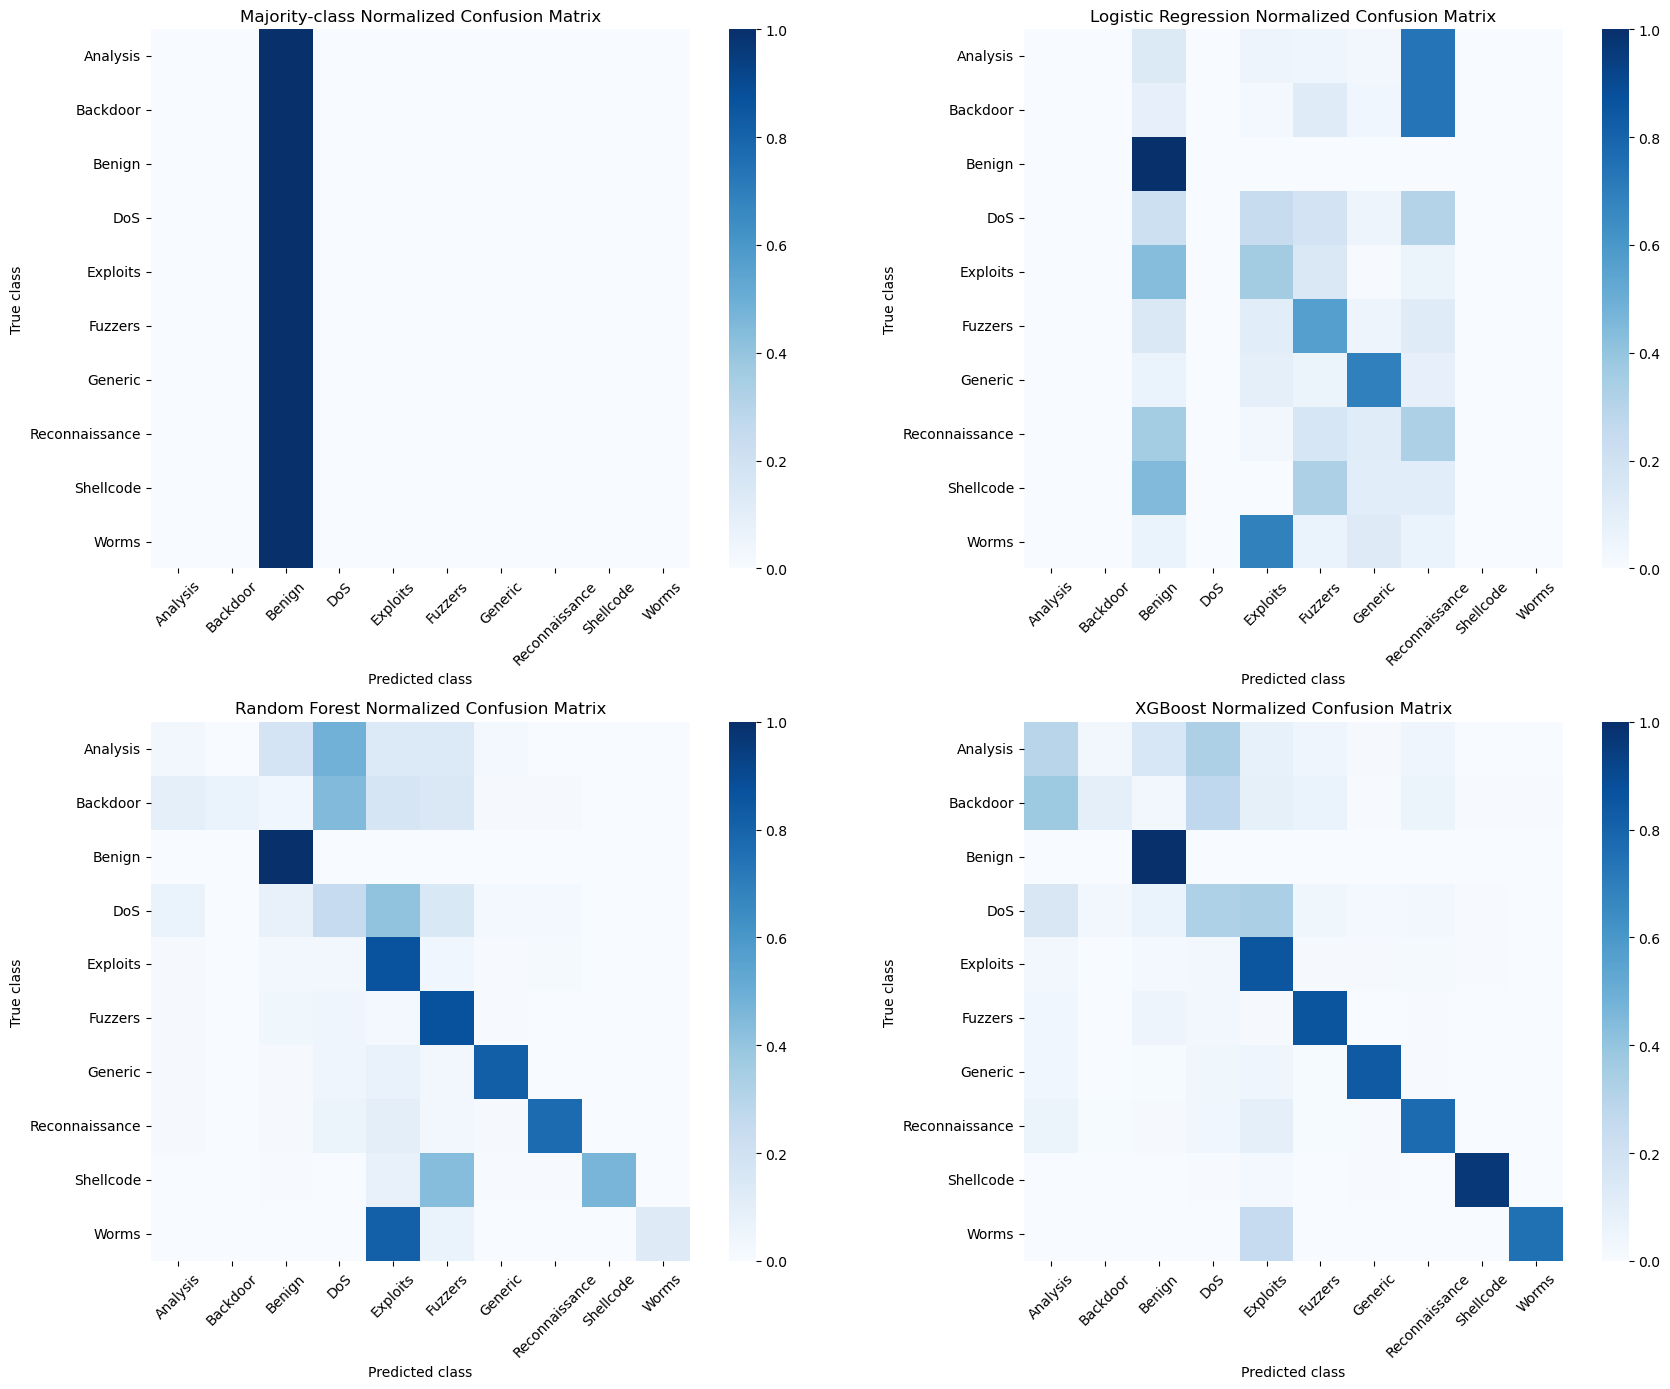

In [127]:
# Cell C1-6H: Plot normalized confusion matrices for all baselines

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for ax, model_name in zip(axes, baseline_confusion_matrices.keys()):
    sns.heatmap(
        baseline_confusion_matrices[model_name],
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True
    )
    ax.set_title(f"{model_name} Normalized Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


#### C1-6 Checkpoint: Baseline Model Training and Validation

**Mini report.**  
Four closed-set multi-class classifiers were trained and evaluated on the same processed UNSW validation split: a majority-class classifier, Logistic Regression, Random Forest, and XGBoost. No class weighting, cost-sensitive learning, rejection threshold, few-shot calibration, or robustness strategy was used in this section, so the results provide a clean baseline for later stress tests and improvement strategies.

The dataset is highly imbalanced, so accuracy alone is not used as the main decision criterion. Class imbalance is handled in this baseline section by using stratified splitting, per-class reporting, macro F1, weighted F1, and confusion matrices. More active imbalance handling is introduced later through cost-sensitive learning in Component 3B, so the Component 1 baseline remains a clean closed-set reference point.

The majority-class classifier reached high accuracy because `Benign` dominates the dataset, but its macro F1 was extremely low because it failed to detect attack classes. Logistic Regression provided a linear lower bound but failed on several minority attack classes. Random Forest improved the non-linear baseline, while XGBoost achieved the best validation performance overall. The model hyperparameter table above records the fixed manual settings used for reproducibility.

**Validation summary.**  
XGBoost achieved the highest macro F1 among the four baselines (`0.6634`), followed by Random Forest (`0.5583`), Logistic Regression (`0.2971`), and the majority-class baseline (`0.0980`). Although XGBoost also achieved high weighted F1, the per-class report and normalized confusion matrix showed that minority or similar attack classes such as `Analysis`, `Backdoor`, and `DoS` remained difficult.

**Why it matters.**  
XGBoost is selected as the main Component 2 stress-test model because it provides the strongest validation macro F1 and the clearest normalized confusion-matrix diagonal. At the same time, its remaining weaknesses give the project a clear motivation for robustness evaluation: the model performs well under ordinary closed-set validation, but its behavior under unknown attacks, distribution shift, and degraded features still needs to be tested.


### C1-7 Final Baseline Test Evaluation

This section evaluates the selected Component 1 baseline model on the held-out UNSW test split. The validation split was used to compare and select the baseline model, while the test split is used only once for final baseline performance estimation.

In [128]:
# Cell C1-7A: Evaluate selected baseline model on held-out test split

from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# Use the best validation model selected in C1-6F
selected_baseline_name = best_baseline_name
selected_baseline_model = best_baseline_model

start_time = time.time()
y_test_pred = selected_baseline_model.predict(X_test_processed).astype(int)
test_inference_time = time.time() - start_time

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")

baseline_test_summary_df = pd.DataFrame({
    "accuracy": [test_accuracy],
    "macro_f1": [test_macro_f1],
    "weighted_f1": [test_weighted_f1],
    "test_inference_time_seconds": [test_inference_time]
}, index=[selected_baseline_name])

display(baseline_test_summary_df.round(4))

baseline_test_report = classification_report(
    y_test,
    y_test_pred,
    target_names=attack_class_names,
    output_dict=True,
    zero_division=0
)

baseline_test_class_report_df = (
    pd.DataFrame(baseline_test_report)
    .transpose()
    .loc[attack_class_names]
    .round(4)
)

baseline_test_class_report_df["support"] = baseline_test_class_report_df["support"].astype(int)

display(baseline_test_class_report_df.sort_values(by="f1-score", ascending=True))

,accuracy,macro_f1,weighted_f1,test_inference_time_seconds
XGBoost,0.9894,0.6501,0.9897,1.3767


,precision,recall,f1-score,support
Backdoor,0.2662,0.0853,0.1291,434
Analysis,0.1034,0.2609,0.1481,460
DoS,0.2587,0.2580,0.2583,1159
Worms,0.7778,0.6364,0.7000,33
Reconnaissance,0.8790,0.7762,0.8244,2556
Exploits,0.8170,0.8599,0.8379,6310
Fuzzers,0.8407,0.8422,0.8415,4462
Generic,0.9459,0.8231,0.8802,3312
Shellcode,0.8435,0.9263,0.8829,285
Benign,0.9986,0.9985,0.9985,459045


#### C1-7 Checkpoint: Final Baseline Test Evaluation

**Mini report.**  
The selected Component 1 model, XGBoost, was evaluated once on the held-out UNSW test split after model selection was completed on the validation split. The model achieved a test accuracy of `0.9894`, macro F1 of `0.6501`, and weighted F1 of `0.9897`.

The test macro F1 was close to the validation macro F1 (`0.6634`), suggesting that the selected baseline did not strongly overfit the validation split. However, the class-level test report confirmed the same weakness observed during validation: `Backdoor`, `Analysis`, and `DoS` had the lowest F1 scores.

**Why it matters.**  
This test result establishes the final closed-set baseline before robustness evaluation. XGBoost performs strongly under normal same-dataset validation and testing, but its weaker minority-class behavior motivates the next component: stress testing under unknown classes, cross-dataset shift, and feature degradation.

## Component 2A : Held-Out Attack Classes and Open-Set Handling

This section focuses on the first robustness problem: **open-set attack detection**. The model is trained without selected attack classes and then tested on data where those classes reappear as unknown attacks.

The section is organized into four modules:

1. **C2A-0 Experiment Design**: define the two held-out scenarios required by the proposal.
2. **C2A-A1**: withhold weak baseline classes (`Analysis`, `Backdoor`, `DoS`).
3. **C2A-A2**: withhold common attack classes (`Exploits`, `Fuzzers`, `Generic`).
4. **C2A Final Comparison**: compare A1 and A2 and prepare the motivation for Strategy 3A.

The strategy part, **3A confidence-based rejection**, will use the confidence patterns discovered here.


<!-- C2A_GROUPING_V1 -->
### C2A-0 Experiment Design: Held-Out Scenario Selection

This short setup module defines the two held-out-class scenarios required by the proposal. No model is trained here. The goal is to make the open-set experiment design explicit before running the stress tests.

- **A1 weak classes:** `Analysis`, `Backdoor`, and `DoS`
- **A2 common attack classes:** `Exploits`, `Fuzzers`, and `Generic`


In [129]:
# Cell C2A-1: Define held-out attack-class scenarios

c2a_scenarios = {
    "A1_weak_classes": ["Analysis", "Backdoor", "DoS"],
    "A2_common_attack_classes": ["Exploits", "Fuzzers", "Generic"]
}

scenario_rows = []

for scenario_name, held_out_classes in c2a_scenarios.items():
    for attack_class in held_out_classes:
        scenario_rows.append({
            "scenario": scenario_name,
            "held_out_class": attack_class,
            "train_samples": int((y_train_text == attack_class).sum()),
            "validation_samples": int((y_val_text == attack_class).sum()),
            "test_samples": int((y_test_text == attack_class).sum())
        })

c2a_scenario_summary_df = pd.DataFrame(scenario_rows)

display(c2a_scenario_summary_df)

print("C2A held-out scenarios are ready.")

,scenario,held_out_class,train_samples,validation_samples,test_samples
0,A1_weak_classes,Analysis,1609,230,460
1,A1_weak_classes,Backdoor,1518,217,434
2,A1_weak_classes,DoS,4056,579,1159
3,A2_common_attack_classes,Exploits,22086,3155,6310
4,A2_common_attack_classes,Fuzzers,15617,2231,4462
5,A2_common_attack_classes,Generic,11592,1656,3312


C2A held-out scenarios are ready.


### C2A-A1 Scenario: Weak Attack Classes as Unknown

Scenario A1 withholds the three classes that were weakest in the closed-set baseline: `Analysis`, `Backdoor`, and `DoS`. This scenario asks whether the model can handle difficult attack categories when they are completely absent from training.

In [130]:
# Cell C2A-2: Prepare known-class training data for Scenario A1

c2a_active_scenario = "A1_weak_classes"
c2a_held_out_classes = c2a_scenarios[c2a_active_scenario]

print("Active scenario:", c2a_active_scenario)
print("Held-out unknown classes:", c2a_held_out_classes)

# Known classes are all classes except the held-out classes
c2a_known_classes = [
    cls for cls in attack_class_names
    if cls not in c2a_held_out_classes
]

print("Known classes:")
print(c2a_known_classes)

# Training and validation masks: keep only known classes
c2a_train_known_mask = ~y_train_text.isin(c2a_held_out_classes)
c2a_val_known_mask = ~y_val_text.isin(c2a_held_out_classes)

# Test masks: separate known and unknown test samples
c2a_test_known_mask = ~y_test_text.isin(c2a_held_out_classes)
c2a_test_unknown_mask = y_test_text.isin(c2a_held_out_classes)

X_train_c2a_raw = X_train_raw.loc[c2a_train_known_mask].copy()
y_train_c2a_text = y_train_text.loc[c2a_train_known_mask].copy()

X_val_c2a_raw = X_val_raw.loc[c2a_val_known_mask].copy()
y_val_c2a_text = y_val_text.loc[c2a_val_known_mask].copy()

X_test_c2a_raw = X_test_raw.copy()
y_test_c2a_text = y_test_text.copy()

c2a_split_summary_df = pd.DataFrame({
    "split": ["train_known", "validation_known", "test_known", "test_unknown", "test_all"],
    "samples": [
        len(X_train_c2a_raw),
        len(X_val_c2a_raw),
        int(c2a_test_known_mask.sum()),
        int(c2a_test_unknown_mask.sum()),
        len(X_test_c2a_raw)
    ]
})

display(c2a_split_summary_df)

print("C2A Scenario A1 data split is ready.")

Active scenario: A1_weak_classes
Held-out unknown classes: ['Analysis', 'Backdoor', 'DoS']
Known classes:
['Benign', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


,split,samples
0,train_known,1666009
1,validation_known,238001
2,test_known,476003
3,test_unknown,2053
4,test_all,478056


C2A Scenario A1 data split is ready.


In [131]:
# Cell C2A-3: Encode labels and preprocess features for Scenario A1

from sklearn.preprocessing import LabelEncoder

# Label encoder sees only known classes
c2a_label_encoder = LabelEncoder()
y_train_c2a = c2a_label_encoder.fit_transform(y_train_c2a_text)
y_val_c2a = c2a_label_encoder.transform(y_val_c2a_text)

c2a_known_class_names = c2a_label_encoder.classes_.tolist()

print("C2A known-class label mapping:")
display(pd.DataFrame({
    "encoded_label": range(len(c2a_known_class_names)),
    "known_attack_class": c2a_known_class_names
}))

# Build a fresh preprocessor with the same preprocessing design
c2a_preprocessor = ColumnTransformer(
    transformers=[
        ("log_numeric", log_numeric_pipeline, log_numeric_feature_cols),
        ("regular_numeric", regular_numeric_pipeline, regular_numeric_feature_cols),
        ("categorical", categorical_pipeline, categorical_feature_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# Fit only on known-class training data
X_train_c2a_processed = c2a_preprocessor.fit_transform(X_train_c2a_raw)

# Apply the learned preprocessing to known validation and full test data
X_val_c2a_processed = c2a_preprocessor.transform(X_val_c2a_raw)
X_test_c2a_processed = c2a_preprocessor.transform(X_test_c2a_raw)

c2a_feature_names = c2a_preprocessor.get_feature_names_out()

print("C2A processed train shape:", X_train_c2a_processed.shape)
print("C2A processed validation shape:", X_val_c2a_processed.shape)
print("C2A processed test shape:", X_test_c2a_processed.shape)
print("Number of C2A processed features:", len(c2a_feature_names))

C2A known-class label mapping:


,encoded_label,known_attack_class
0,0,Benign
1,1,Exploits
2,2,Fuzzers
3,3,Generic
4,4,Reconnaissance
5,5,Shellcode
6,6,Worms


C2A processed train shape: (1666009, 373)
C2A processed validation shape: (238001, 373)
C2A processed test shape: (478056, 373)
Number of C2A processed features: 373


In [132]:
# Cell C2A-4: Train Scenario A1 known-class XGBoost model

from xgboost import XGBClassifier
import time

c2a_xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

start_time = time.time()

c2a_xgb.fit(
    X_train_c2a_processed,
    y_train_c2a
)

c2a_train_time = time.time() - start_time

print("C2A Scenario A1 known-class XGBoost trained.")
print(f"Training time: {c2a_train_time:.2f} seconds")
print("Number of known classes:", len(c2a_known_class_names))

C2A Scenario A1 known-class XGBoost trained.
Training time: 56.33 seconds
Number of known classes: 7


In [133]:
# Cell C2A-5: Generate Scenario A1 validation and test predictions

# Predict on known-class validation data
y_val_c2a_pred = c2a_xgb.predict(X_val_c2a_processed).astype(int)
y_val_c2a_pred_names = c2a_label_encoder.inverse_transform(y_val_c2a_pred)

# Predict on full test data, including held-out unknown classes
y_test_c2a_pred = c2a_xgb.predict(X_test_c2a_processed).astype(int)
y_test_c2a_pred_names = c2a_label_encoder.inverse_transform(y_test_c2a_pred)

# Predicted probabilities for confidence analysis
y_test_c2a_proba = c2a_xgb.predict_proba(X_test_c2a_processed)
y_test_c2a_confidence = y_test_c2a_proba.max(axis=1)

print("C2A Scenario A1 predictions generated.")
print("Validation known samples:", len(y_val_c2a_pred))
print("Full test samples:", len(y_test_c2a_pred))
print("Mean test confidence:", round(y_test_c2a_confidence.mean(), 4))

C2A Scenario A1 predictions generated.
Validation known samples: 238001
Full test samples: 478056
Mean test confidence: 0.9912


In [134]:
# Cell C2A-6: Evaluate Scenario A1 performance on known validation classes

from sklearn.metrics import accuracy_score, f1_score, classification_report

c2a_val_accuracy = accuracy_score(y_val_c2a, y_val_c2a_pred)
c2a_val_macro_f1 = f1_score(y_val_c2a, y_val_c2a_pred, average="macro")
c2a_val_weighted_f1 = f1_score(y_val_c2a, y_val_c2a_pred, average="weighted")

c2a_known_validation_summary_df = pd.DataFrame({
    "accuracy": [c2a_val_accuracy],
    "macro_f1": [c2a_val_macro_f1],
    "weighted_f1": [c2a_val_weighted_f1]
}, index=[c2a_active_scenario])

display(c2a_known_validation_summary_df.round(4))

print("Known-class validation report:")
print(
    classification_report(
        y_val_c2a,
        y_val_c2a_pred,
        target_names=c2a_known_class_names,
        digits=4,
        zero_division=0
    )
)

,accuracy,macro_f1,weighted_f1
A1_weak_classes,0.9936,0.8644,0.9936


Known-class validation report:
                precision    recall  f1-score   support

        Benign     0.9988    0.9985    0.9987    229522
      Exploits     0.7966    0.9027    0.8464      3155
       Fuzzers     0.8570    0.8543    0.8557      2231
       Generic     0.9405    0.8406    0.8878      1656
Reconnaissance     0.9048    0.7809    0.8383      1278
     Shellcode     0.8544    0.9441    0.8970       143
         Worms     0.7059    0.7500    0.7273        16

      accuracy                         0.9936    238001
     macro avg     0.8654    0.8673    0.8644    238001
  weighted avg     0.9938    0.9936    0.9936    238001



In [135]:
# Cell C2A-7: Analyze Scenario A1 unknown-class predictions

c2a_test_detail_df = pd.DataFrame({
    "true_attack": y_test_c2a_text.values,
    "is_unknown": c2a_test_unknown_mask.values,
    "predicted_known_class": y_test_c2a_pred_names,
    "confidence": y_test_c2a_confidence
})
c2a_a1_detail_df = c2a_test_detail_df.copy()
unknown_detail_df = c2a_test_detail_df[c2a_test_detail_df["is_unknown"]].copy()

print("Unknown test samples:", len(unknown_detail_df))

unknown_mapping_df = pd.crosstab(
    unknown_detail_df["true_attack"],
    unknown_detail_df["predicted_known_class"],
    normalize="index"
).mul(100).round(2)

display(unknown_mapping_df)

unknown_confidence_summary_df = (
    unknown_detail_df
    .groupby("true_attack")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

display(unknown_confidence_summary_df)

Unknown test samples: 2053


predicted_known_class,Benign,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode
true_attack,,,,,,
Analysis,18.48,69.78,5.87,1.52,4.35,0.00
Backdoor,5.07,71.66,11.29,4.38,4.84,2.76
DoS,7.94,72.65,6.64,8.71,3.36,0.69


,count,mean,median,min,max
true_attack,,,,,
Analysis,460,0.3567,0.2697,0.2546,0.9179
Backdoor,434,0.3365,0.2700,0.2332,0.9999
DoS,1159,0.6130,0.6662,0.2468,1.0000


,count,mean,median,min,max
group,,,,,
Known classes,476003,0.9933,1.000,0.2332,1.0
Unknown held-out,2053,0.4972,0.292,0.2332,1.0


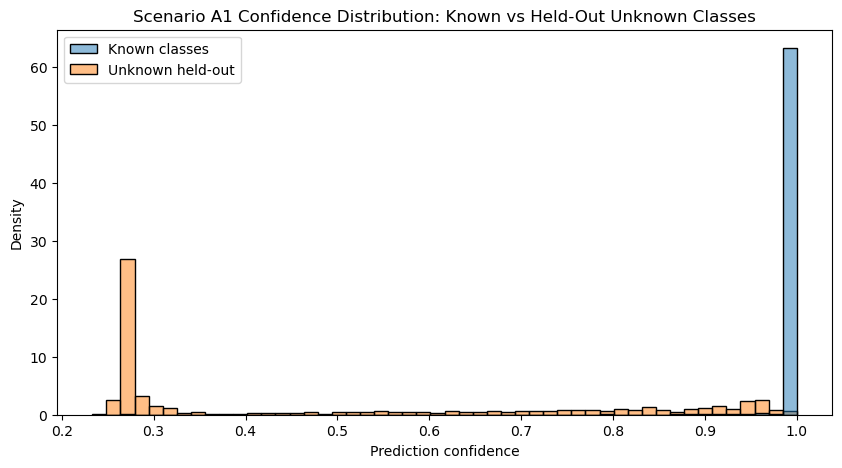

In [136]:
# Cell C2A-8: Compare confidence between known and unknown test samples

confidence_group_summary_df = (
    c2a_test_detail_df
    .assign(group=np.where(c2a_test_detail_df["is_unknown"], "Unknown held-out", "Known classes"))
    .groupby("group")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

display(confidence_group_summary_df)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=c2a_test_detail_df,
    x="confidence",
    hue=np.where(c2a_test_detail_df["is_unknown"], "Unknown held-out", "Known classes"),
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Scenario A1 Confidence Distribution: Known vs Held-Out Unknown Classes")
plt.xlabel("Prediction confidence")
plt.ylabel("Density")
plt.show()

In [137]:
# Cell C2A-9: Summarize Scenario A1 open-set stress-test findings

unknown_main_mapping_rows = []

for true_attack, group_df in unknown_detail_df.groupby("true_attack"):
    top_pred = group_df["predicted_known_class"].value_counts(normalize=True).idxmax()
    top_percent = group_df["predicted_known_class"].value_counts(normalize=True).max() * 100
    
    unknown_main_mapping_rows.append({
        "held_out_class": true_attack,
        "unknown_samples": len(group_df),
        "most_common_predicted_known_class": top_pred,
        "mapped_percent": top_percent,
        "mean_confidence": group_df["confidence"].mean(),
        "median_confidence": group_df["confidence"].median()
    })

c2a_a1_unknown_summary_df = (
    pd.DataFrame(unknown_main_mapping_rows)
    .sort_values(by="held_out_class")
    .round(4)
)

c2a_a1_overall_summary_df = pd.DataFrame({
    "scenario": [c2a_active_scenario],
    "held_out_classes": [", ".join(c2a_held_out_classes)],
    "known_validation_macro_f1": [c2a_val_macro_f1],
    "known_validation_weighted_f1": [c2a_val_weighted_f1],
    "unknown_samples": [len(unknown_detail_df)],
    "unknown_mean_confidence": [unknown_detail_df["confidence"].mean()],
    "unknown_median_confidence": [unknown_detail_df["confidence"].median()]
}).round(4)

display(c2a_a1_overall_summary_df)
display(c2a_a1_unknown_summary_df)

,scenario,held_out_classes,known_validation_macro_f1,known_validation_weighted_f1,unknown_samples,unknown_mean_confidence,unknown_median_confidence
0,A1_weak_classes,"Analysis, Backdoor, DoS",0.8644,0.9936,2053,0.4972,0.292


,held_out_class,unknown_samples,most_common_predicted_known_class,mapped_percent,mean_confidence,median_confidence
0,Analysis,460,Exploits,69.7826,0.3567,0.2697
1,Backdoor,434,Exploits,71.6590,0.3365,0.2700
2,DoS,1159,Exploits,72.6488,0.6130,0.6662


#### C2A-A1 Checkpoint: Held-Out Weak Attack Classes

**Mini report.**  
Scenario A1 withheld three weak baseline classes, `Analysis`, `Backdoor`, and `DoS`, from training. The model was trained only on the remaining known classes and then tested on the full UNSW test split, including the held-out unknown classes.

On known validation classes, the model achieved a macro F1 of `0.8644`, showing that it still classified the seen classes well. However, all three held-out attack classes were mostly mapped to `Exploits`: `Analysis` mapped to `Exploits` for `69.78%` of samples, `Backdoor` for `71.66%`, and `DoS` for `72.65%`.

The confidence analysis showed that unknown samples had much lower confidence overall than known-class samples. Known-class test samples had mean confidence `0.9933`, while held-out unknown samples had mean confidence `0.4972` and median confidence `0.2920`. However, `DoS` was more problematic because its unknown predictions had higher confidence than `Analysis` and `Backdoor`.

**Why it matters.**  
This stress test shows a clear open-set failure mode: when the model sees attack categories that were absent from training, it does not recognize them as unknown. Instead, it confidently maps many of them to the closest known attack class, especially `Exploits`. The lower confidence of many unknown samples suggests that confidence-based rejection may help, but high-confidence unknown `DoS` samples show that confidence alone may not fully solve the problem.

### C2A-A2 Scenario: Common Attack Classes as Unknown

Scenario A2 withholds larger and more common attack classes: `Exploits`, `Fuzzers`, and `Generic`. This scenario tests a more dangerous deployment case: common attack families may appear as unseen classes.

In [138]:
# Cell C2A-10: Prepare known-class training data for Scenario A2

c2a_active_scenario = "A2_common_attack_classes"
c2a_held_out_classes = c2a_scenarios[c2a_active_scenario]

print("Active scenario:", c2a_active_scenario)
print("Held-out unknown classes:", c2a_held_out_classes)

# Known classes are all classes except the held-out classes
c2a_known_classes = [
    cls for cls in attack_class_names
    if cls not in c2a_held_out_classes
]

print("Known classes:")
print(c2a_known_classes)

# Training and validation masks: keep only known classes
c2a_train_known_mask = ~y_train_text.isin(c2a_held_out_classes)
c2a_val_known_mask = ~y_val_text.isin(c2a_held_out_classes)

# Test masks: separate known and unknown test samples
c2a_test_known_mask = ~y_test_text.isin(c2a_held_out_classes)
c2a_test_unknown_mask = y_test_text.isin(c2a_held_out_classes)

X_train_c2a_raw = X_train_raw.loc[c2a_train_known_mask].copy()
y_train_c2a_text = y_train_text.loc[c2a_train_known_mask].copy()

X_val_c2a_raw = X_val_raw.loc[c2a_val_known_mask].copy()
y_val_c2a_text = y_val_text.loc[c2a_val_known_mask].copy()

X_test_c2a_raw = X_test_raw.copy()
y_test_c2a_text = y_test_text.copy()

c2a_split_summary_df = pd.DataFrame({
    "split": ["train_known", "validation_known", "test_known", "test_unknown", "test_all"],
    "samples": [
        len(X_train_c2a_raw),
        len(X_val_c2a_raw),
        int(c2a_test_known_mask.sum()),
        int(c2a_test_unknown_mask.sum()),
        len(X_test_c2a_raw)
    ]
})

display(c2a_split_summary_df)

print("C2A Scenario A2 data split is ready.")

Active scenario: A2_common_attack_classes
Held-out unknown classes: ['Exploits', 'Fuzzers', 'Generic']
Known classes:
['Analysis', 'Backdoor', 'Benign', 'DoS', 'Reconnaissance', 'Shellcode', 'Worms']


,split,samples
0,train_known,1623897
1,validation_known,231985
2,test_known,463972
3,test_unknown,14084
4,test_all,478056


C2A Scenario A2 data split is ready.


In [139]:
# Cell C2A-11: Encode labels and preprocess features for Scenario A2

from sklearn.preprocessing import LabelEncoder

# Label encoder sees only known classes
c2a_label_encoder = LabelEncoder()
y_train_c2a = c2a_label_encoder.fit_transform(y_train_c2a_text)
y_val_c2a = c2a_label_encoder.transform(y_val_c2a_text)

c2a_known_class_names = c2a_label_encoder.classes_.tolist()

print("C2A Scenario A2 known-class label mapping:")
display(pd.DataFrame({
    "encoded_label": range(len(c2a_known_class_names)),
    "known_attack_class": c2a_known_class_names
}))

# Build a fresh preprocessor with the same preprocessing design
c2a_preprocessor = ColumnTransformer(
    transformers=[
        ("log_numeric", log_numeric_pipeline, log_numeric_feature_cols),
        ("regular_numeric", regular_numeric_pipeline, regular_numeric_feature_cols),
        ("categorical", categorical_pipeline, categorical_feature_cols)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# Fit only on known-class training data
X_train_c2a_processed = c2a_preprocessor.fit_transform(X_train_c2a_raw)

# Apply the learned preprocessing to known validation and full test data
X_val_c2a_processed = c2a_preprocessor.transform(X_val_c2a_raw)
X_test_c2a_processed = c2a_preprocessor.transform(X_test_c2a_raw)

c2a_feature_names = c2a_preprocessor.get_feature_names_out()

print("C2A Scenario A2 processed train shape:", X_train_c2a_processed.shape)
print("C2A Scenario A2 processed validation shape:", X_val_c2a_processed.shape)
print("C2A Scenario A2 processed test shape:", X_test_c2a_processed.shape)
print("Number of C2A Scenario A2 processed features:", len(c2a_feature_names))

C2A Scenario A2 known-class label mapping:


,encoded_label,known_attack_class
0,0,Analysis
1,1,Backdoor
2,2,Benign
3,3,DoS
4,4,Reconnaissance
5,5,Shellcode
6,6,Worms


C2A Scenario A2 processed train shape: (1623897, 371)
C2A Scenario A2 processed validation shape: (231985, 371)
C2A Scenario A2 processed test shape: (478056, 371)
Number of C2A Scenario A2 processed features: 371


In [140]:
# Cell C2A-12: Train Scenario A2 known-class XGBoost model

from xgboost import XGBClassifier
import time

c2a_xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

start_time = time.time()

c2a_xgb.fit(
    X_train_c2a_processed,
    y_train_c2a
)

c2a_train_time = time.time() - start_time

print("C2A Scenario A2 known-class XGBoost trained.")
print(f"Training time: {c2a_train_time:.2f} seconds")
print("Number of known classes:", len(c2a_known_class_names))

C2A Scenario A2 known-class XGBoost trained.
Training time: 58.54 seconds
Number of known classes: 7


In [141]:
# Cell C2A-13: Generate Scenario A2 validation and test predictions

# Predict on known-class validation data
y_val_c2a_pred = c2a_xgb.predict(X_val_c2a_processed).astype(int)
y_val_c2a_pred_names = c2a_label_encoder.inverse_transform(y_val_c2a_pred)

# Predict on full test data, including held-out unknown classes
y_test_c2a_pred = c2a_xgb.predict(X_test_c2a_processed).astype(int)
y_test_c2a_pred_names = c2a_label_encoder.inverse_transform(y_test_c2a_pred)

# Predicted probabilities for confidence analysis
y_test_c2a_proba = c2a_xgb.predict_proba(X_test_c2a_processed)
y_test_c2a_confidence = y_test_c2a_proba.max(axis=1)

print("C2A Scenario A2 predictions generated.")
print("Validation known samples:", len(y_val_c2a_pred))
print("Full test samples:", len(y_test_c2a_pred))
print("Mean test confidence:", round(y_test_c2a_confidence.mean(), 4))

C2A Scenario A2 predictions generated.
Validation known samples: 231985
Full test samples: 478056
Mean test confidence: 0.9911


In [142]:
# Cell C2A-14: Evaluate Scenario A2 performance on known validation classes

from sklearn.metrics import accuracy_score, f1_score, classification_report

c2a_val_accuracy = accuracy_score(y_val_c2a, y_val_c2a_pred)
c2a_val_macro_f1 = f1_score(y_val_c2a, y_val_c2a_pred, average="macro")
c2a_val_weighted_f1 = f1_score(y_val_c2a, y_val_c2a_pred, average="weighted")

c2a_known_validation_summary_df = pd.DataFrame({
    "accuracy": [c2a_val_accuracy],
    "macro_f1": [c2a_val_macro_f1],
    "weighted_f1": [c2a_val_weighted_f1]
}, index=[c2a_active_scenario])

display(c2a_known_validation_summary_df.round(4))

print("Known-class validation report:")
print(
    classification_report(
        y_val_c2a,
        y_val_c2a_pred,
        target_names=c2a_known_class_names,
        digits=4,
        zero_division=0
    )
)

,accuracy,macro_f1,weighted_f1
A2_common_attack_classes,0.9961,0.6386,0.9959


Known-class validation report:
                precision    recall  f1-score   support

      Analysis     0.1231    0.0348    0.0542       230
      Backdoor     0.3906    0.1152    0.1779       217
        Benign     0.9992    0.9995    0.9993    229522
           DoS     0.4227    0.6943    0.5255       579
Reconnaissance     0.9545    0.8537    0.9013      1278
     Shellcode     0.8910    0.9720    0.9298       143
         Worms     0.8333    0.9375    0.8824        16

      accuracy                         0.9961    231985
     macro avg     0.6592    0.6581    0.6386    231985
  weighted avg     0.9960    0.9961    0.9959    231985



In [143]:
# Cell C2A-15: Analyze Scenario A2 unknown-class predictions

c2a_test_detail_df = pd.DataFrame({
    "true_attack": y_test_c2a_text.values,
    "is_unknown": c2a_test_unknown_mask.values,
    "predicted_known_class": y_test_c2a_pred_names,
    "confidence": y_test_c2a_confidence
})

c2a_a2_detail_df = c2a_test_detail_df.copy()

unknown_detail_df = c2a_test_detail_df[c2a_test_detail_df["is_unknown"]].copy()

print("Unknown test samples:", len(unknown_detail_df))

unknown_mapping_df = pd.crosstab(
    unknown_detail_df["true_attack"],
    unknown_detail_df["predicted_known_class"],
    normalize="index"
).mul(100).round(2)

display(unknown_mapping_df)

unknown_confidence_summary_df = (
    unknown_detail_df
    .groupby("true_attack")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

display(unknown_confidence_summary_df)

Unknown test samples: 14084


predicted_known_class,Analysis,Backdoor,Benign,DoS,Reconnaissance,Shellcode,Worms
true_attack,,,,,,,
Exploits,0.36,1.32,36.55,52.16,7.83,1.58,0.21
Fuzzers,0.65,0.34,64.12,23.38,7.71,3.77,0.04
Generic,0.57,1.33,73.76,21.80,1.27,1.03,0.24


,count,mean,median,min,max
true_attack,,,,,
Exploits,6310,0.7340,0.7272,0.2735,1.0
Fuzzers,4462,0.8429,0.9354,0.2703,1.0
Generic,3312,0.8668,1.0000,0.2693,1.0


,count,mean,median,min,max
group,,,,,
Known classes,463972,0.9969,1.000,0.2693,1.0
Unknown held-out,14084,0.7997,0.896,0.2693,1.0


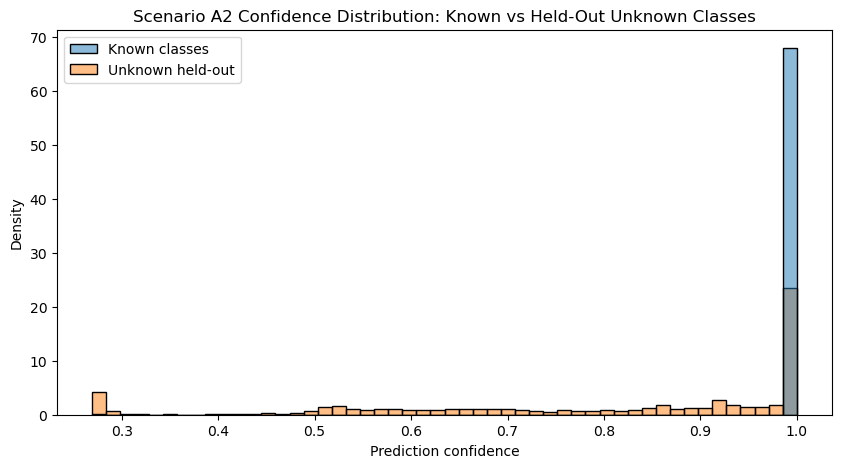

In [144]:
# Cell C2A-16: Compare Scenario A2 confidence between known and unknown test samples

confidence_group_summary_df = (
    c2a_test_detail_df
    .assign(group=np.where(c2a_test_detail_df["is_unknown"], "Unknown held-out", "Known classes"))
    .groupby("group")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

display(confidence_group_summary_df)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=c2a_test_detail_df,
    x="confidence",
    hue=np.where(c2a_test_detail_df["is_unknown"], "Unknown held-out", "Known classes"),
    bins=50,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Scenario A2 Confidence Distribution: Known vs Held-Out Unknown Classes")
plt.xlabel("Prediction confidence")
plt.ylabel("Density")
plt.show()

In [145]:
# Cell C2A-17: Summarize Scenario A2 open-set stress-test findings

unknown_main_mapping_rows = []

for true_attack, group_df in unknown_detail_df.groupby("true_attack"):
    top_pred = group_df["predicted_known_class"].value_counts(normalize=True).idxmax()
    top_percent = group_df["predicted_known_class"].value_counts(normalize=True).max() * 100
    
    unknown_main_mapping_rows.append({
        "held_out_class": true_attack,
        "unknown_samples": len(group_df),
        "most_common_predicted_known_class": top_pred,
        "mapped_percent": top_percent,
        "mean_confidence": group_df["confidence"].mean(),
        "median_confidence": group_df["confidence"].median()
    })

c2a_a2_unknown_summary_df = (
    pd.DataFrame(unknown_main_mapping_rows)
    .sort_values(by="held_out_class")
    .round(4)
)

c2a_a2_overall_summary_df = pd.DataFrame({
    "scenario": [c2a_active_scenario],
    "held_out_classes": [", ".join(c2a_held_out_classes)],
    "known_validation_macro_f1": [c2a_val_macro_f1],
    "known_validation_weighted_f1": [c2a_val_weighted_f1],
    "unknown_samples": [len(unknown_detail_df)],
    "unknown_mean_confidence": [unknown_detail_df["confidence"].mean()],
    "unknown_median_confidence": [unknown_detail_df["confidence"].median()]
}).round(4)

display(c2a_a2_overall_summary_df)
display(c2a_a2_unknown_summary_df)

,scenario,held_out_classes,known_validation_macro_f1,known_validation_weighted_f1,unknown_samples,unknown_mean_confidence,unknown_median_confidence
0,A2_common_attack_classes,"Exploits, Fuzzers, Generic",0.6386,0.9959,14084,0.7997,0.896


,held_out_class,unknown_samples,most_common_predicted_known_class,mapped_percent,mean_confidence,median_confidence
0,Exploits,6310,DoS,52.1553,0.7340,0.7272
1,Fuzzers,4462,Benign,64.1192,0.8429,0.9354
2,Generic,3312,Benign,73.7621,0.8668,1.0000


<!-- C2A_GROUPING_V1 -->
### C2A Final Comparison: A1 vs A2

This final module combines the two held-out scenarios. The comparison shows how open-set behavior changes depending on which attack classes are withheld.


In [146]:
# Cell C2A-18: Combine Scenario A1 and A2 summaries

c2a_overall_summary_df = pd.concat(
    [c2a_a1_overall_summary_df, c2a_a2_overall_summary_df],
    ignore_index=True
)

c2a_unknown_summary_df = pd.concat(
    [c2a_a1_unknown_summary_df, c2a_a2_unknown_summary_df],
    ignore_index=True
)

display(c2a_overall_summary_df)
display(c2a_unknown_summary_df)

,scenario,held_out_classes,known_validation_macro_f1,known_validation_weighted_f1,unknown_samples,unknown_mean_confidence,unknown_median_confidence
0,A1_weak_classes,"Analysis, Backdoor, DoS",0.8644,0.9936,2053,0.4972,0.292
1,A2_common_attack_classes,"Exploits, Fuzzers, Generic",0.6386,0.9959,14084,0.7997,0.896


,held_out_class,unknown_samples,most_common_predicted_known_class,mapped_percent,mean_confidence,median_confidence
0,Analysis,460,Exploits,69.7826,0.3567,0.2697
1,Backdoor,434,Exploits,71.6590,0.3365,0.2700
2,DoS,1159,Exploits,72.6488,0.6130,0.6662
3,Exploits,6310,DoS,52.1553,0.7340,0.7272
4,Fuzzers,4462,Benign,64.1192,0.8429,0.9354
5,Generic,3312,Benign,73.7621,0.8668,1.0000


### C2A-3 Full Open-Set Mapping Matrix

The proposal asks for a full confusion-style view of held-out attack behavior. Because the Scenario A models are trained only on known classes, they cannot output the withheld unknown class names. Therefore, the table below reports a row-normalized mapping matrix: each true attack class is mapped to the known class predicted by the model.


In [147]:
# Cell C2A-19: Build full open-set mapping matrices for A1 and A2
# Purpose:
# - Provide a confusion-style matrix for all true classes
# - Show how known and unknown classes map into the known output space

def build_open_set_mapping_matrix(detail_df):
    mapping_df = pd.crosstab(
        detail_df["true_attack"],
        detail_df["predicted_known_class"],
        normalize="index"
    ).mul(100).round(2)
    
    sample_counts = detail_df["true_attack"].value_counts().rename("samples")
    mapping_df = mapping_df.join(sample_counts)
    
    ordered_columns = ["samples"] + [
        col for col in mapping_df.columns
        if col != "samples"
    ]
    
    return mapping_df[ordered_columns]

c2a_a1_full_mapping_df = build_open_set_mapping_matrix(c2a_a1_detail_df)
c2a_a2_full_mapping_df = build_open_set_mapping_matrix(c2a_a2_detail_df)

print("Scenario A1 full open-set mapping matrix:")
display(c2a_a1_full_mapping_df)

print("Scenario A2 full open-set mapping matrix:")
display(c2a_a2_full_mapping_df)


Scenario A1 full open-set mapping matrix:


,samples,Benign,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
true_attack,,,,,,,,
Analysis,460,18.48,69.78,5.87,1.52,4.35,0.00,0.00
Backdoor,434,5.07,71.66,11.29,4.38,4.84,2.76,0.00
Benign,459045,99.85,0.04,0.10,0.00,0.00,0.00,0.00
DoS,1159,7.94,72.65,6.64,8.71,3.36,0.69,0.00
Exploits,6310,2.71,91.00,1.77,1.38,2.44,0.59,0.11
Fuzzers,4462,6.16,8.58,84.27,0.36,0.63,0.00,0.00
Generic,3312,1.48,12.32,2.42,82.64,1.09,0.06,0.00
Reconnaissance,2556,1.13,18.43,1.88,0.55,78.01,0.00,0.00
Shellcode,285,0.70,4.56,0.00,0.00,0.00,94.74,0.00


Scenario A2 full open-set mapping matrix:


,samples,Analysis,Backdoor,Benign,DoS,Reconnaissance,Shellcode,Worms
true_attack,,,,,,,,
Analysis,460,3.91,1.52,18.91,74.35,1.30,0.00,0.00
Backdoor,434,8.06,9.45,6.91,67.74,6.45,1.38,0.00
Benign,459045,0.00,0.00,99.96,0.03,0.00,0.00,0.00
DoS,1159,2.33,2.50,18.21,70.49,5.35,0.95,0.17
Exploits,6310,0.36,1.32,36.55,52.16,7.83,1.58,0.21
Fuzzers,4462,0.65,0.34,64.12,23.38,7.71,3.77,0.04
Generic,3312,0.57,1.33,73.76,21.80,1.27,1.03,0.24
Reconnaissance,2556,1.02,0.47,1.76,11.93,84.82,0.00,0.00
Shellcode,285,0.00,1.75,1.40,2.11,0.70,94.04,0.00


#### C2A Checkpoint: Held-Out Attack-Class Stress Test

**Mini report.**  
Stress Test A evaluated open-set robustness by withholding attack classes from training and reintroducing them only during testing. Two held-out scenarios were tested as required by the proposal.

In Scenario A1, `Analysis`, `Backdoor`, and `DoS` were withheld. The known-class validation macro F1 was `0.8644`, showing that the model still performed well on classes it had seen during training. However, the held-out unknown classes were mostly mapped to `Exploits`: `Analysis` mapped to `Exploits` for `69.78%` of samples, `Backdoor` for `71.66%`, and `DoS` for `72.65%`. Their median unknown confidence was relatively low at `0.2920`.

In Scenario A2, `Exploits`, `Fuzzers`, and `Generic` were withheld. The known-class validation macro F1 dropped to `0.6386` because the remaining known classes included harder minority classes such as `Analysis`, `Backdoor`, and `DoS`. The open-set failure was more severe: `Fuzzers` mapped to `Benign` for `64.12%` of samples, and `Generic` mapped to `Benign` for `73.76%`. The median unknown confidence was high at `0.8960`.

**Why it matters.**  
These results show that the model does not naturally recognize unseen attack classes as unknown. Instead, it forces them into known categories. Scenario A1 suggests that confidence-based rejection may help because many unknown samples have low confidence. Scenario A2 is more dangerous because many unknown attacks are confidently classified as `Benign`, creating a silent failure mode that may not be solved by confidence thresholding alone.


## Component 3A: Open-Set Handling Strategies

This section improves the open-set failures found in Component 2A. Two strategies are tested:

1. **Confidence Thresholding with Rejection**: low-confidence predictions are rejected as `UNKNOWN`.
2. **One-Class Anomaly Fallback with Isolation Forest**: samples predicted as `Benign` are checked by a Benign-only anomaly detector.

The goal is not to add a trained `UNKNOWN` class. Instead, `UNKNOWN` is created by decision rules after prediction, which better matches the open-set setting where unknown attack classes are absent during training.


### C3A Strategy 1: Confidence Thresholding with Rejection

This strategy uses prediction confidence as an uncertainty signal. If the maximum predicted probability is below a threshold, the sample is rejected as `UNKNOWN`; otherwise, the original known-class prediction is accepted.


In [148]:
# Cell C3A-1: Prepare C2A detail tables for threshold analysis
# Purpose:
# - Use the sample-level prediction tables saved in C2A
# - A1 represents lower-confidence unknowns
# - A2 represents high-confidence unknowns, often predicted as Benign

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c3a_a1_detail_df = c2a_a1_detail_df.copy()
c3a_a2_detail_df = c2a_a2_detail_df.copy()

c3a_detail_summary_df = pd.DataFrame({
    "scenario": ["A1_weak_classes", "A2_common_attack_classes"],
    "samples": [len(c3a_a1_detail_df), len(c3a_a2_detail_df)],
    "unknown_samples": [
        int(c3a_a1_detail_df["is_unknown"].sum()),
        int(c3a_a2_detail_df["is_unknown"].sum())
    ],
    "unknown_mean_confidence": [
        c3a_a1_detail_df.loc[c3a_a1_detail_df["is_unknown"], "confidence"].mean(),
        c3a_a2_detail_df.loc[c3a_a2_detail_df["is_unknown"], "confidence"].mean()
    ],
    "unknown_median_confidence": [
        c3a_a1_detail_df.loc[c3a_a1_detail_df["is_unknown"], "confidence"].median(),
        c3a_a2_detail_df.loc[c3a_a2_detail_df["is_unknown"], "confidence"].median()
    ]
}).round(4)

display(c3a_detail_summary_df)


,scenario,samples,unknown_samples,unknown_mean_confidence,unknown_median_confidence
0,A1_weak_classes,478056,2053,0.4972,0.292
1,A2_common_attack_classes,478056,14084,0.7997,0.896


In [149]:
# Cell C3A-1B: AUROC of confidence as an unknown-class detector
# Purpose:
# - Satisfy the proposal metric for Stress Test A
# - Use 1 - confidence because lower classifier confidence should indicate higher unknown risk

from sklearn.metrics import roc_auc_score

c3a_confidence_auroc_rows = []

for scenario_name, detail_df in [
    ("A1_weak_classes", c3a_a1_detail_df),
    ("A2_common_attack_classes", c3a_a2_detail_df)
]:
    y_unknown = detail_df["is_unknown"].astype(int)
    unknown_score = 1 - detail_df["confidence"]
    
    c3a_confidence_auroc_rows.append({
        "scenario": scenario_name,
        "unknown_detector_score": "1 - confidence",
        "known_samples": int((~detail_df["is_unknown"]).sum()),
        "unknown_samples": int(detail_df["is_unknown"].sum()),
        "auroc": roc_auc_score(y_unknown, unknown_score)
    })

c3a_confidence_auroc_df = pd.DataFrame(c3a_confidence_auroc_rows)
display(c3a_confidence_auroc_df.round(4))


,scenario,unknown_detector_score,known_samples,unknown_samples,auroc
0,A1_weak_classes,1 - confidence,476003,2053,0.9931
1,A2_common_attack_classes,1 - confidence,463972,14084,0.8810


In [150]:
# Cell C3A-2: Sweep confidence thresholds for Scenario A1
# Purpose:
# - Reject samples with confidence below the threshold
# - Measure unknown rejection, known false rejection, coverage, and accepted known-class accuracy

c3a_thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
c3a_a1_threshold_rows = []

for threshold in c3a_thresholds:
    rejected = c3a_a1_detail_df["confidence"] < threshold
    accepted = ~rejected
    
    known_mask = ~c3a_a1_detail_df["is_unknown"]
    unknown_mask = c3a_a1_detail_df["is_unknown"]
    
    accepted_known_mask = accepted & known_mask
    accepted_known_accuracy = (
        (
            c3a_a1_detail_df.loc[accepted_known_mask, "true_attack"] ==
            c3a_a1_detail_df.loc[accepted_known_mask, "predicted_known_class"]
        ).mean()
        if accepted_known_mask.sum() else np.nan
    )
    
    c3a_a1_threshold_rows.append({
        "threshold": threshold,
        "overall_coverage": accepted.mean(),
        "accepted_known_accuracy": accepted_known_accuracy,
        "known_rejection_rate": rejected[known_mask].mean(),
        "unknown_rejection_rate": rejected[unknown_mask].mean(),
        "known_accepted_samples": int(accepted_known_mask.sum()),
        "known_rejected_samples": int((rejected & known_mask).sum()),
        "unknown_accepted_samples": int((accepted & unknown_mask).sum()),
        "unknown_rejected_samples": int((rejected & unknown_mask).sum())
    })

c3a_a1_threshold_df = pd.DataFrame(c3a_a1_threshold_rows).round(4)
display(c3a_a1_threshold_df)


,threshold,overall_coverage,accepted_known_accuracy,known_rejection_rate,unknown_rejection_rate,known_accepted_samples,known_rejected_samples,unknown_accepted_samples,unknown_rejected_samples
0,0.50,0.9934,0.9965,0.0041,0.5923,474061,1942,837,1216
1,0.60,0.9913,0.9973,0.0060,0.6400,473167,2836,739,1314
2,0.70,0.9885,0.9982,0.0085,0.6951,471944,4059,626,1427
3,0.80,0.9850,0.9990,0.0118,0.7657,470408,5595,481,1572
4,0.90,0.9801,0.9995,0.0163,0.8558,468261,7742,296,1757
5,0.95,0.9744,0.9998,0.0217,0.9250,465685,10318,154,1899
6,0.99,0.9659,1.0000,0.0299,0.9912,461751,14252,18,2035


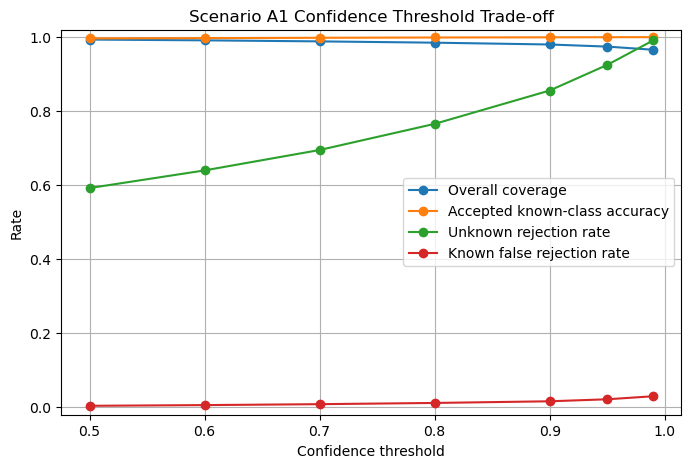

In [151]:
# Cell C3A-3: Plot Scenario A1 threshold trade-off
# Purpose:
# - Show the proposal-required coverage vs accepted accuracy relationship
# - Also show unknown rejection and known false rejection for deployment interpretation

plt.figure(figsize=(8, 5))
plt.plot(
    c3a_a1_threshold_df["threshold"],
    c3a_a1_threshold_df["overall_coverage"],
    marker="o",
    label="Overall coverage"
)
plt.plot(
    c3a_a1_threshold_df["threshold"],
    c3a_a1_threshold_df["accepted_known_accuracy"],
    marker="o",
    label="Accepted known-class accuracy"
)
plt.plot(
    c3a_a1_threshold_df["threshold"],
    c3a_a1_threshold_df["unknown_rejection_rate"],
    marker="o",
    label="Unknown rejection rate"
)
plt.plot(
    c3a_a1_threshold_df["threshold"],
    c3a_a1_threshold_df["known_rejection_rate"],
    marker="o",
    label="Known false rejection rate"
)
plt.title("Scenario A1 Confidence Threshold Trade-off")
plt.xlabel("Confidence threshold")
plt.ylabel("Rate")
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend()
plt.show()


In [152]:
# Cell C3A-4: Sweep confidence thresholds for Scenario A2
# Purpose:
# - Apply the same rejection rule to A2
# - A2 is harder because many unknown attacks have high confidence

c3a_a2_threshold_rows = []

for threshold in c3a_thresholds:
    rejected = c3a_a2_detail_df["confidence"] < threshold
    accepted = ~rejected
    
    known_mask = ~c3a_a2_detail_df["is_unknown"]
    unknown_mask = c3a_a2_detail_df["is_unknown"]
    
    accepted_known_mask = accepted & known_mask
    accepted_known_accuracy = (
        (
            c3a_a2_detail_df.loc[accepted_known_mask, "true_attack"] ==
            c3a_a2_detail_df.loc[accepted_known_mask, "predicted_known_class"]
        ).mean()
        if accepted_known_mask.sum() else np.nan
    )
    
    c3a_a2_threshold_rows.append({
        "threshold": threshold,
        "overall_coverage": accepted.mean(),
        "accepted_known_accuracy": accepted_known_accuracy,
        "known_rejection_rate": rejected[known_mask].mean(),
        "unknown_rejection_rate": rejected[unknown_mask].mean(),
        "known_accepted_samples": int(accepted_known_mask.sum()),
        "known_rejected_samples": int((rejected & known_mask).sum()),
        "unknown_accepted_samples": int((accepted & unknown_mask).sum()),
        "unknown_rejected_samples": int((rejected & unknown_mask).sum())
    })

c3a_a2_threshold_df = pd.DataFrame(c3a_a2_threshold_rows).round(4)
display(c3a_a2_threshold_df)


,threshold,overall_coverage,accepted_known_accuracy,known_rejection_rate,unknown_rejection_rate,known_accepted_samples,known_rejected_samples,unknown_accepted_samples,unknown_rejected_samples
0,0.50,0.9941,0.9984,0.0031,0.0982,462550,1422,12701,1383
1,0.60,0.9901,0.9987,0.0036,0.2168,462280,1692,11030,3054
2,0.70,0.9867,0.9989,0.0041,0.3157,462057,1915,9637,4447
3,0.80,0.9836,0.9992,0.0050,0.3924,461653,2319,8558,5526
4,0.90,0.9789,0.9994,0.0063,0.5061,461032,2940,6956,7128
5,0.95,0.9752,0.9995,0.0073,0.6009,460594,3378,5621,8463
6,0.99,0.9723,0.9996,0.0084,0.6658,460091,3881,4707,9377


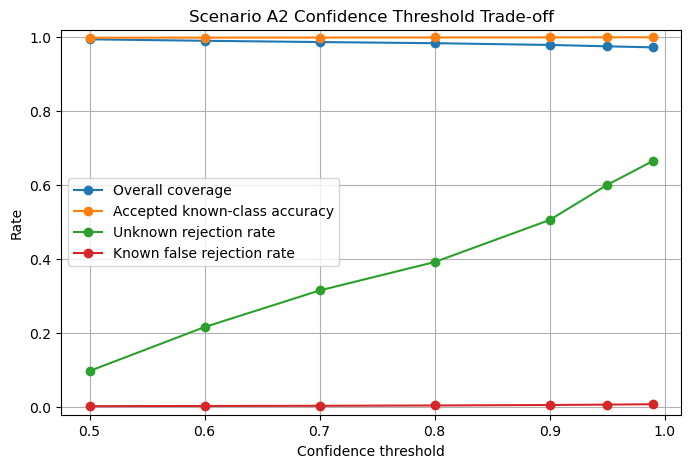

In [153]:
# Cell C3A-5: Plot Scenario A2 threshold trade-off
# Purpose:
# - Show whether confidence thresholding remains useful for high-confidence unknowns

plt.figure(figsize=(8, 5))
plt.plot(
    c3a_a2_threshold_df["threshold"],
    c3a_a2_threshold_df["overall_coverage"],
    marker="o",
    label="Overall coverage"
)
plt.plot(
    c3a_a2_threshold_df["threshold"],
    c3a_a2_threshold_df["accepted_known_accuracy"],
    marker="o",
    label="Accepted known-class accuracy"
)
plt.plot(
    c3a_a2_threshold_df["threshold"],
    c3a_a2_threshold_df["unknown_rejection_rate"],
    marker="o",
    label="Unknown rejection rate"
)
plt.plot(
    c3a_a2_threshold_df["threshold"],
    c3a_a2_threshold_df["known_rejection_rate"],
    marker="o",
    label="Known false rejection rate"
)
plt.title("Scenario A2 Confidence Threshold Trade-off")
plt.xlabel("Confidence threshold")
plt.ylabel("Rate")
plt.ylim(-0.02, 1.02)
plt.grid(True)
plt.legend()
plt.show()


In [154]:
# Cell C3A-6: Compare selected threshold on A1 and A2
# Purpose:
# - Use threshold = 0.90 as the practical operating point
# - Compare rejection, coverage, and accepted known-class accuracy across both scenarios

c3a_selected_threshold = 0.90

c3a_a1_selected = c3a_a1_threshold_df[
    c3a_a1_threshold_df["threshold"] == c3a_selected_threshold
].copy()
c3a_a1_selected["scenario"] = "A1_weak_classes"

c3a_a2_selected = c3a_a2_threshold_df[
    c3a_a2_threshold_df["threshold"] == c3a_selected_threshold
].copy()
c3a_a2_selected["scenario"] = "A2_common_attack_classes"

c3a_threshold_comparison_df = pd.concat(
    [c3a_a1_selected, c3a_a2_selected],
    ignore_index=True
)

c3a_threshold_comparison_df = c3a_threshold_comparison_df[
    [
        "scenario",
        "threshold",
        "overall_coverage",
        "accepted_known_accuracy",
        "known_rejection_rate",
        "unknown_rejection_rate",
        "known_rejected_samples",
        "unknown_rejected_samples",
        "unknown_accepted_samples"
    ]
]

display(c3a_threshold_comparison_df.round(4))


,scenario,threshold,overall_coverage,accepted_known_accuracy,known_rejection_rate,unknown_rejection_rate,known_rejected_samples,unknown_rejected_samples,unknown_accepted_samples
0,A1_weak_classes,0.9,0.9801,0.9995,0.0163,0.8558,7742,1757,296
1,A2_common_attack_classes,0.9,0.9789,0.9994,0.0063,0.5061,2940,7128,6956


#### C3A Strategy 1 Checkpoint: Confidence Thresholding

**Mini report.**  
Confidence thresholding was evaluated by rejecting samples whose maximum predicted probability was below the selected threshold. The threshold sweep now reports the proposal-required coverage and accepted known-class accuracy, along with known false rejection and unknown rejection.

At threshold `0.90`, Scenario A1 rejected `85.58%` of held-out unknown attacks while rejecting only `1.63%` of known samples. In Scenario A2, the same threshold rejected only `50.61%` of unknown samples because many unknown attacks had high confidence.

The AUROC table evaluates `1 - confidence` as an unknown-class detector. This directly measures whether low confidence separates unknown attacks from known-class traffic.

**Why it matters.**  
Thresholding is useful for low-confidence unknown attacks, but it cannot reliably catch high-confidence unknown attacks, especially when they are confidently misclassified as `Benign`. This motivates the Isolation Forest fallback.


### C3A Strategy 2: One-Class Anomaly Fallback with Isolation Forest

This strategy trains a one-class anomaly detector using only `Benign` traffic. It targets the A2 failure mode where unknown attacks are confidently predicted as `Benign`. If XGBoost predicts `Benign` but Isolation Forest flags the sample as anomalous, the sample is treated as a possible `UNKNOWN ATTACK`.


In [155]:
# Cell C3A-7: Prepare Benign-only training data for Isolation Forest
# Purpose:
# - Train the one-class model only on normal traffic
# - Sample Benign rows to keep training efficient

from scipy import sparse

benign_train_mask = (y_train_text == "Benign").to_numpy()
benign_train_indices = np.where(benign_train_mask)[0]

isoforest_train_size = min(100000, len(benign_train_indices))

rng = np.random.default_rng(RANDOM_STATE)
sampled_benign_indices = rng.choice(
    benign_train_indices,
    size=isoforest_train_size,
    replace=False
)

X_benign_iforest_train = X_train_processed[sampled_benign_indices]

print("Total Benign training samples:", len(benign_train_indices))
print("Sampled Benign samples for Isolation Forest:", X_benign_iforest_train.shape[0])
print("Feature shape:", X_benign_iforest_train.shape)
print("Sparse input:", sparse.issparse(X_benign_iforest_train))


Total Benign training samples: 1606655
Sampled Benign samples for Isolation Forest: 100000
Feature shape: (100000, 375)
Sparse input: True


In [156]:
# Cell C3A-8: Train Isolation Forest on Benign traffic only
# Purpose:
# - Learn the normal traffic pattern from Benign samples
# - Samples that do not look like Benign can later be flagged as anomalies

from sklearn.ensemble import IsolationForest
import time

X_benign_iforest_train_dense = X_benign_iforest_train.toarray()

iforest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    max_samples=10000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()
iforest.fit(X_benign_iforest_train_dense)
iforest_train_time = time.time() - start_time

print("Isolation Forest trained on Benign traffic.")
print(f"Training time: {iforest_train_time:.2f} seconds")
print("Training shape:", X_benign_iforest_train_dense.shape)


Isolation Forest trained on Benign traffic.
Training time: 1.71 seconds
Training shape: (100000, 375)


In [157]:
# Cell C3A-9: Sanity check Isolation Forest on C1 test split
# Purpose:
# - Estimate false positive rate on Benign test traffic
# - Check whether attack traffic is more likely to be flagged as anomaly

X_test_iforest_dense = X_test_processed.toarray()

# IsolationForest prediction:
#  1  = normal / inlier
# -1  = anomaly / outlier
iforest_test_pred = iforest.predict(X_test_iforest_dense)
iforest_test_is_anomaly = (iforest_test_pred == -1)
iforest_test_is_anomaly_series = pd.Series(iforest_test_is_anomaly, index=c3a_a2_detail_df.index)

test_is_benign = (y_test_text == "Benign").to_numpy()
test_is_attack = ~test_is_benign

iforest_sanity_df = pd.DataFrame({
    "group": ["Benign", "Attack"],
    "samples": [
        int(test_is_benign.sum()),
        int(test_is_attack.sum())
    ],
    "anomaly_rate": [
        iforest_test_is_anomaly[test_is_benign].mean(),
        iforest_test_is_anomaly[test_is_attack].mean()
    ],
    "normal_rate": [
        (~iforest_test_is_anomaly[test_is_benign]).mean(),
        (~iforest_test_is_anomaly[test_is_attack]).mean()
    ]
}).round(4)

display(iforest_sanity_df)


,group,samples,anomaly_rate,normal_rate
0,Benign,459045,0.0195,0.9805
1,Attack,19011,0.9244,0.0756


In [158]:
# Cell C3A-10: Test Isolation Forest fallback on A2 unknown samples predicted as Benign
# Purpose:
# - Focus on the dangerous case: unknown attack -> predicted as Benign
# - Check whether Isolation Forest can catch these samples as anomalies

a2_unknown_pred_benign_mask = (
    c3a_a2_detail_df["is_unknown"] &
    (c3a_a2_detail_df["predicted_known_class"] == "Benign")
)

a2_unknown_benign_detail_df = c3a_a2_detail_df.loc[a2_unknown_pred_benign_mask].copy()
a2_unknown_benign_detail_df["iforest_anomaly"] = (
    iforest_test_is_anomaly_series.loc[a2_unknown_benign_detail_df.index].values
)

a2_iforest_fallback_summary_df = (
    a2_unknown_benign_detail_df
    .groupby("true_attack")["iforest_anomaly"]
    .agg(["count", "mean", "sum"])
    .rename(columns={
        "count": "unknown_predicted_benign_samples",
        "mean": "iforest_anomaly_rate",
        "sum": "iforest_caught_samples"
    })
    .round(4)
)

display(a2_iforest_fallback_summary_df)

print("Total A2 unknown samples predicted as Benign:", len(a2_unknown_benign_detail_df))
print("Total caught by Isolation Forest:", int(a2_unknown_benign_detail_df["iforest_anomaly"].sum()))
print("Overall caught rate:", round(a2_unknown_benign_detail_df["iforest_anomaly"].mean(), 4))


,unknown_predicted_benign_samples,iforest_anomaly_rate,iforest_caught_samples
true_attack,,,
Exploits,2306,0.7268,1676
Fuzzers,2861,0.9979,2855
Generic,2443,0.9959,2433


Total A2 unknown samples predicted as Benign: 7610
Total caught by Isolation Forest: 6964
Overall caught rate: 0.9151


,scenario,unknown_detector_score,known_samples,unknown_samples,average_precision
0,A2_common_attack_classes,Isolation Forest anomaly score,463972,14084,0.5439


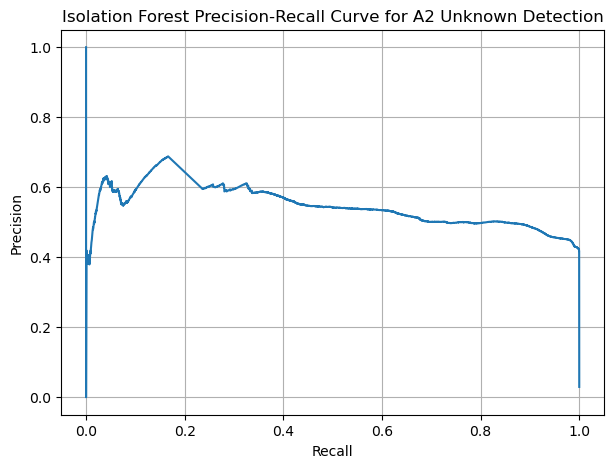

In [159]:
# Cell C3A-10B: Precision-recall curve for Isolation Forest unknown detection
# Purpose:
# - Satisfy the Strategy 3 proposal requirement
# - Evaluate whether the one-class anomaly score separates A2 unknown attacks from known samples

from sklearn.metrics import precision_recall_curve, average_precision_score

# Higher score should mean more anomalous / more likely unknown.
iforest_unknown_score = -iforest.decision_function(X_test_iforest_dense)
iforest_unknown_score_series = pd.Series(
    iforest_unknown_score,
    index=c3a_a2_detail_df.index
)

y_a2_unknown = c3a_a2_detail_df["is_unknown"].astype(int).to_numpy()
a2_unknown_scores = iforest_unknown_score_series.loc[c3a_a2_detail_df.index].to_numpy()

iforest_precision, iforest_recall, iforest_pr_thresholds = precision_recall_curve(
    y_a2_unknown,
    a2_unknown_scores
)

c3a_iforest_average_precision = average_precision_score(
    y_a2_unknown,
    a2_unknown_scores
)

c3a_iforest_pr_summary_df = pd.DataFrame([{
    "scenario": "A2_common_attack_classes",
    "unknown_detector_score": "Isolation Forest anomaly score",
    "known_samples": int((y_a2_unknown == 0).sum()),
    "unknown_samples": int((y_a2_unknown == 1).sum()),
    "average_precision": c3a_iforest_average_precision
}])

display(c3a_iforest_pr_summary_df.round(4))

plt.figure(figsize=(7, 5))
plt.plot(iforest_recall, iforest_precision)
plt.title("Isolation Forest Precision-Recall Curve for A2 Unknown Detection")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


### C3A Ablation Study: Strategy Contribution Analysis

This short ablation compares three variants on Scenario A2:

1. **Threshold only**
2. **Isolation Forest only**
3. **Threshold + Isolation Forest**

The goal is to verify whether the two strategy components are complementary rather than simply reporting the final combined result.


In [160]:
# Cell C3A-11: Ablation study for C3A open-set handling on Scenario A2
# Purpose:
# - Compare three variants:
#   1. Threshold only
#   2. Isolation Forest only
#   3. Threshold + Isolation Forest
# - This shows whether the two strategies are complementary

c3a_threshold = 0.90

a2_known_mask = ~c3a_a2_detail_df["is_unknown"]
a2_unknown_mask = c3a_a2_detail_df["is_unknown"]

# Variant 1: threshold only
threshold_flags_unknown = c3a_a2_detail_df["confidence"] < c3a_threshold

# Variant 2: Isolation Forest fallback only
# It only flags samples predicted as Benign and judged anomalous by Isolation Forest.
a2_pred_benign_mask = c3a_a2_detail_df["predicted_known_class"] == "Benign"
iforest_flags_unknown = pd.Series(False, index=c3a_a2_detail_df.index)
iforest_flags_unknown.loc[a2_pred_benign_mask] = (
    iforest_test_is_anomaly_series.loc[a2_pred_benign_mask].values
)

# Variant 3: combined strategy
combined_flags_unknown = threshold_flags_unknown | iforest_flags_unknown

ablation_rows = []

strategy_flags = {
    "Threshold only": threshold_flags_unknown,
    "Isolation Forest only": iforest_flags_unknown,
    "Threshold + Isolation Forest": combined_flags_unknown
}

for strategy_name, flags_unknown in strategy_flags.items():
    ablation_rows.append({
        "strategy": strategy_name,
        "unknown_detection_rate": flags_unknown[a2_unknown_mask].mean(),
        "known_false_rejection_rate": flags_unknown[a2_known_mask].mean(),
        "coverage": 1 - flags_unknown.mean(),
        "unknown_detected_samples": int(flags_unknown[a2_unknown_mask].sum()),
        "known_false_rejected_samples": int(flags_unknown[a2_known_mask].sum())
    })

c3a_a2_ablation_df = pd.DataFrame(ablation_rows).round(4)
display(c3a_a2_ablation_df)


,strategy,unknown_detection_rate,known_false_rejection_rate,coverage,unknown_detected_samples,known_false_rejected_samples
0,Threshold only,0.5061,0.0063,0.9789,7128,2940
1,Isolation Forest only,0.4945,0.0196,0.9664,6964,9093
2,Threshold + Isolation Forest,0.8453,0.0246,0.9512,11905,11432


#### C3A Checkpoint: Open-Set Handling Strategies

**Mini report.**  
Component 3A evaluated two strategies for handling open-set failures. Confidence thresholding worked well for A1, rejecting `85.58%` of unknown samples at threshold `0.90`, but it was weaker for A2, rejecting only `50.61%` of unknown samples because many A2 unknown attacks had high confidence. The threshold sweep also reports coverage and accepted known-class accuracy, which shows the practical cost of rejection.

Isolation Forest was then added as a one-class anomaly fallback trained only on `Benign` traffic. It introduced a low Benign false positive rate (`1.95%`) while flagging most attack traffic as anomalous (`92.44%`). For the most dangerous A2 case, where unknown attacks were predicted as `Benign`, Isolation Forest caught `91.51%` of those samples. The precision-recall curve evaluates the same anomaly score as an unknown-attack detector.

The ablation study showed that the two strategies are complementary. On A2, thresholding alone detected `50.61%` of unknown samples, Isolation Forest alone detected `49.45%`, and the combined strategy detected `84.53%`. The combined strategy increased known-class false rejection to `2.46%`, but this trade-off may be acceptable in security settings where missed attacks are costly.

**Why it matters.**  
Standard classifiers force unknown attacks into known classes. C3A shows that a rejection layer plus a Benign-only anomaly fallback can reduce this open-set failure. Thresholding catches low-confidence unknowns, while Isolation Forest helps catch high-confidence unknown attacks that are incorrectly classified as `Benign`.


## Component 2B: Cross-Dataset Distribution Shift

This section evaluates whether the selected UNSW-trained model can generalize to CICIDS2018 without retraining. This is a source-only cross-dataset stress test.

Because UNSW and CICIDS2018 use different attack names, this section uses binary detection:

- `Benign` = normal traffic
- `Attack` = any non-Benign traffic

No adaptation, retraining, few-shot calibration, or cost-sensitive update is applied in Component 2B. The goal is to measure the failure caused by distribution shift.

### C2B-0 Source-Only Cross-Dataset Evaluation

This module evaluates the selected UNSW-trained baseline model directly on CICIDS2018 without retraining. The purpose is to measure how much performance changes when the test data comes from a different network environment.

The first step is to load a manageable CICIDS2018 sample and verify its structure before applying the UNSW preprocessing and model.

In [161]:
# Cell C2B-1: Load CICIDS2018 sample and inspect basic structure
# Purpose:
# - Load a manageable CICIDS2018 sample first
# - Check columns, dtypes, and attack distribution
# - Prepare for source-only cross-dataset evaluation

cic_path = r"C:\Users\Administrator\Desktop\archive\NF-CSE-CIC-IDS2018-v2.csv"

cic_raw = pd.read_csv(cic_path, nrows=100_000)

print("CICIDS2018 sample shape:", cic_raw.shape)

print("\nFirst five rows:")
display(cic_raw.head())

print("\nCICIDS2018 columns and dtypes:")
display(pd.DataFrame({
    "column": cic_raw.columns,
    "dtype": cic_raw.dtypes.astype(str).values
}))

print("\nCICIDS2018 Attack distribution:")
display(cic_raw["Attack"].value_counts().to_frame("samples"))

print("\nCICIDS2018 binary label distribution:")
display(
    (cic_raw["Attack"] != "Benign")
    .map({False: "Benign", True: "Attack"})
    .value_counts()
    .to_frame("samples")
)

CICIDS2018 sample shape: (100000, 45)

First five rows:


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,13.58.98.64,40894,172.31.69.25,22,6,92.0,3164,23,3765,21,...,26883,26847,0,0,0,0,0,0,1,SSH-Bruteforce
1,213.202.230.143,29622,172.31.66.103,3389,6,0.0,1919,14,2031,11,...,8192,64000,0,0,0,0,0,0,0,Benign
2,172.31.66.5,65456,172.31.0.2,53,17,0.0,116,2,148,2,...,0,0,0,0,2511,1,5,0,0,Benign
3,172.31.64.92,57918,172.31.0.2,53,17,0.0,70,1,130,1,...,0,0,0,0,3371,1,60,0,0,Benign
4,18.219.32.43,63269,172.31.69.25,80,6,7.0,232,5,1136,4,...,8192,26883,0,0,0,0,0,0,1,DDoS attacks-LOIC-HTTP



CICIDS2018 columns and dtypes:


,column,dtype
0,IPV4_SRC_ADDR,object
1,L4_SRC_PORT,int64
2,IPV4_DST_ADDR,object
3,L4_DST_PORT,int64
4,PROTOCOL,int64
5,L7_PROTO,float64
6,IN_BYTES,int64
7,IN_PKTS,int64
8,OUT_BYTES,int64
9,OUT_PKTS,int64



CICIDS2018 Attack distribution:


,samples
Attack,
Benign,88044
DDOS attack-HOIC,5693
DoS attacks-Hulk,2307
DDoS attacks-LOIC-HTTP,1561
Bot,797
Infilteration,651
SSH-Bruteforce,504
DoS attacks-GoldenEye,139
FTP-BruteForce,132



CICIDS2018 binary label distribution:


,samples
Attack,
Benign,88044
Attack,11956


### C2B-1 Column Compatibility Audit

Before applying the UNSW-trained preprocessing pipeline to CICIDS2018, the two datasets must be checked for feature compatibility. This step verifies whether CICIDS2018 contains the same raw NetFlow columns as UNSW and identifies any missing or extra columns.

In [162]:
# Cell C2B-2: Audit CICIDS2018 column compatibility with UNSW
# Purpose:
# - Verify that CICIDS2018 and UNSW share the same raw columns
# - Identify missing or extra columns before preprocessing
# - Confirm that model feature columns can be constructed consistently

unsw_columns = set(raw_df.columns)
cic_columns = set(cic_raw.columns)

missing_in_cic = sorted(list(unsw_columns - cic_columns))
extra_in_cic = sorted(list(cic_columns - unsw_columns))

print("Number of UNSW columns:", len(raw_df.columns))
print("Number of CICIDS2018 columns:", len(cic_raw.columns))

print("\nColumns missing in CICIDS2018:")
print(missing_in_cic if missing_in_cic else "None")

print("\nExtra columns in CICIDS2018:")
print(extra_in_cic if extra_in_cic else "None")

# Compare dtypes for shared columns
shared_columns = [col for col in raw_df.columns if col in cic_raw.columns]

dtype_compare_df = pd.DataFrame({
    "column": shared_columns,
    "UNSW_dtype": [str(raw_df[col].dtype) for col in shared_columns],
    "CIC_dtype": [str(cic_raw[col].dtype) for col in shared_columns]
})

dtype_mismatch_df = dtype_compare_df[
    dtype_compare_df["UNSW_dtype"] != dtype_compare_df["CIC_dtype"]
]

print("\nColumns with dtype differences:")
if dtype_mismatch_df.empty:
    print("None")
else:
    display(dtype_mismatch_df)

print("\nFeature columns expected by Component 1:")
print("Raw X columns:", len(X_raw.columns))
print("Categorical columns:", categorical_feature_cols)
print("Numeric columns:", len(numeric_feature_cols))

Number of UNSW columns: 45
Number of CICIDS2018 columns: 45

Columns missing in CICIDS2018:
None

Extra columns in CICIDS2018:
None

Columns with dtype differences:


,column,UNSW_dtype,CIC_dtype
42,FTP_COMMAND_RET_CODE,float64,int64



Feature columns expected by Component 1:
Raw X columns: 41
Categorical columns: ['PROTOCOL', 'L7_PROTO']
Numeric columns: 39


### C2B-2 Source-Domain Preprocessing on CICIDS2018

CICIDS2018 has the same raw NetFlow columns as UNSW, so the CIC sample can be converted into the same raw feature structure used by Component 1. In this source-only stress test, CICIDS2018 is not used to fit any preprocessing step. The UNSW-fitted preprocessing pipeline is applied directly to CICIDS2018.

In [163]:
# Cell C2B-3: Prepare CICIDS2018 binary labels and raw features
# Purpose:
# - Convert CIC labels to binary detection labels
# - Build CIC raw feature matrix using the same feature columns as UNSW
# - Do not fit any preprocessing on CIC

# Binary label:
# Benign = 0
# Attack = 1
y_cic_binary = (cic_raw["Attack"] != "Benign").astype(int).to_numpy()

# Drop the same non-feature columns used in Component 1
X_cic_raw = cic_raw.drop(columns=drop_from_features).copy()

# Reorder CIC raw features to match UNSW raw feature order
X_cic_raw = X_cic_raw[X_raw.columns]

print("CIC raw feature shape:", X_cic_raw.shape)
print("UNSW raw feature shape:", X_raw.shape)

print("\nColumn alignment correct:")
print(list(X_cic_raw.columns) == list(X_raw.columns))

print("\nCIC binary label distribution:")
display(
    pd.Series(y_cic_binary)
    .map({0: "Benign", 1: "Attack"})
    .value_counts()
    .to_frame("samples")
)

CIC raw feature shape: (100000, 41)
UNSW raw feature shape: (2390275, 41)

Column alignment correct:
True

CIC binary label distribution:


,samples
Benign,88044
Attack,11956


In [164]:
# Cell C2B-4: Transform CICIDS2018 using UNSW-fitted preprocessing pipeline
# Purpose:
# - Apply the Component 1 preprocessing pipeline to CIC
# - Do not fit preprocessing on CIC
# - Keep this as a source-only distribution-shift test

X_cic_processed = baseline_preprocessor.transform(X_cic_raw)

print("CIC processed feature shape:", X_cic_processed.shape)
print("UNSW processed train shape:", X_train_processed.shape)

print("\nProcessed feature alignment correct:")
print(X_cic_processed.shape[1] == X_train_processed.shape[1])

print("\nReady for source-only prediction.")

CIC processed feature shape: (100000, 375)
UNSW processed train shape: (1673192, 375)

Processed feature alignment correct:
True

Ready for source-only prediction.


In [165]:
# Cell C2B-5: Source-only UNSW model prediction on CICIDS2018
# Purpose:
# - Use the selected Component 1 XGBoost model directly on CIC
# - Convert UNSW multi-class predictions into binary Benign vs Attack
# - No retraining or adaptation is applied

# Multi-class prediction using the UNSW-trained selected model
y_cic_pred_encoded = selected_baseline_model.predict(X_cic_processed).astype(int)

# Convert encoded UNSW labels back to class names
y_cic_pred_names = attack_label_encoder.inverse_transform(y_cic_pred_encoded)

# Binary conversion:
# predicted Benign = 0
# predicted any attack class = 1
y_cic_pred_binary = (y_cic_pred_names != "Benign").astype(int)

cic_prediction_detail_df = pd.DataFrame({
    "true_attack": cic_raw["Attack"].values,
    "true_binary": y_cic_binary,
    "predicted_unsw_class": y_cic_pred_names,
    "predicted_binary": y_cic_pred_binary
})

print("CIC source-only predictions generated.")

print("\nTrue binary distribution:")
display(
    pd.Series(y_cic_binary)
    .map({0: "Benign", 1: "Attack"})
    .value_counts()
    .to_frame("samples")
)

print("\nPredicted binary distribution:")
display(
    pd.Series(y_cic_pred_binary)
    .map({0: "Benign", 1: "Attack"})
    .value_counts()
    .to_frame("samples")
)

print("\nPredicted UNSW class distribution:")
display(
    cic_prediction_detail_df["predicted_unsw_class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percent")
)

CIC source-only predictions generated.

True binary distribution:


,samples
Benign,88044
Attack,11956



Predicted binary distribution:


,samples
Benign,79913
Attack,20087



Predicted UNSW class distribution:


,percent
predicted_unsw_class,
Benign,79.91
Exploits,19.28
DoS,0.75
Fuzzers,0.03
Generic,0.02


In [166]:
# Cell C2B-6: Evaluate source-only binary performance on CICIDS2018
# Purpose:
# - Evaluate Benign vs Attack performance on CIC
# - Focus on recall, FPR, and FNR under cross-dataset shift

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(
    y_cic_binary,
    y_cic_pred_binary,
    labels=[0, 1]
).ravel()

cic_source_only_metrics = {
    "accuracy": accuracy_score(y_cic_binary, y_cic_pred_binary),
    "precision": precision_score(y_cic_binary, y_cic_pred_binary, zero_division=0),
    "recall": recall_score(y_cic_binary, y_cic_pred_binary, zero_division=0),
    "f1": f1_score(y_cic_binary, y_cic_pred_binary, zero_division=0),
    "fpr": fp / (fp + tn) if (fp + tn) else 0,
    "fnr": fn / (fn + tp) if (fn + tp) else 0,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

cic_source_only_metrics_df = pd.DataFrame(
    [cic_source_only_metrics],
    index=["CIC_source_only_UNSW_XGBoost"]
)

display(cic_source_only_metrics_df.round(4))

,accuracy,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
CIC_source_only_UNSW_XGBoost,0.6812,0.004,0.0067,0.005,0.2272,0.9933,68037,20007,11876,80


### C2B-3 Per-Attack Failure Analysis

The overall binary metrics show severe cross-dataset failure. This step breaks the result down by CICIDS2018 attack type to identify which attacks were missed and how they were mapped into the UNSW label space.

In [167]:
# Cell C2B-7: Analyze source-only failure by CICIDS2018 attack type
# Purpose:
# - Check which CIC attack types are detected or missed
# - Identify which UNSW class each CIC attack is mapped to most often

attack_only_detail_df = cic_prediction_detail_df[
    cic_prediction_detail_df["true_attack"] != "Benign"
].copy()

cic_attack_failure_rows = []

for attack_name, group_df in attack_only_detail_df.groupby("true_attack"):
    pred_binary_counts = group_df["predicted_binary"].value_counts(normalize=True)
    pred_unsw_counts = group_df["predicted_unsw_class"].value_counts(normalize=True)
    
    cic_attack_failure_rows.append({
        "cic_attack": attack_name,
        "samples": len(group_df),
        "detected_as_attack_rate": pred_binary_counts.get(1, 0),
        "missed_as_benign_rate": pred_binary_counts.get(0, 0),
        "most_common_predicted_unsw_class": pred_unsw_counts.idxmax(),
        "most_common_mapping_percent": pred_unsw_counts.max() * 100
    })

cic_attack_failure_df = (
    pd.DataFrame(cic_attack_failure_rows)
    .sort_values(by="samples", ascending=False)
    .round(4)
)

display(cic_attack_failure_df)

,cic_attack,samples,detected_as_attack_rate,missed_as_benign_rate,most_common_predicted_unsw_class,most_common_mapping_percent
3,DDOS attack-HOIC,5693,0.0000,1.0000,Benign,100.0000
7,DoS attacks-Hulk,2307,0.0000,1.0000,Benign,100.0000
5,DDoS attacks-LOIC-HTTP,1561,0.0000,1.0000,Benign,100.0000
0,Bot,797,0.0000,1.0000,Benign,100.0000
11,Infilteration,651,0.1214,0.8786,Benign,87.8648
13,SSH-Bruteforce,504,0.0000,1.0000,Benign,100.0000
6,DoS attacks-GoldenEye,139,0.0000,1.0000,Benign,100.0000
10,FTP-BruteForce,132,0.0000,1.0000,Benign,100.0000
8,DoS attacks-SlowHTTPTest,86,0.0000,1.0000,Benign,100.0000
9,DoS attacks-Slowloris,64,0.0000,1.0000,Benign,100.0000


### C2B-4 Feature Distribution Shift Audit

The source-only model failed severely on CICIDS2018 attacks. This step compares feature distributions between UNSW training data and the CICIDS2018 sample to identify possible causes of the cross-dataset failure.

In [168]:
# Cell C2B-8: Audit feature distribution shift between UNSW train and CIC sample
# Purpose:
# - Compare raw feature distributions across source and target domains
# - Include proposal-required mean and variance
# - Keep robust statistics such as median, IQR, and zero percentage for interpretation

shift_rows = []

for feature in X_raw.columns:
    if feature not in X_cic_raw.columns:
        continue
    
    if feature in categorical_feature_cols:
        continue
    
    unsw_values = pd.to_numeric(X_train_raw[feature], errors="coerce")
    cic_values = pd.to_numeric(X_cic_raw[feature], errors="coerce")
    
    unsw_q1 = unsw_values.quantile(0.25)
    unsw_median = unsw_values.quantile(0.50)
    unsw_q3 = unsw_values.quantile(0.75)
    unsw_iqr = unsw_q3 - unsw_q1
    
    cic_q1 = cic_values.quantile(0.25)
    cic_median = cic_values.quantile(0.50)
    cic_q3 = cic_values.quantile(0.75)
    cic_iqr = cic_q3 - cic_q1
    
    unsw_zero_pct = (unsw_values == 0).mean() * 100
    cic_zero_pct = (cic_values == 0).mean() * 100
    
    shift_rows.append({
        "feature": feature,
        "UNSW_mean": unsw_values.mean(),
        "CIC_mean": cic_values.mean(),
        "UNSW_variance": unsw_values.var(),
        "CIC_variance": cic_values.var(),
        "UNSW_median": unsw_median,
        "CIC_median": cic_median,
        "median_gap": abs(cic_median - unsw_median),
        "UNSW_IQR": unsw_iqr,
        "CIC_IQR": cic_iqr,
        "IQR_ratio_CIC_over_UNSW": (cic_iqr + 1) / (unsw_iqr + 1),
        "UNSW_zero_%": unsw_zero_pct,
        "CIC_zero_%": cic_zero_pct,
        "zero_gap_%": abs(cic_zero_pct - unsw_zero_pct)
    })

feature_shift_df = pd.DataFrame(shift_rows)

feature_shift_df["shift_score"] = (
    feature_shift_df["median_gap"].rank(pct=True) +
    feature_shift_df["zero_gap_%"].rank(pct=True) +
    abs(np.log(feature_shift_df["IQR_ratio_CIC_over_UNSW"])).rank(pct=True)
)

feature_shift_df = feature_shift_df.sort_values(
    by="shift_score",
    ascending=False
).round(4)

display(feature_shift_df.head(20))


,feature,UNSW_mean,CIC_mean,UNSW_variance,CIC_variance,UNSW_median,CIC_median,median_gap,UNSW_IQR,CIC_IQR,IQR_ratio_CIC_over_UNSW,UNSW_zero_%,CIC_zero_%,zero_gap_%,shift_score
33,ICMP_TYPE,1.894623e+04,3.263046e+03,4.149630e+08,1.455542e+08,11008.0,0.0,11008.0,33792.0,0.00,0.0000,29.1548,92.193,63.0382,2.8205
22,RETRANSMITTED_OUT_BYTES,1.724905e+04,4.691330e+01,6.074569e+09,2.855435e+06,871.0,0.0,871.0,6013.0,0.00,0.0002,28.5829,95.929,67.3461,2.6795
20,RETRANSMITTED_IN_BYTES,1.609954e+03,3.995170e+01,9.679825e+08,8.341357e+04,506.0,0.0,506.0,563.0,0.00,0.0018,29.1637,92.270,63.1063,2.5769
34,ICMP_IPV4_TYPE,7.400840e+01,1.274630e+01,6.331796e+03,2.220981e+03,43.0,0.0,43.0,132.0,0.00,0.0075,29.1551,92.193,63.0379,2.3590
12,MIN_TTL,3.899910e+01,7.152880e+01,1.684967e+03,3.237334e+03,31.0,100.0,69.0,0.0,128.00,129.0000,0.5023,36.304,35.8017,2.3205
13,MAX_TTL,3.983240e+01,7.164170e+01,1.681087e+03,3.249573e+03,32.0,101.0,69.0,0.0,128.00,129.0000,0.5023,36.304,35.8017,2.3205
23,RETRANSMITTED_OUT_PKTS,1.620880e+01,1.139000e-01,3.002923e+03,3.237900e+00,4.0,0.0,4.0,13.0,0.00,0.0714,28.5829,95.929,67.3461,2.0641
32,TCP_WIN_MAX_OUT,1.221849e+04,2.100830e+04,1.204615e+08,6.283203e+08,13032.0,8192.0,4840.0,8688.0,29200.00,3.3607,23.5234,47.115,23.5916,1.9744
25,DST_TO_SRC_AVG_THROUGHPUT,9.805706e+07,1.397611e+07,5.631129e+16,8.988691e+15,13824000.0,1464000.0,12360000.0,99232000.0,13008000.00,0.1311,2.2177,6.164,3.9463,1.9744
35,DNS_QUERY_ID,4.956761e+03,1.337697e+04,1.901836e+08,4.050191e+08,0.0,0.0,0.0,0.0,25374.25,25375.2500,84.4834,59.206,25.2774,1.8846


In [169]:
# Cell C2B-9: Audit categorical feature shift between UNSW and CICIDS2018
# Purpose:
# - Compare PROTOCOL and L7_PROTO distributions across UNSW and CIC
# - These categorical features are one-hot encoded in the baseline preprocessor

for col in categorical_feature_cols:
    print(f"\nTop values for {col} in UNSW train:")
    unsw_cat_dist = (
        X_train_raw[col]
        .value_counts(normalize=True)
        .head(10)
        .mul(100)
        .round(2)
        .to_frame("UNSW_percent")
    )
    display(unsw_cat_dist)

    print(f"\nTop values for {col} in CICIDS2018 sample:")
    cic_cat_dist = (
        X_cic_raw[col]
        .value_counts(normalize=True)
        .head(10)
        .mul(100)
        .round(2)
        .to_frame("CIC_percent")
    )
    display(cic_cat_dist)


Top values for PROTOCOL in UNSW train:


,UNSW_percent
PROTOCOL,
6,76.59
17,22.79
1,0.07
89,0.06
2,0.00
47,0.00
41,0.00
103,0.00
53,0.00



Top values for PROTOCOL in CICIDS2018 sample:


,CIC_percent
PROTOCOL,
6,58.57
17,41.32
1,0.11
2,0.01
58,0.00



Top values for L7_PROTO in UNSW train:


,UNSW_percent
L7_PROTO,
0.0,63.58
1.0,19.95
7.0,8.77
3.0,3.29
92.0,2.03
4.0,2.02
17.0,0.09
13.0,0.06
41.0,0.05



Top values for L7_PROTO in CICIDS2018 sample:


,CIC_percent
L7_PROTO,
0.000,58.69
7.000,13.60
5.126,6.95
41.000,2.71
91.126,2.27
91.178,2.26
5.178,1.53
5.119,1.08
5.240,0.98


In [170]:
# Cell C2B-10: Component 2B checkpoint tables
# Purpose:
# - Save source-only cross-dataset metrics
# - Report proposal-required relative F1 degradation
# - Save attack-level failure table and top feature-shift evidence

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    y_cic_binary,
    y_cic_pred_binary,
    labels=[0, 1]
).ravel()

total = tn + fp + fn + tp

c2b_accuracy = (tn + tp) / total
c2b_precision = tp / (tp + fp) if (tp + fp) else 0
c2b_recall = tp / (tp + fn) if (tp + fn) else 0
c2b_f1 = (
    2 * c2b_precision * c2b_recall / (c2b_precision + c2b_recall)
    if (c2b_precision + c2b_recall)
    else 0
)
c2b_fpr = fp / (fp + tn) if (fp + tn) else 0
c2b_fnr = fn / (fn + tp) if (fn + tp) else 0

c2b_final_metrics_df = pd.DataFrame([{
    "scenario": "C2B_source_only_cross_dataset",
    "train_dataset": "NF-UNSW-NB15-v2",
    "test_dataset": "NF-CSE-CIC-IDS2018-v2 sample",
    "model": "UNSW-trained XGBoost",
    "accuracy": c2b_accuracy,
    "precision": c2b_precision,
    "recall": c2b_recall,
    "f1": c2b_f1,
    "fpr": c2b_fpr,
    "fnr": c2b_fnr,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}])

# In-domain binary performance of the selected UNSW model
source_test_true_binary = (pd.Series(y_test_text).to_numpy() != "Benign").astype(int)
source_test_pred_names = attack_label_encoder.inverse_transform(y_test_pred.astype(int))
source_test_pred_binary = (source_test_pred_names != "Benign").astype(int)

source_binary_f1 = f1_score(
    source_test_true_binary,
    source_test_pred_binary,
    zero_division=0
)

c2b_relative_degradation_df = pd.DataFrame([{
    "source_domain": "UNSW test",
    "target_domain": "CICIDS2018 sample",
    "source_binary_f1": source_binary_f1,
    "target_binary_f1": c2b_f1,
    "delta_f1_target_minus_source": c2b_f1 - source_binary_f1,
    "relative_f1_drop": (
        (source_binary_f1 - c2b_f1) / source_binary_f1
        if source_binary_f1 else np.nan
    )
}])

c2b_attack_failure_df = (
    cic_prediction_detail_df[cic_prediction_detail_df["true_attack"] != "Benign"]
    .groupby("true_attack")
    .agg(
        samples=("true_attack", "size"),
        detected_as_attack_rate=("predicted_binary", "mean")
    )
    .reset_index()
)

c2b_attack_failure_df["missed_as_benign_rate"] = (
    1 - c2b_attack_failure_df["detected_as_attack_rate"]
)

c2b_attack_failure_df = c2b_attack_failure_df.sort_values(
    by="samples",
    ascending=False
)

c2b_top_shift_features_df = feature_shift_df.head(10).copy()

display(c2b_final_metrics_df.round(4))
display(c2b_relative_degradation_df.round(4))
display(c2b_attack_failure_df.round(4))
display(c2b_top_shift_features_df.round(4))


,scenario,train_dataset,test_dataset,model,accuracy,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,C2B_source_only_cross_dataset,NF-UNSW-NB15-v2,NF-CSE-CIC-IDS2018-v2 sample,UNSW-trained XGBoost,0.6812,0.004,0.0067,0.005,0.2272,0.9933,68037,20007,11876,80


,source_domain,target_domain,source_binary_f1,target_binary_f1,delta_f1_target_minus_source,relative_f1_drop
0,UNSW test,CICIDS2018 sample,0.9643,0.005,-0.9593,0.9948


,true_attack,samples,detected_as_attack_rate,missed_as_benign_rate
3,DDOS attack-HOIC,5693,0.0000,1.0000
7,DoS attacks-Hulk,2307,0.0000,1.0000
5,DDoS attacks-LOIC-HTTP,1561,0.0000,1.0000
0,Bot,797,0.0000,1.0000
11,Infilteration,651,0.1214,0.8786
13,SSH-Bruteforce,504,0.0000,1.0000
6,DoS attacks-GoldenEye,139,0.0000,1.0000
10,FTP-BruteForce,132,0.0000,1.0000
8,DoS attacks-SlowHTTPTest,86,0.0000,1.0000
9,DoS attacks-Slowloris,64,0.0000,1.0000


,feature,UNSW_mean,CIC_mean,UNSW_variance,CIC_variance,UNSW_median,CIC_median,median_gap,UNSW_IQR,CIC_IQR,IQR_ratio_CIC_over_UNSW,UNSW_zero_%,CIC_zero_%,zero_gap_%,shift_score
33,ICMP_TYPE,1.894623e+04,3.263046e+03,4.149630e+08,1.455542e+08,11008.0,0.0,11008.0,33792.0,0.00,0.0000,29.1548,92.193,63.0382,2.8205
22,RETRANSMITTED_OUT_BYTES,1.724905e+04,4.691330e+01,6.074569e+09,2.855435e+06,871.0,0.0,871.0,6013.0,0.00,0.0002,28.5829,95.929,67.3461,2.6795
20,RETRANSMITTED_IN_BYTES,1.609954e+03,3.995170e+01,9.679825e+08,8.341357e+04,506.0,0.0,506.0,563.0,0.00,0.0018,29.1637,92.270,63.1063,2.5769
34,ICMP_IPV4_TYPE,7.400840e+01,1.274630e+01,6.331796e+03,2.220981e+03,43.0,0.0,43.0,132.0,0.00,0.0075,29.1551,92.193,63.0379,2.3590
12,MIN_TTL,3.899910e+01,7.152880e+01,1.684967e+03,3.237334e+03,31.0,100.0,69.0,0.0,128.00,129.0000,0.5023,36.304,35.8017,2.3205
13,MAX_TTL,3.983240e+01,7.164170e+01,1.681087e+03,3.249573e+03,32.0,101.0,69.0,0.0,128.00,129.0000,0.5023,36.304,35.8017,2.3205
23,RETRANSMITTED_OUT_PKTS,1.620880e+01,1.139000e-01,3.002923e+03,3.237900e+00,4.0,0.0,4.0,13.0,0.00,0.0714,28.5829,95.929,67.3461,2.0641
32,TCP_WIN_MAX_OUT,1.221849e+04,2.100830e+04,1.204615e+08,6.283203e+08,13032.0,8192.0,4840.0,8688.0,29200.00,3.3607,23.5234,47.115,23.5916,1.9744
25,DST_TO_SRC_AVG_THROUGHPUT,9.805706e+07,1.397611e+07,5.631129e+16,8.988691e+15,13824000.0,1464000.0,12360000.0,99232000.0,13008000.00,0.1311,2.2177,6.164,3.9463,1.9744
35,DNS_QUERY_ID,4.956761e+03,1.337697e+04,1.901836e+08,4.050191e+08,0.0,0.0,0.0,0.0,25374.25,25375.2500,84.4834,59.206,25.2774,1.8846


### C2B Checkpoint: Source-Only Cross-Dataset Failure

Component 2B tests whether the UNSW-trained XGBoost model can transfer directly to CICIDS2018 without retraining.

Using a 100,000-row working subset of CICIDS2018, the source-only model achieved 0.6812 accuracy, but only 0.0067 attack recall and 0.0050 F1. In practical terms, only 80 out of 11,956 CIC attack samples were detected. The relative-degradation table compares this target-domain binary F1 against the in-domain UNSW binary F1, satisfying the proposal requirement to quantify cross-dataset degradation.

The attack-level breakdown shows that most major CICIDS2018 attack categories were almost completely classified as Benign. HOIC, Hulk, LOIC-HTTP, Bot, SSH-Bruteforce, GoldenEye, FTP-BruteForce, SlowHTTPTest, and Slowloris had near-zero detection under direct transfer.

The feature audit suggests that this failure is caused by distribution shift rather than column mismatch. Although UNSW and CICIDS2018 share the same raw columns, several ICMP, retransmission, TTL, throughput, and DNS-related features have very different means, variances, medians, IQRs, and zero-value rates.

The CICIDS2018 file is large, so this notebook uses a 100,000-row working sample for computational feasibility. This should be reported as an experimental limitation unless the full CICIDS2018 subset is evaluated later.

Therefore, Component 2B demonstrates that high in-domain performance on UNSW does not guarantee robustness under cross-dataset distribution shift.


## Component 3B: Improving Cross-Dataset Distribution Shift

Component 2B showed that the UNSW-trained model failed under cross-dataset distribution shift when tested directly on CICIDS2018.

Component 3B evaluates improvement strategies for this failure. Following the project proposal, this section first tests cost-sensitive learning, because missed attacks are more costly than false alarms in cybersecurity. Then it tests a small target-domain calibration strategy to examine whether a limited number of labeled CICIDS2018 samples can help the model adapt to the shifted data distribution.

The comparison will use Component 2B source-only performance as the baseline.

### C3B-1 Cost-Sensitive Binary Learning

This strategy trains a binary XGBoost detector on UNSW using the original binary `Label` column.

Unlike the Component 1 multi-class model, this model directly learns Benign vs Attack. To reduce missed attacks, the attack class is assigned a higher training weight using `scale_pos_weight`.

This strategy corresponds to the proposal's cost-sensitive learning method.

In [171]:
# Cell C3B-1: Build UNSW binary labels for cost-sensitive learning
# Purpose:
# - Use the original UNSW Label column as binary target
# - Benign = 0, Attack = 1
# - Keep the same train / validation / test split from Component 1

y_train_binary = raw_df.loc[X_train_raw.index, "Label"].astype(int).to_numpy()
y_val_binary = raw_df.loc[X_val_raw.index, "Label"].astype(int).to_numpy()
y_test_binary = raw_df.loc[X_test_raw.index, "Label"].astype(int).to_numpy()

binary_label_summary_df = pd.DataFrame({
    "split": ["Train", "Validation", "Test", "CICIDS2018 sample"],
    "benign_samples": [
        int((y_train_binary == 0).sum()),
        int((y_val_binary == 0).sum()),
        int((y_test_binary == 0).sum()),
        int((y_cic_binary == 0).sum())
    ],
    "attack_samples": [
        int((y_train_binary == 1).sum()),
        int((y_val_binary == 1).sum()),
        int((y_test_binary == 1).sum()),
        int((y_cic_binary == 1).sum())
    ]
})

binary_label_summary_df["attack_ratio"] = (
    binary_label_summary_df["attack_samples"] /
    (binary_label_summary_df["benign_samples"] + binary_label_summary_df["attack_samples"])
)

display(binary_label_summary_df.round(4))

,split,benign_samples,attack_samples,attack_ratio
0,Train,1606655,66537,0.0398
1,Validation,229522,9505,0.0398
2,Test,459045,19011,0.0398
3,CICIDS2018 sample,88044,11956,0.1196


In [172]:
# Cell C3B-2: Train cost-sensitive binary XGBoost on UNSW
# Purpose:
# - Train a binary XGBoost detector using UNSW Benign vs Attack labels
# - Use scale_pos_weight to penalize missed attacks more heavily
# - Keep preprocessing fixed from Component 1

from xgboost import XGBClassifier
import time

negative_count = int((y_train_binary == 0).sum())
positive_count = int((y_train_binary == 1).sum())

scale_pos_weight_c3b = negative_count / positive_count

c3b_cost_sensitive_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_c3b,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

c3b_cost_sensitive_xgb.fit(
    X_train_processed,
    y_train_binary
)

c3b_train_time = time.time() - start_time

c3b_cost_weight_summary_df = pd.DataFrame([{
    "negative_benign_train_samples": negative_count,
    "positive_attack_train_samples": positive_count,
    "scale_pos_weight": scale_pos_weight_c3b,
    "training_time_seconds": c3b_train_time
}])

display(c3b_cost_weight_summary_df.round(4))

,negative_benign_train_samples,positive_attack_train_samples,scale_pos_weight,training_time_seconds
0,1606655,66537,24.1468,5.445


In [173]:
# Cell C3B-3: Evaluate cost-sensitive model on UNSW validation
# Purpose:
# - Check whether cost-sensitive learning still works on the source dataset
# - Compare binary detection quality before testing on CICIDS2018

from sklearn.metrics import confusion_matrix

y_val_cost_pred = c3b_cost_sensitive_xgb.predict(X_val_processed).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val_binary,
    y_val_cost_pred,
    labels=[0, 1]
).ravel()

total = tn + fp + fn + tp

unsw_cost_metrics_df = pd.DataFrame([{
    "scenario": "UNSW_validation_cost_sensitive_binary",
    "accuracy": (tn + tp) / total,
    "precision": tp / (tp + fp) if (tp + fp) else 0,
    "recall": tp / (tp + fn) if (tp + fn) else 0,
    "f1": (
        2 * (tp / (tp + fp)) * (tp / (tp + fn)) /
        ((tp / (tp + fp)) + (tp / (tp + fn)))
        if (tp + fp) and (tp + fn) and ((tp / (tp + fp)) + (tp / (tp + fn))) else 0
    ),
    "fpr": fp / (fp + tn) if (fp + tn) else 0,
    "fnr": fn / (fn + tp) if (fn + tp) else 0,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}])

display(unsw_cost_metrics_df.round(4))

,scenario,accuracy,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,UNSW_validation_cost_sensitive_binary,0.996,0.9078,1.0,0.9517,0.0042,0.0,228557,965,0,9505


In [174]:
# Cell C3B-4: Test cost-sensitive binary model on CICIDS2018
# Purpose:
# - Evaluate whether cost-sensitive learning improves cross-dataset attack detection
# - Compare against the Component 2B source-only baseline

y_cic_cost_pred = c3b_cost_sensitive_xgb.predict(X_cic_processed).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_cic_binary,
    y_cic_cost_pred,
    labels=[0, 1]
).ravel()

total = tn + fp + fn + tp

cic_cost_metrics_df = pd.DataFrame([{
    "scenario": "CIC_cost_sensitive_binary",
    "accuracy": (tn + tp) / total,
    "precision": tp / (tp + fp) if (tp + fp) else 0,
    "recall": tp / (tp + fn) if (tp + fn) else 0,
    "f1": (
        2 * (tp / (tp + fp)) * (tp / (tp + fn)) /
        ((tp / (tp + fp)) + (tp / (tp + fn)))
        if (tp + fp) and (tp + fn) and ((tp / (tp + fp)) + (tp / (tp + fn))) else 0
    ),
    "fpr": fp / (fp + tn) if (fp + tn) else 0,
    "fnr": fn / (fn + tp) if (fn + tp) else 0,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}])

cic_cost_prediction_distribution_df = pd.DataFrame({
    "true_CIC_labels": pd.Series(y_cic_binary)
        .map({0: "Benign", 1: "Attack"})
        .value_counts(),
    "cost_sensitive_predictions": pd.Series(y_cic_cost_pred)
        .map({0: "Benign", 1: "Attack"})
        .value_counts()
}).fillna(0).astype(int)

display(cic_cost_metrics_df.round(4))
display(cic_cost_prediction_distribution_df)

,scenario,accuracy,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,CIC_cost_sensitive_binary,0.6246,0.0861,0.2226,0.1242,0.3208,0.7774,59801,28243,9295,2661


,true_CIC_labels,cost_sensitive_predictions
Benign,88044,69096
Attack,11956,30904


In [175]:
# Cell C3B-5: Attack-level analysis for cost-sensitive model on CICIDS2018
# Purpose:
# - Check which CIC attack types improved under cost-sensitive learning
# - Compare attack recall against the Component 2B source-only model

c3b_cost_detail_df = pd.DataFrame({
    "true_attack": cic_raw["Attack"].values,
    "true_binary": y_cic_binary,
    "source_only_pred": y_cic_pred_binary,
    "cost_sensitive_pred": y_cic_cost_pred
})

attack_only_cost_df = c3b_cost_detail_df[
    c3b_cost_detail_df["true_attack"] != "Benign"
].copy()

c3b_cost_attack_comparison_df = (
    attack_only_cost_df
    .groupby("true_attack")
    .agg(
        samples=("true_attack", "size"),
        source_only_recall=("source_only_pred", "mean"),
        cost_sensitive_recall=("cost_sensitive_pred", "mean")
    )
    .reset_index()
)

c3b_cost_attack_comparison_df["recall_gain"] = (
    c3b_cost_attack_comparison_df["cost_sensitive_recall"] -
    c3b_cost_attack_comparison_df["source_only_recall"]
)

c3b_cost_attack_comparison_df = c3b_cost_attack_comparison_df.sort_values(
    by="samples",
    ascending=False
)

display(c3b_cost_attack_comparison_df.round(4))

,true_attack,samples,source_only_recall,cost_sensitive_recall,recall_gain
3,DDOS attack-HOIC,5693,0.0000,0.0450,0.0450
7,DoS attacks-Hulk,2307,0.0000,0.0009,0.0009
5,DDoS attacks-LOIC-HTTP,1561,0.0000,0.9693,0.9693
0,Bot,797,0.0000,0.9310,0.9310
11,Infilteration,651,0.1214,0.2135,0.0922
13,SSH-Bruteforce,504,0.0000,0.0000,0.0000
6,DoS attacks-GoldenEye,139,0.0000,0.0000,0.0000
10,FTP-BruteForce,132,0.0000,0.0000,0.0000
8,DoS attacks-SlowHTTPTest,86,0.0000,0.0000,0.0000
9,DoS attacks-Slowloris,64,0.0000,0.0000,0.0000


### C3B-1B Cost Weight Trade-off

Strategy 4 requires more than one weighted model. This sweep varies the positive-class cost and reports the trade-off between missed attacks (`FNR`) and false alarms (`FPR`).


,scale_pos_weight,evaluation_data,precision,recall,f1,fpr,fnr,tp,fp,fn,training_time_seconds
0,1.0000,UNSW_validation,0.9516,0.9823,0.9667,0.0021,0.0177,9337,475,168,5.4711
1,1.0000,CICIDS2018_sample,0.0819,0.0730,0.0772,0.1112,0.9270,873,9791,11083,5.4711
2,3.0000,UNSW_validation,0.9176,0.9978,0.9560,0.0037,0.0022,9484,852,21,5.3920
3,3.0000,CICIDS2018_sample,0.0692,0.2011,0.1030,0.3670,0.7989,2404,32312,9552,5.3920
4,5.0000,UNSW_validation,0.9108,0.9996,0.9531,0.0041,0.0004,9501,931,4,5.3988
5,5.0000,CICIDS2018_sample,0.0585,0.2260,0.0929,0.4940,0.7740,2702,43494,9254,5.3988
6,8.0000,UNSW_validation,0.9084,1.0000,0.9520,0.0042,0.0000,9505,959,0,5.3287
7,8.0000,CICIDS2018_sample,0.0698,0.2270,0.1067,0.4110,0.7730,2714,36186,9242,5.3287
8,12.0000,UNSW_validation,0.9082,1.0000,0.9519,0.0042,0.0000,9505,961,0,5.3945
9,12.0000,CICIDS2018_sample,0.0576,0.2245,0.0916,0.4991,0.7755,2684,43939,9272,5.3945


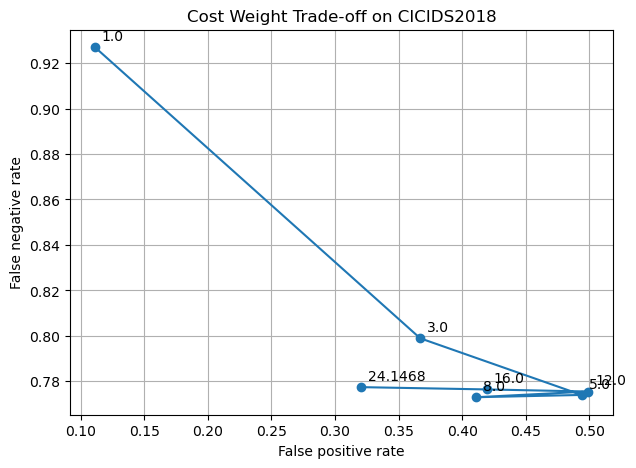

In [176]:
# Cell C3B-5B: Sweep cost weights for binary XGBoost
# Purpose:
# - Evaluate the Strategy 4 FNR/FPR trade-off as cost weight varies
# - Compare source validation behavior with target-domain CIC behavior

c3b_cost_weight_values = [
    1.0,
    3.0,
    5.0,
    8.0,
    12.0,
    16.0,
    round(scale_pos_weight_c3b, 4)
]

c3b_cost_sweep_rows = []

for cost_weight in c3b_cost_weight_values:
    sweep_model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=cost_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    start_time = time.time()
    sweep_model.fit(X_train_processed, y_train_binary)
    sweep_train_time = time.time() - start_time
    
    for eval_name, X_eval, y_eval in [
        ("UNSW_validation", X_val_processed, y_val_binary),
        ("CICIDS2018_sample", X_cic_processed, y_cic_binary)
    ]:
        y_eval_pred = sweep_model.predict(X_eval).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y_eval,
            y_eval_pred,
            labels=[0, 1]
        ).ravel()
        
        c3b_cost_sweep_rows.append({
            "scale_pos_weight": cost_weight,
            "evaluation_data": eval_name,
            "precision": precision_score(y_eval, y_eval_pred, zero_division=0),
            "recall": recall_score(y_eval, y_eval_pred, zero_division=0),
            "f1": f1_score(y_eval, y_eval_pred, zero_division=0),
            "fpr": fp / (fp + tn) if (fp + tn) else 0,
            "fnr": fn / (fn + tp) if (fn + tp) else 0,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "training_time_seconds": sweep_train_time
        })

c3b_cost_sweep_df = pd.DataFrame(c3b_cost_sweep_rows)
display(c3b_cost_sweep_df.round(4))

c3b_cic_cost_sweep_df = c3b_cost_sweep_df[
    c3b_cost_sweep_df["evaluation_data"] == "CICIDS2018_sample"
].copy()

plt.figure(figsize=(7, 5))
plt.plot(
    c3b_cic_cost_sweep_df["fpr"],
    c3b_cic_cost_sweep_df["fnr"],
    marker="o"
)

for _, row in c3b_cic_cost_sweep_df.iterrows():
    plt.annotate(
        str(row["scale_pos_weight"]),
        (row["fpr"], row["fnr"]),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.title("Cost Weight Trade-off on CICIDS2018")
plt.xlabel("False positive rate")
plt.ylabel("False negative rate")
plt.grid(True)
plt.show()


#### C3B-1 Checkpoint: Cost-Sensitive Learning

Cost-sensitive learning improves attack recall under cross-dataset shift, but the improvement is uneven across CICIDS2018 attack types.

Compared with the Component 2B source-only baseline, overall attack recall increased from 0.0067 to 0.2226, and true positives increased from 80 to 2,661. This shows that assigning a higher training cost to the attack class helps the model detect more CICIDS2018 attacks.

However, the improvement comes with a clear trade-off. The false positive rate increased to 0.3208, meaning many benign CICIDS2018 samples were incorrectly flagged as attacks. The cost-weight sweep explicitly evaluates this FNR/FPR trade-off as required by Strategy 4.

The attack-level breakdown shows that the gain is concentrated in selected attack types. DDoS attacks-LOIC-HTTP improved from 0.0000 to 0.9693 recall, Bot improved from 0.0000 to 0.9310, and Infilteration improved from 0.1214 to 0.2135. However, several attacks such as HOIC, Hulk, SSH-Bruteforce, GoldenEye, and FTP-BruteForce remained poorly detected.

Therefore, cost-sensitive learning reduces missed attacks under distribution shift, but it is not sufficient by itself for robust cross-dataset detection.


### C3B-2 Few-Shot Target-Domain Calibration

Cost-sensitive learning improved recall, but many CICIDS2018 attacks were still missed. This suggests that weighting the UNSW source data alone is not enough to handle cross-dataset distribution shift.

This strategy uses a small labeled subset of CICIDS2018 as target-domain calibration data. Based on the 100,000-sample CICIDS2018 subset, the split uses 1,000 Benign samples and up to 50 real samples per attack class for few-shot calibration, while keeping the remaining CICIDS2018 samples as the holdout test set.

This is not a source-only setting anymore. It tests whether limited target-domain labels can help the model adapt to the shifted CICIDS2018 distribution.


In [177]:
# Cell C3B-6: Split CICIDS2018 into few-shot calibration and holdout sets
# Purpose:
# - Select a small labeled CIC subset for target-domain calibration
# - Keep enough CIC samples for holdout evaluation
# - Avoid copying or synthetic oversampling

fewshot_rows = []

benign_fewshot_n = 1000
attack_fewshot_max_n = 50

for attack_name, group_df in cic_raw.groupby("Attack"):
    class_size = len(group_df)

    if attack_name == "Benign":
        n_take = min(benign_fewshot_n, max(class_size - 1, 0))
    else:
        n_take = min(attack_fewshot_max_n, max(class_size - 1, 0))

    if n_take > 0:
        sampled_group = group_df.sample(
            n=n_take,
            random_state=RANDOM_STATE
        )
        fewshot_rows.append(sampled_group)

cic_fewshot_df = pd.concat(fewshot_rows).sort_index()
cic_holdout_df = cic_raw.drop(index=cic_fewshot_df.index).copy()

cic_split_distribution_df = pd.DataFrame({
    "fewshot_samples": cic_fewshot_df["Attack"].value_counts(),
    "holdout_samples": cic_holdout_df["Attack"].value_counts()
}).fillna(0).astype(int)

cic_split_distribution_df["total_samples"] = (
    cic_split_distribution_df["fewshot_samples"] +
    cic_split_distribution_df["holdout_samples"]
)

cic_split_distribution_df = cic_split_distribution_df.sort_values(
    by="total_samples",
    ascending=False
)

display(cic_split_distribution_df)


,fewshot_samples,holdout_samples,total_samples
Attack,,,
Benign,1000,87044,88044
DDOS attack-HOIC,50,5643,5693
DoS attacks-Hulk,50,2257,2307
DDoS attacks-LOIC-HTTP,50,1511,1561
Bot,50,747,797
Infilteration,50,601,651
SSH-Bruteforce,50,454,504
DoS attacks-GoldenEye,50,89,139
FTP-BruteForce,50,82,132


C3B-2 Sampling Rule

The few-shot calibration set was sampled from the 100,000-sample CICIDS2018 subset.

For Benign traffic, 1,000 samples were selected for calibration. For each attack class, up to 50 real samples were selected. No duplicated or synthetic samples were created.

For rare attack classes, the sampling rule kept at least one real sample in the holdout set whenever possible. Therefore, if an attack class had only one sample, it was kept entirely in the holdout set. If an attack class had two samples, one was used for calibration and one was kept for holdout evaluation.

This design allows the model to receive limited target-domain information while preserving a separate CICIDS2018 holdout set for evaluation.

In [178]:
# Cell C3B-7: Preprocess CIC few-shot and holdout sets
# Purpose:
# - Build CIC few-shot and holdout feature matrices
# - Use the UNSW-fitted baseline preprocessor
# - Create binary labels for calibration and holdout evaluation

X_cic_fewshot_raw = cic_fewshot_df.drop(columns=drop_from_features).copy()
X_cic_holdout_raw = cic_holdout_df.drop(columns=drop_from_features).copy()

X_cic_fewshot_raw = X_cic_fewshot_raw[X_raw.columns]
X_cic_holdout_raw = X_cic_holdout_raw[X_raw.columns]

X_cic_fewshot_processed = baseline_preprocessor.transform(X_cic_fewshot_raw)
X_cic_holdout_processed = baseline_preprocessor.transform(X_cic_holdout_raw)

y_cic_fewshot_binary = (cic_fewshot_df["Attack"] != "Benign").astype(int).to_numpy()
y_cic_holdout_binary = (cic_holdout_df["Attack"] != "Benign").astype(int).to_numpy()

fewshot_preprocess_summary_df = pd.DataFrame([{
    "dataset": "CIC_fewshot",
    "samples": X_cic_fewshot_processed.shape[0],
    "features": X_cic_fewshot_processed.shape[1],
    "attack_samples": int((y_cic_fewshot_binary == 1).sum()),
    "benign_samples": int((y_cic_fewshot_binary == 0).sum()),
    "attack_ratio": y_cic_fewshot_binary.mean()
}, {
    "dataset": "CIC_holdout",
    "samples": X_cic_holdout_processed.shape[0],
    "features": X_cic_holdout_processed.shape[1],
    "attack_samples": int((y_cic_holdout_binary == 1).sum()),
    "benign_samples": int((y_cic_holdout_binary == 0).sum()),
    "attack_ratio": y_cic_holdout_binary.mean()
}])

display(fewshot_preprocess_summary_df.round(4))

,dataset,samples,features,attack_samples,benign_samples,attack_ratio
0,CIC_fewshot,1518,375,518,1000,0.3412
1,CIC_holdout,98482,375,11438,87044,0.1161


In [179]:
# Cell C3B-8: Train few-shot target-calibrated binary XGBoost
# Purpose:
# - Combine UNSW training data with the CIC few-shot calibration set
# - Train a binary XGBoost model on source data plus limited target-domain labels
# - Keep CIC holdout fully separate for final evaluation

from scipy.sparse import vstack
from xgboost import XGBClassifier
import time

X_fewshot_train_combined = vstack([
    X_train_processed,
    X_cic_fewshot_processed
])

y_fewshot_train_combined = np.concatenate([
    y_train_binary,
    y_cic_fewshot_binary
])

fewshot_negative_count = int((y_fewshot_train_combined == 0).sum())
fewshot_positive_count = int((y_fewshot_train_combined == 1).sum())

fewshot_scale_pos_weight = fewshot_negative_count / fewshot_positive_count

c3b_fewshot_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=fewshot_scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

c3b_fewshot_xgb.fit(
    X_fewshot_train_combined,
    y_fewshot_train_combined
)

fewshot_train_time = time.time() - start_time

fewshot_training_summary_df = pd.DataFrame([{
    "training_source": "UNSW_train + CIC_fewshot",
    "train_samples": X_fewshot_train_combined.shape[0],
    "features": X_fewshot_train_combined.shape[1],
    "benign_samples": fewshot_negative_count,
    "attack_samples": fewshot_positive_count,
    "scale_pos_weight": fewshot_scale_pos_weight,
    "training_time_seconds": fewshot_train_time
}])

display(fewshot_training_summary_df.round(4))

,training_source,train_samples,features,benign_samples,attack_samples,scale_pos_weight,training_time_seconds
0,UNSW_train + CIC_fewshot,1674710,375,1607655,67055,23.9752,5.9093


In [180]:
# Cell C3B-9: Evaluate few-shot calibrated model on CIC holdout
# Purpose:
# - Test the few-shot calibrated model on CIC holdout data
# - Compare with source-only and cost-sensitive results
# - Keep holdout samples completely unseen during training

y_cic_holdout_fewshot_pred = c3b_fewshot_xgb.predict(
    X_cic_holdout_processed
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_cic_holdout_binary,
    y_cic_holdout_fewshot_pred,
    labels=[0, 1]
).ravel()

total = tn + fp + fn + tp

cic_fewshot_metrics_df = pd.DataFrame([{
    "scenario": "CIC_fewshot_calibrated_holdout",
    "accuracy": (tn + tp) / total,
    "precision": tp / (tp + fp) if (tp + fp) else 0,
    "recall": tp / (tp + fn) if (tp + fn) else 0,
    "f1": (
        2 * (tp / (tp + fp)) * (tp / (tp + fn)) /
        ((tp / (tp + fp)) + (tp / (tp + fn)))
        if (tp + fp) and (tp + fn) and ((tp / (tp + fp)) + (tp / (tp + fn))) else 0
    ),
    "fpr": fp / (fp + tn) if (fp + tn) else 0,
    "fnr": fn / (fn + tp) if (fn + tp) else 0,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}])

fewshot_prediction_distribution_df = pd.DataFrame({
    "true_CIC_holdout_labels": pd.Series(y_cic_holdout_binary)
        .map({0: "Benign", 1: "Attack"})
        .value_counts(),
    "fewshot_predictions": pd.Series(y_cic_holdout_fewshot_pred)
        .map({0: "Benign", 1: "Attack"})
        .value_counts()
}).fillna(0).astype(int)

display(cic_fewshot_metrics_df.round(4))
display(fewshot_prediction_distribution_df)

,scenario,accuracy,precision,recall,f1,fpr,fnr,tn,fp,fn,tp
0,CIC_fewshot_calibrated_holdout,0.9093,0.5643,0.9615,0.7112,0.0975,0.0385,78553,8491,440,10998


,true_CIC_holdout_labels,fewshot_predictions
Benign,87044,78993
Attack,11438,19489


In [181]:
# Cell C3B-10: Attack-level analysis for few-shot calibrated model
# Purpose:
# - Check which CIC attack types are detected after few-shot calibration
# - Compare few-shot recall with source-only and cost-sensitive recall

c3b_fewshot_detail_df = pd.DataFrame({
    "true_attack": cic_holdout_df["Attack"].values,
    "true_binary": y_cic_holdout_binary,
    "fewshot_pred": y_cic_holdout_fewshot_pred
})

fewshot_attack_only_df = c3b_fewshot_detail_df[
    c3b_fewshot_detail_df["true_attack"] != "Benign"
].copy()

c3b_fewshot_attack_df = (
    fewshot_attack_only_df
    .groupby("true_attack")
    .agg(
        holdout_samples=("true_attack", "size"),
        fewshot_recall=("fewshot_pred", "mean")
    )
    .reset_index()
)

# Add source-only and cost-sensitive recall from the full CIC sample
comparison_reference_df = c3b_cost_attack_comparison_df[
    ["true_attack", "source_only_recall", "cost_sensitive_recall"]
].copy()

c3b_fewshot_attack_comparison_df = c3b_fewshot_attack_df.merge(
    comparison_reference_df,
    on="true_attack",
    how="left"
)

c3b_fewshot_attack_comparison_df["fewshot_gain_over_source"] = (
    c3b_fewshot_attack_comparison_df["fewshot_recall"] -
    c3b_fewshot_attack_comparison_df["source_only_recall"]
)

c3b_fewshot_attack_comparison_df["fewshot_gain_over_cost_sensitive"] = (
    c3b_fewshot_attack_comparison_df["fewshot_recall"] -
    c3b_fewshot_attack_comparison_df["cost_sensitive_recall"]
)

c3b_fewshot_attack_comparison_df = c3b_fewshot_attack_comparison_df.sort_values(
    by="holdout_samples",
    ascending=False
)

display(c3b_fewshot_attack_comparison_df.round(4))

,true_attack,holdout_samples,fewshot_recall,source_only_recall,cost_sensitive_recall,fewshot_gain_over_source,fewshot_gain_over_cost_sensitive
3,DDOS attack-HOIC,5643,1.0000,0.0000,0.0450,1.0000,0.9550
7,DoS attacks-Hulk,2257,0.9991,0.0000,0.0009,0.9991,0.9982
5,DDoS attacks-LOIC-HTTP,1511,0.9682,0.0000,0.9693,0.9682,-0.0010
0,Bot,747,1.0000,0.0000,0.9310,1.0000,0.0690
11,Infilteration,601,0.3527,0.1214,0.2135,0.2314,0.1392
13,SSH-Bruteforce,454,0.9978,0.0000,0.0000,0.9978,0.9978
6,DoS attacks-GoldenEye,89,1.0000,0.0000,0.0000,1.0000,1.0000
10,FTP-BruteForce,82,1.0000,0.0000,0.0000,1.0000,1.0000
8,DoS attacks-SlowHTTPTest,36,1.0000,0.0000,0.0000,1.0000,1.0000
9,DoS attacks-Slowloris,14,1.0000,0.0000,0.0000,1.0000,1.0000


C3B-2 Checkpoint: Few-Shot Target-Domain Calibration

Few-shot target-domain calibration substantially improved cross-dataset performance.

Compared with the Component 2B source-only baseline, attack recall increased from 0.0067 to 0.9615, and F1 increased from 0.0050 to 0.7112 on the CICIDS2018 holdout set. Compared with cost-sensitive learning, few-shot calibration also reduced the false positive rate from 0.3208 to 0.0975.

The attack-level analysis shows that the improvement is broad across most major CICIDS2018 attack categories. HOIC, Hulk, Bot, SSH-Bruteforce, GoldenEye, FTP-BruteForce, SlowHTTPTest, and Slowloris were detected with near-perfect recall after adding a small number of CICIDS2018 calibration samples.

However, Infilteration remained difficult. Its recall improved from 0.1214 under source-only transfer to 0.3527 after few-shot calibration, but it was still much lower than the recall for volumetric or brute-force attacks. This suggests that Infilteration may be more similar to benign traffic in the available NetFlow features.

Rare attack classes with only one holdout sample are reported for completeness, but they should not be over-interpreted.

Overall, few-shot target-domain calibration was the most effective Component 3B strategy because it directly addressed the distribution mismatch between UNSW and CICIDS2018.

### C3B-3 Strategy Comparison and Ablation

This final step compares the Component 2B source-only baseline with the two Component 3B improvement strategies.

The comparison includes:

- Source-only UNSW XGBoost: trained only on UNSW and tested directly on CICIDS2018.
- Cost-sensitive binary XGBoost: trained only on UNSW, but with higher cost assigned to attack samples.
- Few-shot target-domain calibration: trained on UNSW plus a small labeled CICIDS2018 calibration set, then evaluated on the remaining CICIDS2018 holdout set.

This comparison serves as the ablation study for Component 3B. It shows what is gained by adding cost-sensitive learning and what is gained by adding limited target-domain calibration.

In [182]:
# Cell C3B-11: Final Component 3B strategy comparison
# Purpose:
# - Compare source-only, cost-sensitive, and few-shot calibrated strategies
# - Summarize the trade-off between recall, F1, and false positive rate
# - Support the Component 3B ablation discussion

c3b_strategy_comparison_df = pd.DataFrame([
    {
        "strategy": "Source-only UNSW XGBoost",
        "training_data": "UNSW only",
        "test_data": "CICIDS2018 sample",
        "accuracy": c2b_final_metrics_df.loc[0, "accuracy"],
        "precision": c2b_final_metrics_df.loc[0, "precision"],
        "recall": c2b_final_metrics_df.loc[0, "recall"],
        "f1": c2b_final_metrics_df.loc[0, "f1"],
        "fpr": c2b_final_metrics_df.loc[0, "fpr"],
        "fnr": c2b_final_metrics_df.loc[0, "fnr"],
        "tp": c2b_final_metrics_df.loc[0, "tp"],
        "fp": c2b_final_metrics_df.loc[0, "fp"],
        "fn": c2b_final_metrics_df.loc[0, "fn"]
    },
    {
        "strategy": "Cost-sensitive binary XGBoost",
        "training_data": "UNSW only with attack weighting",
        "test_data": "CICIDS2018 sample",
        "accuracy": cic_cost_metrics_df.loc[0, "accuracy"],
        "precision": cic_cost_metrics_df.loc[0, "precision"],
        "recall": cic_cost_metrics_df.loc[0, "recall"],
        "f1": cic_cost_metrics_df.loc[0, "f1"],
        "fpr": cic_cost_metrics_df.loc[0, "fpr"],
        "fnr": cic_cost_metrics_df.loc[0, "fnr"],
        "tp": cic_cost_metrics_df.loc[0, "tp"],
        "fp": cic_cost_metrics_df.loc[0, "fp"],
        "fn": cic_cost_metrics_df.loc[0, "fn"]
    },
    {
        "strategy": "Few-shot target calibration",
        "training_data": "UNSW + CIC few-shot",
        "test_data": "CICIDS2018 holdout",
        "accuracy": cic_fewshot_metrics_df.loc[0, "accuracy"],
        "precision": cic_fewshot_metrics_df.loc[0, "precision"],
        "recall": cic_fewshot_metrics_df.loc[0, "recall"],
        "f1": cic_fewshot_metrics_df.loc[0, "f1"],
        "fpr": cic_fewshot_metrics_df.loc[0, "fpr"],
        "fnr": cic_fewshot_metrics_df.loc[0, "fnr"],
        "tp": cic_fewshot_metrics_df.loc[0, "tp"],
        "fp": cic_fewshot_metrics_df.loc[0, "fp"],
        "fn": cic_fewshot_metrics_df.loc[0, "fn"]
    }
])

display(c3b_strategy_comparison_df.round(4))

,strategy,training_data,test_data,accuracy,precision,recall,f1,fpr,fnr,tp,fp,fn
0,Source-only UNSW XGBoost,UNSW only,CICIDS2018 sample,0.6812,0.0040,0.0067,0.0050,0.2272,0.9933,80,20007,11876
1,Cost-sensitive binary XGBoost,UNSW only with attack weighting,CICIDS2018 sample,0.6246,0.0861,0.2226,0.1242,0.3208,0.7774,2661,28243,9295
2,Few-shot target calibration,UNSW + CIC few-shot,CICIDS2018 holdout,0.9093,0.5643,0.9615,0.7112,0.0975,0.0385,10998,8491,440


C3B Final Checkpoint: Strategy Comparison

The Component 3B ablation shows that the two improvement strategies had very different effects.

The source-only UNSW XGBoost model failed under cross-dataset distribution shift, with only 0.0067 attack recall and 0.0050 F1 on CICIDS2018.

Cost-sensitive learning improved attack recall from 0.0067 to 0.2226, showing that assigning higher cost to attack samples helped reduce missed attacks. However, this strategy also increased the false positive rate to 0.3208 and still missed most CICIDS2018 attacks.

Few-shot target-domain calibration achieved the strongest result. With a small CICIDS2018 calibration set, recall increased to 0.9615 and F1 increased to 0.7112 on the CICIDS2018 holdout set. It also reduced the false positive rate to 0.0975 compared with the cost-sensitive model.

Overall, cost-sensitive learning partially improved cross-dataset robustness, but limited target-domain calibration was much more effective because it directly exposed the model to the shifted CICIDS2018 data distribution.

### Component B Summary

Stress Test B evaluated cross-dataset distribution shift by training on UNSW and testing on CICIDS2018.

Component 2B showed that the source-only UNSW-trained model failed severely on CICIDS2018. Although the raw columns were aligned, the model detected only 80 out of 11,956 CIC attack samples, showing that column compatibility does not guarantee distribution compatibility.

Component 3B evaluated two improvement strategies. Cost-sensitive learning increased attack recall but introduced many false positives. Few-shot target-domain calibration achieved the strongest improvement by adding a small labeled CIC calibration set while keeping the remaining CIC data as holdout.

This supports the conclusion that cross-dataset robustness requires target-domain adaptation, not only source-domain reweighting.

## Component 2C: Feature Degradation Stress Test

Component 2C tests whether the selected UNSW XGBoost baseline remains reliable when input features are corrupted at test time. The proposal requires three independent degradation conditions: Gaussian noise, random masking, and feature dropout.


### C2C-1 Degradation Design and Clean Baseline

This section defines the exact degradation levels and evaluates the clean test set before corruption. All degradation is applied only to the test features; the classifier is not retrained in Component 2C.


In [183]:
# Cell C2C-1: Degradation design and clean baseline
# Purpose:
# - Evaluate clean baseline performance on UNSW test data
# - Define proposal-required feature degradation conditions

from sklearn.metrics import accuracy_score, f1_score
from scipy import sparse
import gc

y_test_clean_pred = selected_baseline_model.predict(X_test_processed).astype(int)

c2c_clean_baseline_df = pd.DataFrame([{
    "condition": "clean_test_features",
    "accuracy": accuracy_score(y_test, y_test_clean_pred),
    "macro_f1": f1_score(y_test, y_test_clean_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_test_clean_pred, average="weighted")
}])

c2c_noise_sigmas = [0.1, 0.5, 1.0]
c2c_masking_ratios = [0.10, 0.25, 0.50]
c2c_dropout_feature_counts = [2, 4, 6]
c2c_repeats = 5

c2c_degradation_design_df = pd.DataFrame([
    {
        "degradation_type": "gaussian_noise",
        "levels": str(c2c_noise_sigmas),
        "proposal_requirement": "sigma in {0.1, 0.5, 1.0}"
    },
    {
        "degradation_type": "random_masking",
        "levels": str(c2c_masking_ratios),
        "proposal_requirement": "p in {10%, 25%, 50%}"
    },
    {
        "degradation_type": "feature_dropout",
        "levels": str(c2c_dropout_feature_counts),
        "proposal_requirement": "k in {2, 4, 6}"
    }
])

display(c2c_clean_baseline_df.round(4))
display(c2c_degradation_design_df)


,condition,accuracy,macro_f1,weighted_f1
0,clean_test_features,0.9894,0.6501,0.9897


,degradation_type,levels,proposal_requirement
0,gaussian_noise,"[0.1, 0.5, 1.0]","sigma in {0.1, 0.5, 1.0}"
1,random_masking,"[0.1, 0.25, 0.5]","p in {10%, 25%, 50%}"
2,feature_dropout,"[2, 4, 6]","k in {2, 4, 6}"


### C2C-2 Degradation Utilities

The helper code below keeps the three stress conditions consistent. Gaussian noise is applied to processed numeric features, random masking zeros a random fraction of processed features, and feature dropout zeros all processed columns belonging to selected raw features.


In [184]:
# Cell C2C-2: Build degradation helper functions
# Purpose:
# - Keep Gaussian noise, random masking, and feature dropout reproducible
# - Aggregate repeated runs as mean and standard deviation

def processed_name_to_raw_feature(processed_name):
    if processed_name.startswith("log_numeric__"):
        return processed_name.replace("log_numeric__", "", 1)
    if processed_name.startswith("regular_numeric__"):
        return processed_name.replace("regular_numeric__", "", 1)
    if processed_name.startswith("categorical__PROTOCOL_"):
        return "PROTOCOL"
    if processed_name.startswith("categorical__L7_PROTO_"):
        return "L7_PROTO"
    return processed_name


processed_feature_to_raw_feature = {
    idx: processed_name_to_raw_feature(name)
    for idx, name in enumerate(baseline_feature_names)
}

raw_feature_to_processed_indices = {}
for idx, raw_feature in processed_feature_to_raw_feature.items():
    raw_feature_to_processed_indices.setdefault(raw_feature, []).append(idx)

numeric_processed_indices = np.array([
    idx for idx, name in enumerate(baseline_feature_names)
    if name.startswith("log_numeric__") or name.startswith("regular_numeric__")
])

dropout_candidate_features = sorted(raw_feature_to_processed_indices.keys())


def evaluate_multiclass_prediction(model, X_eval):
    y_pred = model.predict(X_eval).astype(int)
    
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted")
    }


def make_random_masked_matrix(X_source, mask_ratio, seed):
    rng = np.random.default_rng(seed)
    total_features = X_source.shape[1]
    masked_feature_count = int(total_features * mask_ratio)
    
    X_degraded = X_source.copy().tolil() if sparse.issparse(X_source) else X_source.copy()
    
    if masked_feature_count > 0:
        masked_indices = rng.choice(
            total_features,
            size=masked_feature_count,
            replace=False
        )
        X_degraded[:, masked_indices] = 0
    
    if sparse.issparse(X_degraded):
        X_degraded = X_degraded.tocsr()
    
    return X_degraded, masked_feature_count


def make_feature_dropout_matrix(X_source, dropped_raw_features):
    drop_indices = []
    
    for raw_feature in dropped_raw_features:
        drop_indices.extend(raw_feature_to_processed_indices[raw_feature])
    
    X_degraded = X_source.copy().tolil() if sparse.issparse(X_source) else X_source.copy()
    X_degraded[:, drop_indices] = 0
    
    if sparse.issparse(X_degraded):
        X_degraded = X_degraded.tocsr()
    
    return X_degraded, len(drop_indices)


def make_gaussian_noise_matrix(X_source, sigma, seed):
    rng = np.random.default_rng(seed)
    
    X_degraded = (
        X_source.toarray().astype(np.float32, copy=False)
        if sparse.issparse(X_source)
        else X_source.copy().astype(np.float32, copy=False)
    )
    
    noise = rng.normal(
        loc=0.0,
        scale=sigma,
        size=(X_degraded.shape[0], len(numeric_processed_indices))
    ).astype(np.float32)
    
    X_degraded[:, numeric_processed_indices] += noise
    
    del noise
    gc.collect()
    
    return X_degraded


def summarize_degradation_rows(rows):
    detailed_df = pd.DataFrame(rows)
    
    summary_df = (
        detailed_df
        .groupby(["model", "degradation_type", "level"], as_index=False)
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            weighted_f1_mean=("weighted_f1", "mean"),
            weighted_f1_std=("weighted_f1", "std")
        )
    )
    
    return detailed_df, summary_df


print("Degradation helper functions are ready.")
print("Processed features:", X_test_processed.shape[1])
print("Raw feature groups for dropout:", len(dropout_candidate_features))
print("Numeric processed features for Gaussian noise:", len(numeric_processed_indices))


Degradation helper functions are ready.
Processed features: 375
Raw feature groups for dropout: 41
Numeric processed features for Gaussian noise: 39


### C2C-3 Baseline Under Proposal Degradation Conditions

The selected baseline model is evaluated under Gaussian noise, random masking, and feature dropout. Each degraded condition is repeated with fixed seeds and summarized with mean and standard deviation.


In [185]:
# Cell C2C-3: Evaluate baseline under Gaussian noise, random masking, and feature dropout
# Purpose:
# - Run all proposal-required Stress Test C conditions
# - Keep degradation independent from training

def run_degradation_suite(model, model_name, repeats=c2c_repeats):
    rows = []
    
    # Clean condition
    clean_metrics = evaluate_multiclass_prediction(model, X_test_processed)
    rows.append({
        "model": model_name,
        "degradation_type": "clean",
        "level": "clean",
        "repeat_id": 0,
        **clean_metrics
    })
    
    # Gaussian noise
    for sigma in c2c_noise_sigmas:
        for repeat_id in range(repeats):
            X_degraded = make_gaussian_noise_matrix(
                X_test_processed,
                sigma=sigma,
                seed=RANDOM_STATE + 1000 + repeat_id
            )
            metrics = evaluate_multiclass_prediction(model, X_degraded)
            rows.append({
                "model": model_name,
                "degradation_type": "gaussian_noise",
                "level": f"sigma={sigma}",
                "repeat_id": repeat_id,
                **metrics
            })
            del X_degraded
            gc.collect()
    
    # Random masking
    for mask_ratio in c2c_masking_ratios:
        for repeat_id in range(repeats):
            X_degraded, masked_feature_count = make_random_masked_matrix(
                X_test_processed,
                mask_ratio=mask_ratio,
                seed=RANDOM_STATE + 2000 + repeat_id
            )
            metrics = evaluate_multiclass_prediction(model, X_degraded)
            rows.append({
                "model": model_name,
                "degradation_type": "random_masking",
                "level": f"p={mask_ratio}",
                "repeat_id": repeat_id,
                "masked_processed_features": masked_feature_count,
                **metrics
            })
            del X_degraded
            gc.collect()
    
    # Feature dropout
    for feature_count in c2c_dropout_feature_counts:
        for repeat_id in range(repeats):
            rng = np.random.default_rng(RANDOM_STATE + 3000 + repeat_id)
            dropped_features = rng.choice(
                dropout_candidate_features,
                size=feature_count,
                replace=False
            ).tolist()
            
            X_degraded, dropped_processed_count = make_feature_dropout_matrix(
                X_test_processed,
                dropped_features
            )
            metrics = evaluate_multiclass_prediction(model, X_degraded)
            rows.append({
                "model": model_name,
                "degradation_type": "feature_dropout",
                "level": f"k={feature_count}",
                "repeat_id": repeat_id,
                "dropped_raw_features": ", ".join(dropped_features),
                "dropped_processed_features": dropped_processed_count,
                **metrics
            })
            del X_degraded
            gc.collect()
    
    return summarize_degradation_rows(rows)


c2c_degradation_detail_df, c2c_degradation_summary_df = run_degradation_suite(
    selected_baseline_model,
    "baseline"
)

display(c2c_degradation_summary_df.round(4))


,model,degradation_type,level,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,baseline,clean,clean,0.9894,NaN,0.6501,NaN,0.9897,NaN
1,baseline,feature_dropout,k=2,0.9867,0.0020,0.5966,0.0256,0.9872,0.0012
2,baseline,feature_dropout,k=4,0.9789,0.0090,0.4622,0.1546,0.9783,0.0116
3,baseline,feature_dropout,k=6,0.9761,0.0105,0.3839,0.1974,0.9722,0.0167
4,baseline,gaussian_noise,sigma=0.1,0.9513,0.0002,0.1835,0.0017,0.9557,0.0002
5,baseline,gaussian_noise,sigma=0.5,0.8661,0.0008,0.1300,0.0007,0.9070,0.0005
6,baseline,gaussian_noise,sigma=1.0,0.7021,0.0006,0.1039,0.0008,0.8059,0.0004
7,baseline,random_masking,p=0.1,0.9825,0.0067,0.5436,0.0793,0.9804,0.0107
8,baseline,random_masking,p=0.25,0.7917,0.2552,0.3189,0.1109,0.8504,0.1726
9,baseline,random_masking,p=0.5,0.9615,0.0026,0.1469,0.0487,0.9484,0.0037


### C2C-4 Feature Dropout Importance

The proposal asks which features cause the largest performance drop when removed. This cell drops one raw feature group at a time and ranks features by macro-F1 loss.


In [186]:
# Cell C2C-4: Identify single-feature dropout impact
# Purpose:
# - Drop one raw feature group at a time
# - Rank features by clean-to-drop macro F1 loss

clean_macro_f1 = c2c_clean_baseline_df.loc[0, "macro_f1"]
single_feature_dropout_rows = []

for raw_feature in dropout_candidate_features:
    X_degraded, dropped_processed_count = make_feature_dropout_matrix(
        X_test_processed,
        [raw_feature]
    )
    
    metrics = evaluate_multiclass_prediction(
        selected_baseline_model,
        X_degraded
    )
    
    single_feature_dropout_rows.append({
        "dropped_raw_feature": raw_feature,
        "dropped_processed_features": dropped_processed_count,
        "macro_f1_after_dropout": metrics["macro_f1"],
        "macro_f1_drop": clean_macro_f1 - metrics["macro_f1"],
        "accuracy_after_dropout": metrics["accuracy"],
        "weighted_f1_after_dropout": metrics["weighted_f1"]
    })
    
    del X_degraded
    gc.collect()

c2c_single_feature_dropout_df = (
    pd.DataFrame(single_feature_dropout_rows)
    .sort_values(by="macro_f1_drop", ascending=False)
)

display(c2c_single_feature_dropout_df.head(15).round(4))


,dropped_raw_feature,dropped_processed_features,macro_f1_after_dropout,macro_f1_drop,accuracy_after_dropout,weighted_f1_after_dropout
14,L4_DST_PORT,1,0.2057,0.4444,0.9680,0.9662
21,MIN_TTL,1,0.4769,0.1733,0.6625,0.7857
39,TCP_WIN_MAX_IN,1,0.5368,0.1133,0.9776,0.9730
17,LONGEST_FLOW_PKT,1,0.5585,0.0917,0.9882,0.9885
20,MIN_IP_PKT_LEN,1,0.5601,0.0900,0.9887,0.9877
30,RETRANSMITTED_IN_BYTES,1,0.5659,0.0842,0.9890,0.9895
10,ICMP_IPV4_TYPE,1,0.5786,0.0715,0.9887,0.9880
12,IN_BYTES,1,0.5809,0.0692,0.9857,0.9849
19,MAX_TTL,1,0.5953,0.0548,0.9891,0.9887
5,DST_TO_SRC_SECOND_BYTES,1,0.5979,0.0522,0.9855,0.9852


### C2C-5 Baseline Degradation Curves

These plots show whether degradation is graceful or catastrophic for each corruption type.


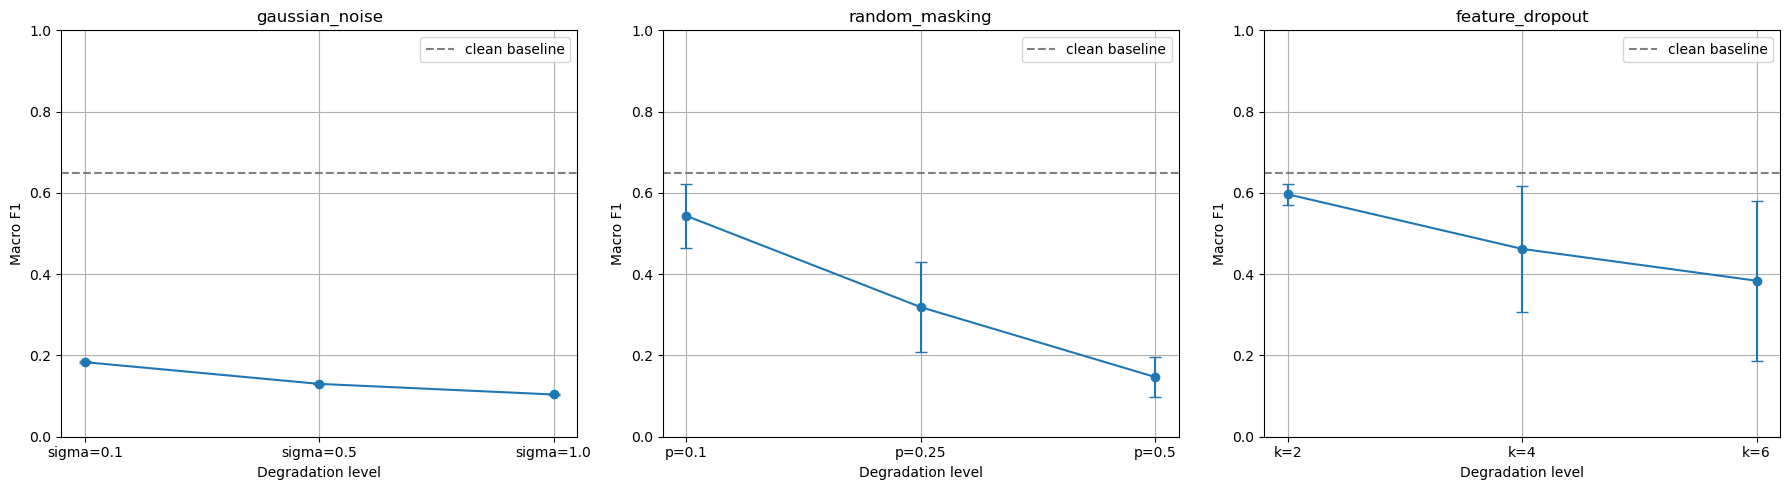

In [187]:
# Cell C2C-5: Plot baseline degradation curves
# Purpose:
# - Visualize macro-F1 degradation for Gaussian noise, masking, and feature dropout

plot_df = c2c_degradation_summary_df[
    c2c_degradation_summary_df["degradation_type"] != "clean"
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, degradation_type in zip(
    axes,
    ["gaussian_noise", "random_masking", "feature_dropout"]
):
    subset = plot_df[plot_df["degradation_type"] == degradation_type].copy()
    
    ax.errorbar(
        subset["level"],
        subset["macro_f1_mean"],
        yerr=subset["macro_f1_std"].fillna(0),
        marker="o",
        capsize=4
    )
    ax.axhline(
        c2c_clean_baseline_df.loc[0, "macro_f1"],
        linestyle="--",
        color="gray",
        label="clean baseline"
    )
    ax.set_title(degradation_type)
    ax.set_xlabel("Degradation level")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


C2C Checkpoint: Baseline Sensitivity to Feature Degradation

Component 2C now follows the full proposal design. The baseline is tested under Gaussian noise, random feature masking, and feature dropout. Results are summarized by macro F1 at each degradation level, with repeated runs reported as mean and standard deviation.

The single-feature dropout table identifies which raw feature groups cause the largest macro-F1 loss when removed. This acts as an implicit feature-importance analysis under feature degradation.

Accuracy and weighted F1 should be interpreted carefully because the dataset is dominated by `Benign` traffic. Macro F1 is the main metric for Stress Test C because it better reflects minority-class degradation.


## Component 3C: Feature Robustness via Augmentation

Component 3C implements Strategy 5 from the proposal. The training set is augmented with synthetically corrupted samples, then the augmented classifier is tested again under the same Stress Test C degradation conditions.


### C3C-1 Augmentation Design

The augmentation variants cover the proposal mechanisms: Gaussian noise, random zeroing, and mixing corrupted samples with the original clean training set.


In [188]:
# Cell C3C-1: Define augmentation design
# Purpose:
# - Document augmentation variants and sample sizes
# - Keep the augmentation setup explicit before training

c3c_augmentation_design_df = pd.DataFrame([
    {
        "variant": "random_zeroing",
        "augmented_samples": 200_000,
        "gaussian_noise": "No",
        "zeroing_ratio": 0.25,
        "notes": "Proposal random zeroing at the middle masking level"
    },
    {
        "variant": "gaussian_noise",
        "augmented_samples": 200_000,
        "gaussian_noise": "sigma sampled uniformly from 0.1 to 1.0",
        "zeroing_ratio": 0.00,
        "notes": "Proposal Gaussian noise"
    },
    {
        "variant": "combined_noise_zeroing",
        "augmented_samples": 200_000,
        "gaussian_noise": "sigma sampled uniformly from 0.1 to 1.0",
        "zeroing_ratio": 0.25,
        "notes": "Gaussian noise plus random zeroing"
    },
    {
        "variant": "multi_ratio_zeroing",
        "augmented_samples": 300_000,
        "gaussian_noise": "No",
        "zeroing_ratio": "0.10, 0.25, 0.50",
        "notes": "Ablation-style ratio variation"
    }
])

display(c3c_augmentation_design_df)


,variant,augmented_samples,gaussian_noise,zeroing_ratio,notes
0,random_zeroing,200000,No,0.25,Proposal random zeroing at the middle masking ...
1,gaussian_noise,200000,sigma sampled uniformly from 0.1 to 1.0,0.0,Proposal Gaussian noise
2,combined_noise_zeroing,200000,sigma sampled uniformly from 0.1 to 1.0,0.25,Gaussian noise plus random zeroing
3,multi_ratio_zeroing,300000,No,"0.10, 0.25, 0.50",Ablation-style ratio variation


### C3C-2 Train Augmented Models

Each augmented model mixes clean UNSW training samples with a corrupted subset. Hyperparameters stay aligned with the selected XGBoost baseline so that the comparison isolates the effect of augmentation.


In [189]:
# Cell C3C-2: Train augmentation variants
# Purpose:
# - Train augmented XGBoost models using proposal-style corrupted samples
# - Mix each augmented subset with the original clean training set

import time
from xgboost import XGBClassifier


def train_multiclass_xgb_on_augmented_data(model_name, augmented_parts, augmented_labels):
    X_train_variant = sparse.vstack([
        X_train_processed,
        *augmented_parts
    ])
    
    y_train_variant = np.concatenate([
        y_train,
        *augmented_labels
    ])
    
    model = XGBClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    )
    
    start_time = time.time()
    model.fit(X_train_variant, y_train_variant)
    training_time = time.time() - start_time
    
    summary = {
        "model": model_name,
        "clean_train_samples": X_train_processed.shape[0],
        "augmented_samples": X_train_variant.shape[0] - X_train_processed.shape[0],
        "total_train_samples": X_train_variant.shape[0],
        "processed_features": X_train_variant.shape[1],
        "training_time_seconds": training_time
    }
    
    del X_train_variant, y_train_variant
    gc.collect()
    
    return model, summary


def make_zeroing_augmented_part(row_indices, zero_ratio, seed):
    rng = np.random.default_rng(seed)
    X_part = X_train_processed[row_indices].copy()
    y_part = y_train[row_indices].copy()
    
    zero_count = int(X_train_processed.shape[1] * zero_ratio)
    zero_indices = rng.choice(
        X_train_processed.shape[1],
        size=zero_count,
        replace=False
    )
    
    X_part = X_part.tolil() if sparse.issparse(X_part) else X_part
    X_part[:, zero_indices] = 0
    
    if sparse.issparse(X_part):
        X_part = X_part.tocsr()
    
    return X_part, y_part


def make_gaussian_augmented_part(row_indices, sigma_min, sigma_max, seed, zero_ratio=0.0):
    rng = np.random.default_rng(seed)
    
    X_dense = (
        X_train_processed[row_indices]
        .toarray()
        .astype(np.float32, copy=False)
    )
    
    y_part = y_train[row_indices].copy()
    
    row_sigmas = rng.uniform(
        sigma_min,
        sigma_max,
        size=(len(row_indices), 1)
    ).astype(np.float32)
    
    noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(len(row_indices), len(numeric_processed_indices))
    ).astype(np.float32)
    
    X_dense[:, numeric_processed_indices] += noise * row_sigmas
    
    if zero_ratio > 0:
        zero_count = int(X_train_processed.shape[1] * zero_ratio)
        zero_indices = rng.choice(
            X_train_processed.shape[1],
            size=zero_count,
            replace=False
        )
        X_dense[:, zero_indices] = 0
    
    X_part = sparse.csr_matrix(X_dense)
    
    del X_dense, noise
    gc.collect()
    
    return X_part, y_part


c3c_rng = np.random.default_rng(RANDOM_STATE)
c3c_training_summaries = []

# A. Random zeroing augmentation
zeroing_rows = c3c_rng.choice(
    X_train_processed.shape[0],
    size=200_000,
    replace=False
)
X_zeroing_part, y_zeroing_part = make_zeroing_augmented_part(
    zeroing_rows,
    zero_ratio=0.25,
    seed=RANDOM_STATE + 10
)
c3c_zeroing_xgb, zeroing_summary = train_multiclass_xgb_on_augmented_data(
    "random_zeroing",
    [X_zeroing_part],
    [y_zeroing_part]
)
c3c_training_summaries.append(zeroing_summary)
del X_zeroing_part, y_zeroing_part
gc.collect()

# B. Gaussian noise augmentation
gaussian_rows = c3c_rng.choice(
    X_train_processed.shape[0],
    size=200_000,
    replace=False
)
X_gaussian_part, y_gaussian_part = make_gaussian_augmented_part(
    gaussian_rows,
    sigma_min=0.1,
    sigma_max=1.0,
    seed=RANDOM_STATE + 20
)
c3c_gaussian_xgb, gaussian_summary = train_multiclass_xgb_on_augmented_data(
    "gaussian_noise",
    [X_gaussian_part],
    [y_gaussian_part]
)
c3c_training_summaries.append(gaussian_summary)
del X_gaussian_part, y_gaussian_part
gc.collect()

# C. Combined Gaussian noise + zeroing augmentation
combined_rows = c3c_rng.choice(
    X_train_processed.shape[0],
    size=200_000,
    replace=False
)
X_combined_part, y_combined_part = make_gaussian_augmented_part(
    combined_rows,
    sigma_min=0.1,
    sigma_max=1.0,
    seed=RANDOM_STATE + 30,
    zero_ratio=0.25
)
c3c_combined_xgb, combined_summary = train_multiclass_xgb_on_augmented_data(
    "combined_noise_zeroing",
    [X_combined_part],
    [y_combined_part]
)
c3c_training_summaries.append(combined_summary)
del X_combined_part, y_combined_part
gc.collect()

# D. Multi-ratio zeroing augmentation
multi_ratio_parts = []
multi_ratio_labels = []

for ratio_id, zero_ratio in enumerate([0.10, 0.25, 0.50]):
    ratio_rows = c3c_rng.choice(
        X_train_processed.shape[0],
        size=100_000,
        replace=False
    )
    X_ratio_part, y_ratio_part = make_zeroing_augmented_part(
        ratio_rows,
        zero_ratio=zero_ratio,
        seed=RANDOM_STATE + 40 + ratio_id
    )
    multi_ratio_parts.append(X_ratio_part)
    multi_ratio_labels.append(y_ratio_part)

c3c_multiratio_xgb, multiratio_summary = train_multiclass_xgb_on_augmented_data(
    "multi_ratio_zeroing",
    multi_ratio_parts,
    multi_ratio_labels
)
c3c_training_summaries.append(multiratio_summary)

del multi_ratio_parts, multi_ratio_labels
gc.collect()

c3c_training_summary_df = pd.DataFrame(c3c_training_summaries)
display(c3c_training_summary_df.round(4))

c3c_augmented_models = {
    "random_zeroing": c3c_zeroing_xgb,
    "gaussian_noise": c3c_gaussian_xgb,
    "combined_noise_zeroing": c3c_combined_xgb,
    "multi_ratio_zeroing": c3c_multiratio_xgb
}

c3c_primary_augmented_model_name = "random_zeroing"
c3c_primary_augmented_model = c3c_augmented_models[c3c_primary_augmented_model_name]


,model,clean_train_samples,augmented_samples,total_train_samples,processed_features,training_time_seconds
0,random_zeroing,1673192,200000,1873192,375,92.3201
1,gaussian_noise,1673192,200000,1873192,375,97.5248
2,combined_noise_zeroing,1673192,200000,1873192,375,97.0109
3,multi_ratio_zeroing,1673192,300000,1973192,375,98.3544


### C3C-3 Clean Performance Check

Before claiming robustness improvement, the proposal requires checking whether augmentation hurts clean test performance.


In [190]:
# Cell C3C-3: Clean performance check for augmented models
# Purpose:
# - Verify whether augmentation hurts clean test performance
# - Compare all variants against the original baseline

c3c_clean_rows = [{
    "model": "baseline",
    "accuracy": c2c_clean_baseline_df.loc[0, "accuracy"],
    "macro_f1": c2c_clean_baseline_df.loc[0, "macro_f1"],
    "weighted_f1": c2c_clean_baseline_df.loc[0, "weighted_f1"]
}]

for model_name, model in c3c_augmented_models.items():
    metrics = evaluate_multiclass_prediction(model, X_test_processed)
    c3c_clean_rows.append({
        "model": model_name,
        **metrics
    })

c3c_clean_performance_df = pd.DataFrame(c3c_clean_rows)
display(c3c_clean_performance_df.round(4))


,model,accuracy,macro_f1,weighted_f1
0,baseline,0.9894,0.6501,0.9897
1,random_zeroing,0.9894,0.6446,0.9897
2,gaussian_noise,0.9891,0.6268,0.9895
3,combined_noise_zeroing,0.9893,0.6267,0.9896
4,multi_ratio_zeroing,0.9894,0.6430,0.9895


### C3C-4 Re-Run Full Stress Test C on Augmented Classifier

The primary augmented classifier is evaluated under the same Gaussian noise, random masking, and feature dropout conditions as the original baseline.


In [191]:
# Cell C3C-4: Re-run full Stress Test C on the primary augmented model
# Purpose:
# - Satisfy Strategy 5 by re-running Stress Test C after augmented training
# - Compare the augmented classifier against the original baseline under identical degradation

c3c_primary_detail_df, c3c_primary_summary_df = run_degradation_suite(
    c3c_primary_augmented_model,
    c3c_primary_augmented_model_name
)

display(c3c_primary_summary_df.round(4))


,model,degradation_type,level,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,random_zeroing,clean,clean,0.9894,NaN,0.6446,NaN,0.9897,NaN
1,random_zeroing,feature_dropout,k=2,0.9853,0.0031,0.5741,0.0697,0.9850,0.0037
2,random_zeroing,feature_dropout,k=4,0.9785,0.0099,0.4399,0.1498,0.9783,0.0116
3,random_zeroing,feature_dropout,k=6,0.9749,0.0109,0.3692,0.1865,0.9735,0.0145
4,random_zeroing,gaussian_noise,sigma=0.1,0.9605,0.0001,0.1692,0.0023,0.9595,0.0001
5,random_zeroing,gaussian_noise,sigma=0.5,0.9027,0.0002,0.1250,0.0016,0.9242,0.0001
6,random_zeroing,gaussian_noise,sigma=1.0,0.7551,0.0007,0.1068,0.0013,0.8375,0.0005
7,random_zeroing,random_masking,p=0.1,0.9838,0.0030,0.5689,0.0522,0.9837,0.0036
8,random_zeroing,random_masking,p=0.25,0.8559,0.1395,0.2847,0.0799,0.8984,0.0816
9,random_zeroing,random_masking,p=0.5,0.8045,0.3036,0.1621,0.1345,0.8343,0.2396


### C3C-5 Original vs Augmented Degradation Comparison

This table compares macro-F1 for the original baseline and the primary augmented model under each degradation condition.


In [192]:
# Cell C3C-5: Compare original and augmented models under Stress Test C
# Purpose:
# - Report the proposal-required original vs augmented degradation comparison
# - Calculate macro-F1 gain for the primary augmented classifier

c3c_stress_comparison_df = (
    c2c_degradation_summary_df[[
        "degradation_type",
        "level",
        "macro_f1_mean",
        "weighted_f1_mean"
    ]]
    .rename(columns={
        "macro_f1_mean": "baseline_macro_f1",
        "weighted_f1_mean": "baseline_weighted_f1"
    })
    .merge(
        c3c_primary_summary_df[[
            "degradation_type",
            "level",
            "macro_f1_mean",
            "weighted_f1_mean"
        ]].rename(columns={
            "macro_f1_mean": "augmented_macro_f1",
            "weighted_f1_mean": "augmented_weighted_f1"
        }),
        on=["degradation_type", "level"],
        how="inner"
    )
)

c3c_stress_comparison_df["macro_f1_gain"] = (
    c3c_stress_comparison_df["augmented_macro_f1"] -
    c3c_stress_comparison_df["baseline_macro_f1"]
)

c3c_stress_comparison_df["weighted_f1_gain"] = (
    c3c_stress_comparison_df["augmented_weighted_f1"] -
    c3c_stress_comparison_df["baseline_weighted_f1"]
)

display(c3c_stress_comparison_df.round(4))


,degradation_type,level,baseline_macro_f1,baseline_weighted_f1,augmented_macro_f1,augmented_weighted_f1,macro_f1_gain,weighted_f1_gain
0,clean,clean,0.6501,0.9897,0.6446,0.9897,-0.0055,-0.0000
1,feature_dropout,k=2,0.5966,0.9872,0.5741,0.9850,-0.0225,-0.0022
2,feature_dropout,k=4,0.4622,0.9783,0.4399,0.9783,-0.0223,0.0000
3,feature_dropout,k=6,0.3839,0.9722,0.3692,0.9735,-0.0147,0.0013
4,gaussian_noise,sigma=0.1,0.1835,0.9557,0.1692,0.9595,-0.0143,0.0038
5,gaussian_noise,sigma=0.5,0.1300,0.9070,0.1250,0.9242,-0.0050,0.0172
6,gaussian_noise,sigma=1.0,0.1039,0.8059,0.1068,0.8375,0.0028,0.0316
7,random_masking,p=0.1,0.5436,0.9804,0.5689,0.9837,0.0254,0.0033
8,random_masking,p=0.25,0.3189,0.8504,0.2847,0.8984,-0.0342,0.0480
9,random_masking,p=0.5,0.1469,0.9484,0.1621,0.8343,0.0152,-0.1142


### C3C-6 Augmentation Variant Ablation

This ablation compares augmentation variants under the random-masking condition. It checks whether the robustness gain comes from noise, zeroing, or the augmentation ratio design.


In [ ]:
# Cell C3C-6: Ablation across augmentation variants under random masking
# Purpose:
# - Compare augmentation variants under the masking degradation condition
# - Keep this ablation narrower than the full Stress Test C rerun for runtime control

c3c_variant_masking_rows = []

for model_name, model in c3c_augmented_models.items():
    for mask_ratio in c2c_masking_ratios:
        for repeat_id in range(c2c_repeats):
            X_degraded, masked_feature_count = make_random_masked_matrix(
                X_test_processed,
                mask_ratio=mask_ratio,
                seed=RANDOM_STATE + 5000 + repeat_id
            )
            metrics = evaluate_multiclass_prediction(model, X_degraded)
            c3c_variant_masking_rows.append({
                "model": model_name,
                "mask_ratio": mask_ratio,
                "repeat_id": repeat_id,
                "masked_processed_features": masked_feature_count,
                **metrics
            })
            del X_degraded
            gc.collect()

c3c_variant_masking_detail_df = pd.DataFrame(c3c_variant_masking_rows)

c3c_variant_masking_summary_df = (
    c3c_variant_masking_detail_df
    .groupby(["model", "mask_ratio"], as_index=False)
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        weighted_f1_mean=("weighted_f1", "mean"),
        weighted_f1_std=("weighted_f1", "std")
    )
)

c3c_variant_ablation_table_df = (
    c3c_variant_masking_summary_df
    .pivot(
        index="mask_ratio",
        columns="model",
        values="macro_f1_mean"
    )
    .reset_index()
)

baseline_masking_macro_df = (
    c2c_degradation_summary_df[
        c2c_degradation_summary_df["degradation_type"] == "random_masking"
    ][["level", "macro_f1_mean"]]
    .copy()
)
baseline_masking_macro_df["mask_ratio"] = (
    baseline_masking_macro_df["level"]
    .str.replace("p=", "", regex=False)
    .astype(float)
)
baseline_masking_macro_df = baseline_masking_macro_df[[
    "mask_ratio",
    "macro_f1_mean"
]].rename(columns={"macro_f1_mean": "baseline"})

c3c_variant_ablation_table_df = baseline_masking_macro_df.merge(
    c3c_variant_ablation_table_df,
    on="mask_ratio",
    how="left"
)

variant_columns = [
    col for col in c3c_variant_ablation_table_df.columns
    if col != "mask_ratio"
]

c3c_variant_ablation_table_df["best_strategy"] = (
    c3c_variant_ablation_table_df[variant_columns]
    .idxmax(axis=1)
)

c3c_variant_ablation_table_df["best_macro_f1"] = (
    c3c_variant_ablation_table_df[variant_columns]
    .max(axis=1)
)

display(c3c_variant_masking_summary_df.round(4))
display(c3c_variant_ablation_table_df.round(4))


### C3C-7 Degradation Curves

The curves compare the original baseline with the primary augmented model across all Stress Test C degradation conditions.


In [ ]:
# Cell C3C-7: Plot original vs augmented degradation curves
# Purpose:
# - Visualize Strategy 5 performance under all degradation types

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, degradation_type in zip(
    axes,
    ["gaussian_noise", "random_masking", "feature_dropout"]
):
    subset = c3c_stress_comparison_df[
        c3c_stress_comparison_df["degradation_type"] == degradation_type
    ].copy()
    
    ax.plot(
        subset["level"],
        subset["baseline_macro_f1"],
        marker="o",
        label="Original baseline"
    )
    ax.plot(
        subset["level"],
        subset["augmented_macro_f1"],
        marker="o",
        label=f"Augmented: {c3c_primary_augmented_model_name}"
    )
    ax.set_title(degradation_type)
    ax.set_xlabel("Degradation level")
    ax.set_ylabel("Macro F1")
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


C3C Checkpoint: Feature Robustness via Augmentation

Component 3C implements Strategy 5 from the proposal. The augmentation variants include Gaussian noise with randomly sampled sigma, random feature zeroing, and mixtures of corrupted samples with the original clean training data.

The clean performance table checks whether augmentation hurts normal test performance. The full Stress Test C rerun compares the original baseline with the primary augmented classifier under Gaussian noise, random masking, and feature dropout. The variant ablation checks whether zeroing, Gaussian noise, or ratio variation drives the robustness change.

The final conclusion should be based on macro F1, not accuracy, because minority attack classes are the most sensitive to degradation. If augmentation improves severe degradation but hurts clean performance, that trade-off should be discussed explicitly in the report.
